# Laboratório de portfólios · LangGraph
**Notebook único | dados reais incorporados | alocação, projeção, Bellman, Q-learning e trilha de decisões**

Integra os três módulos funcionais `download_data.py`, `portfolio_core.py` e `orchestrator.py`, além da suíte de testes, reconstruídos e ampliados a partir do código da conversa. Não depende desses arquivos externos.

**Como executar:** selecione um kernel Python 3.11+; instale as dependências se necessário; execute as células em ordem. As células extensas de implementação começam recolhidas. Após esta revisão V4, execute as células em ordem para recalcular todos os resultados no modo **`rules`**. Para o modo agentic, altere `planner_mode` para **`ollama`** na configuração e indique um modelo local instalado.

**Limitação concreta da base:** séries de alguns ETFs brasileiros vieram com longos trechos de preços congelados ou lacunas. Elas permanecem no arquivo para inspeção e são reprovadas pelo controle de qualidade. O exemplo completo usa **IMA-B, IMA-B 5 e IRF-M como índices proxy**, com nomes distintos dos ETFs. A última janela mensal comum dessas séries oficiais termina em **abril de 2023**. A projeção é um exercício com essa data-base histórica; não é uma previsão formulada com dados atuais.

**Nenhuma série sintética é apresentada como histórico real.** A projeção futura é uma simulação de cenários por reamostragem dos dados aceitos.

**Revisão V4 de 21/09/2026.** Acrescentadas a seção **3A** (inversão (meta, α) → γ, contas mentais paralelas, custo da agregação, capital humano) e a seção **16**, que reproduz cada número afirmado na série de posts. A seção 16 inclui um diagnóstico de `mean_shrink`: com 0,75 o universo de retornos esperados fica comprimido, o que pode tornar metas reais modestas inviáveis e fazer contas mentais distintas convergirem para a mesma carteira.

**Revisão metodológica V3 de 30/08/2026.** Unificado o modelo de transição entre Q-learning e avaliação; Bellman passou a usar cenários conjuntos comuns, com testes de convergência (bins/cenários), sensibilidade a stationary/moving block bootstrap, stress de risco de sequência e métricas de CVaR, downside, Omega, Kappa-3, Max Drawdown, CDaR e funding ratio.


## 1 · Dependências e parâmetros de execução
A execução por regras não exige chave, Ollama ou internet depois da instalação. O modo Ollama exige um servidor local acessível a partir do kernel. Em notebook remoto, `localhost` é a máquina do kernel, não seu computador.

## Revisão V4.2 — correções da análise de 21/09/2026

A V4.1 não completava a execução: parava na célula das contas mentais e duas seguintes caíam em cascata. A V4.2 corrige isso e seis bugs que rodavam sem erro, mas produziam resultado errado.

**Erros de execução.** (i) `contas_mentais` lançava exceção quando nenhuma conta era viável; agora devolve o diagnóstico e as células de publicação explicam o porquê. (ii) A célula de capital humano dependia de uma variável criada só na célula que falhava. (iii) `DataFrame.applymap` não existe no pandas 3, que o próprio requisito `pandas<4` permite; trocado por `.map`.

**Resultados errados sem erro.** (iv) Interpolação da função de valor: a interpolação linear em W sobre grade geométrica subestimava uma função de valor côncava, com o viés acumulado nos 180 passos — com 41 bins o valor inicial ficava ~1,2 abaixo do limite e a política concordava só 76% com a de 161 bins. Agora é PCHIP monotônico em log W, que converge com a mesma grade (96% de concordância com uma referência de 321 bins). (v) Na biblioteca de ações, SAA e média-variância eram a mesma carteira; a SAA passa a ser calibrada no histórico anterior à janela recente e congelada, e carteiras idênticas são fundidas. (vi) Quando a meta era inviável, o POMA sumia da biblioteca; agora entra `poma_piso_max`, a solução POMA com H reduzido ao piso máximo, como o próprio paper prescreve (p. 325). (vii) `gamma_implicito` devolvia o limite inferior da busca (0,25) com status `ok` quando a restrição não apertava; agora o status é `restrição não aperta` e nenhum número é publicado. (viii) A composição de ferramentas no mapa de estabilidade somava mais de 100%; agora é uma média ponderada pelos meses em que método ausente conta como zero.

**Metodologia.** A CV do shrinkage escolhia 0,95, que era o maior candidato da grade: solução de canto. A grade agora vai até 1,0, a janela de validação passou de 12 para 24 meses (12 é quase só ruído; 24 é o maior valor que deixa pelo menos dois folds também na calibração do backtest), e a borda é sinalizada. O mapa de estabilidade inclui o shrink em uso.

**Replicação.** Uma célula nova reproduz a Tabela 1 e a Seção V do paper com os insumos publicados, com asserções. Ela revelou que a vol agregada impressa no paper (19,89%) é incompatível com os outros dois números da mesma página; a vol que fecha com 13,31%, 13,43% e 12 bp é a reproduzida.

**Q-learning.** Com taxa de aprendizado constante e Q iniciada em zero, cada estimativa ficava encolhida para zero na proporção das visitas, e a política comparava ações em escalas diferentes. A V4.2 usa taxa 1/n por par (estado, ação) e escolhe só entre ações testadas: com 3.000 episódios, a concordância ponderada com o DP passou de ~30% para ~65%. Ainda assim o Q-learning tabular não converge neste problema — mais episódios pioram a política — e passa a ser apresentado como referência não convergida; o DP é a solução.

**Pendente de decisão — âncora de caixa do prior.** Com o shrink em 1,0, todo retorno esperado vem do prior de equilíbrio, e a âncora dele é o CDI real *realizado* na janela de 60 meses (mai/2018–abr/2023): **0,72% a.a.**, puxada por 2020 (−1,7%) e 2021 (−5,1%). Na amostra inteira seria 2,83%; o juro real ex-ante no Brasil é muito maior. A escolha domina os resultados: com 0,72% ou 2,83%, as três contas publicadas são inviáveis; com 6% ilustrativo, a Proteção fica viável (γ = 2,68) e as outras duas ficam folgadas demais para identificar gamma. A V4.2 não altera a âncora porque ela é premissa econômica, não bug — a função é `_annual_cash_anchor`, na célula 7.

**Leitura da política Bellman.** Com as metas desta configuração, o DP escolhe quase sempre a carteira de maior retorno esperado da biblioteca: SAA para shrink abaixo de 1,0 (calibrada em 2010–2018, ela herda médias altas de ações) e pesos iguais em 1,0. A seleção de ferramenta por fase não emerge com estas metas; ela depende de metas menos exigentes em relação aos retornos esperados.

**Manutenção.** A pilha de programação dinâmica, Q-learning e resíduo estava definida três vezes (células 7, 9 e 11). As versões sombreadas foram removidas; só `project_phases` da célula 7 permanece, porque a célula 11 a embrulha.

---

## Revisão V4.1 — correções de robustez e testes

Esta revisão corrige: (i) o teste POMA que misturava a chance constraint com o novo prior econômico; (ii) um teste Bellman que estava acidentalmente aninhado e não era descoberto pelo `unittest`; (iii) turnover na fronteira entre fases, que agora compara os pesos reais da fase anterior com os da fase corrente; e (iv) vazamento de hiperparâmetro no backtest histórico: o `mean_shrink` do backtest é calibrado apenas em uma janela anterior ao período OOS e então congelado. A calibração com todo o histórico continua válida apenas para a projeção *as-of* na data-base.



In [1]:
# Execute somente se faltarem dependências; depois reinicie o kernel se solicitado.
# %pip install "numpy>=1.26,<3" "pandas>=2.2,<4" "scipy>=1.12,<2" "scikit-learn>=1.4,<2" "matplotlib>=3.8,<4" "langgraph>=1.0,<2" "pydantic>=2,<3"
import sys, importlib.metadata as metadata
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, FuncFormatter
plt.rcParams.update({'figure.dpi':120,'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'grid.alpha':.18,'font.size':10})
print('Python:',sys.version.split()[0])
_packages=['numpy','pandas','scipy','scikit-learn','matplotlib','langgraph','pydantic']
_versions={};_missing=[]
for _p in _packages:
    try:_versions[_p]=metadata.version(_p)
    except metadata.PackageNotFoundError:_missing.append(_p)
print(_versions)
if _missing:
    raise RuntimeError('Dependências ausentes: '+', '.join(_missing)+
        '. Execute a linha %pip install indicada no início desta célula e reinicie o kernel.')

Python: 3.13.15
{'numpy': '2.1.3', 'pandas': '2.2.3', 'scipy': '1.16.3', 'scikit-learn': '1.6.1', 'matplotlib': '3.10.0', 'langgraph': '1.2.11', 'pydantic': '2.13.5'}


## 2 · Coletor e qualidade — conteúdo de `download_data.py`
Preços ajustados do Yahoo são uma aproximação de retorno total do veículo, sujeitos à qualidade do fornecedor. Ativos em USD são convertidos por PTAX BRL/USD antes da agregação mensal; o câmbio já está embutido em ETFs negociados em BRL. PTAX e fechamentos das bolsas não são simultâneos. Índices de renda fixa não incluem despesas de ETF, tracking error ou impostos. CDI é referência acumulada, não cota investível. A taxa DGS10 não entra como preço.

In [2]:
"""Coleta e preparação de séries reais; nenhuma substituição sintética silenciosa."""
import json, io, time, hashlib, gzip, base64
from pathlib import Path
from datetime import datetime, timezone
from urllib.request import Request, urlopen
from urllib.parse import urlencode, quote
from concurrent.futures import ThreadPoolExecutor
import numpy as np
import pandas as pd
ASSETS = {
 'ACWI':('USD','Ações globais','MSCI ACWI'), 'SPY':('USD','Ações EUA','S&P 500'),
 'DBC':('USD','Commodities','Futuros diversificados; rolagem e colateral'),
 'IEF':('USD','Treasury','Títulos de 7–10 anos; não é a taxa de 10 anos'),
 'GLD':('USD','Ouro','Ouro físico'),
 'BOVA11.SA':('BRL','Ações Brasil','Ibovespa'), 'SMAL11.SA':('BRL','Small caps Brasil','Small caps'),
 'IMAB11.SA':('BRL','Inflação Brasil','IMA-B'), 'B5P211.SA':('BRL','Inflação curta Brasil','IMA-B5 P2'),
 'IRFM11.SA':('BRL','Prefixados Brasil','IRF-M P2'), 'LFTS11.SA':('BRL','Pós-fixados Brasil','Tesouro Selic'),
 'FIXA11.SA':('BRL','Prefixados curtos Brasil','DI; diferente de IRFM11'),
 'IVVB11.SA':('BRL','Ações EUA via B3','S&P 500, câmbio embutido'),
 'WRLD11.SA':('BRL','Ações globais via B3','FTSE Global All Cap; distinto de ACWI'),
}
def fetch_bytes(url, attempts=3):
    for attempt in range(attempts):
        try:
            with urlopen(Request(url,headers={'User-Agent':'Mozilla/5.0'}),timeout=22) as f:return f.read()
        except Exception:
            if attempt==attempts-1:raise
            time.sleep(1+attempt)

def download_all(root='portfolio_data',start='2010-01-01',end='2026-09-15'):
    """End exclusivo. Chamadas diárias ao SGS divididas em blocos de até 5 anos."""
    root=Path(root);(root/'raw').mkdir(parents=True,exist_ok=True);items=[];series={}
    p1=int(pd.Timestamp(start,tz='UTC').timestamp());p2=int(pd.Timestamp(end,tz='UTC').timestamp())
    def one_asset(symbol):
        url='https://query2.finance.yahoo.com/v8/finance/chart/'+quote(symbol,safe='')+'?'+urlencode(dict(period1=p1,period2=p2,interval='1d',events='div,splits',includeAdjustedClose='true'))
        try:
            raw=fetch_bytes(url);r=json.loads(raw)['chart']['result'][0]
            idx=pd.to_datetime(r['timestamp'],unit='s',utc=True).tz_convert(r['meta'].get('exchangeTimezoneName','UTC')).tz_localize(None).normalize()
            adjusted=r['indicators']['adjclose'][0]['adjclose']
            frame=pd.DataFrame({'adjusted_close':adjusted,'close':r['indicators']['quote'][0]['close']},index=idx)
            frame=frame[~frame.index.duplicated(keep='last')].sort_index();frame=frame[(frame.index>=pd.Timestamp(start))&(frame.index<pd.Timestamp(end))]
            s=frame.adjusted_close.dropna()
            if len(s)<2 or (s<=0).any():raise ValueError('Série inválida')
            if r['meta']['currency']!=ASSETS[symbol][0]:raise ValueError('Moeda inesperada')
            (root/'raw'/f'{symbol}.json').write_bytes(raw)
            return symbol,s,dict(symbol=symbol,status='ok',provider='Yahoo Chart',url=url,field='adjclose',first=str(s.index.min().date()),last=str(s.index.max().date()),n=len(s),sha256=hashlib.sha256(raw).hexdigest())
        except Exception as e:return symbol,None,dict(symbol=symbol,status='failed',error=str(e),url=url)
    for symbol,s,item in ThreadPoolExecutor(max_workers=3).map(one_asset,[c for c in ASSETS if not c.endswith('_PROXY')]):
        items.append(item)
        if s is not None:series[symbol]=s
        print(symbol,item['status'],item.get('n',''),flush=True)
    pd.DataFrame(series).to_csv(root/'prices_native_daily.csv',index_label='date')
    def one_macro(spec):
        code,name=spec;urls=[];raws=[]
        if code==433:urls=[f'https://api.bcb.gov.br/dados/serie/bcdata.sgs.{code}/dados?formato=json']
        else:
            a=pd.Timestamp(start)
            while a<pd.Timestamp(end):
                b=min(a+pd.DateOffset(years=5)-pd.Timedelta(days=1),pd.Timestamp(end)-pd.Timedelta(days=1))
                urls.append(f'https://api.bcb.gov.br/dados/serie/bcdata.sgs.{code}/dados?'+urlencode(dict(formato='json',dataInicial=a.strftime('%d/%m/%Y'),dataFinal=b.strftime('%d/%m/%Y'))));a=b+pd.Timedelta(days=1)
        try:
            records=[]
            for i,url in enumerate(urls):
                raw=fetch_bytes(url);records.extend(json.loads(raw));(root/'raw'/f'SGS_{code}_{i}.json').write_bytes(raw);raws.append(raw)
            frame=pd.DataFrame(records);s=pd.Series(pd.to_numeric(frame.valor).values,index=pd.to_datetime(frame.data,dayfirst=True),name=name).sort_index()
            s=s[~s.index.duplicated(keep='last')];s=s[(s.index>=pd.Timestamp(start))&(s.index<pd.Timestamp(end))]
            if s.empty:raise ValueError('Série vazia')
            s.to_csv(root/f'{name}_raw.csv',index_label='date')
            return dict(symbol=name,status='ok',provider=f'BCB SGS {code}',urls=urls,first=str(s.index.min().date()),last=str(s.index.max().date()),n=len(s),sha256=hashlib.sha256(b''.join(raws)).hexdigest())
        except Exception as e:return dict(symbol=name,status='failed',error=str(e),urls=urls)
    for item in ThreadPoolExecutor(max_workers=3).map(one_macro,[(433,'IPCA'),(12,'CDI'),(1,'USDBRL')]):
        items.append(item);print(item['symbol'],item['status'],flush=True)
    url='https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS10'
    try:
        raw=fetch_bytes(url);frame=pd.read_csv(io.BytesIO(raw),index_col=0,parse_dates=True);s=pd.to_numeric(frame.iloc[:,0],errors='coerce').dropna();s=s[(s.index>=pd.Timestamp(start))&(s.index<pd.Timestamp(end))]
        s.to_csv(root/'DGS10_raw.csv',index_label='date');items.append(dict(symbol='DGS10',status='ok',provider='FRED / H.15',url=url,n=len(s),unit='% a.a.; não é preço',first=str(s.index.min().date()),last=str(s.index.max().date()),sha256=hashlib.sha256(raw).hexdigest()))
    except Exception as e:items.append(dict(symbol='DGS10',status='failed',error=str(e)))
    manifest=dict(start=start,end_exclusive=end,retrieved_at=datetime.now(timezone.utc).isoformat(),items=items)
    (root/'manifest.json').write_text(json.dumps(manifest,indent=2),encoding='utf-8')
    return manifest

def read_series(path):return pd.read_csv(path,index_col=0,parse_dates=True).iloc[:,0].sort_index()
def monthly_last(s,cutoff):
    s=s.dropna().sort_index();m=s.resample('ME').last();dates=pd.Series(s.index,index=s.index).resample('ME').last()
    age=(pd.Series(m.index,index=m.index)-dates).dt.days
    return m.where(age<=7).loc[:cutoff]
def prepare_data(root='portfolio_data',asof='2026-09-15'):
    root=Path(root);cutoff=pd.Timestamp(asof).to_period('M').start_time-pd.Timedelta(days=1)
    prices=pd.read_csv(root/'prices_native_daily.csv',index_col=0,parse_dates=True);fx=read_series(root/'USDBRL_raw.csv')
    brl={};native={};quality=[]
    for c in prices:
        s=prices[c].dropna();native[c]=monthly_last(s,cutoff)
        if ASSETS[c][0]=='USD':s=s*fx.reindex(s.index,method='ffill',tolerance=pd.Timedelta(days=7))
        brl[c]=monthly_last(s,cutoff);m=brl[c].dropna()
        quality.append(dict(asset=c,first=str(m.index.min().date()),last=str(m.index.max().date()),months=len(m),internal_gaps=int(brl[c].loc[m.index.min():m.index.max()].isna().sum()),flat_share=float(s.pct_change(fill_method=None).eq(0).mean())))
    cdi=read_series(root/'CDI_raw.csv')/100
    cdim=((1+cdi).resample('ME').prod(min_count=1)-1).where(cdi.resample('ME').count()>=15).loc[:cutoff]
    brl['CDI_PROXY']=100*(1+cdim).cumprod()
    ipca=read_series(root/'IPCA_raw.csv')/100;ipca.index=ipca.index.to_period('M').to_timestamp('M');ipca=ipca.loc[:cutoff]
    macro=pd.DataFrame({'IPCA':ipca,'CDI':cdim,'USDBRL':monthly_last(fx,cutoff)})
    if (root/'DGS10_raw.csv').exists():macro['DGS10']=monthly_last(read_series(root/'DGS10_raw.csv'),cutoff)
    return pd.DataFrame(brl),pd.DataFrame(native),macro,pd.DataFrame(quality).set_index('asset')
def select_panel(prices,universe):
    if set(universe)-set(prices):raise ValueError('Série ausente: '+str(set(universe)-set(prices)))
    p=prices[universe];start=max(p[c].first_valid_index() for c in p);end=min(p[c].last_valid_index() for c in p)
    p=p.reindex(pd.date_range(start,end,freq='ME'))
    if len(p)<3 or p.isna().any().any():raise ValueError('Interseção insuficiente ou lacuna interna; não há preenchimento automático')
    r=p.pct_change(fill_method=None).iloc[1:]
    if (r<=-1).any().any() or not np.isfinite(r).all().all():raise ValueError('Retornos inválidos')
    return r

PROXIES={'IMA_B_PROXY':12466,'IMA_B5_PROXY':12467,'IRFM_PROXY':12461}
ASSETS.update({'IMA_B_PROXY':('BRL','Índice inflação','IMA-B, índice bruto; não cota de ETF'),'IMA_B5_PROXY':('BRL','Índice inflação curta','IMA-B 5; NÃO IMA-B5 P2'),'IRFM_PROXY':('BRL','Índice prefixado','IRF-M; NÃO IRF-M P2'),'CDI_PROXY':('BRL','Referência pós-fixada','Acumulação do CDI; não ETF')})

def download_proxies(root='portfolio_data',start='2010-01-01',end='2026-09-15'):
    root=Path(root);root.mkdir(parents=True,exist_ok=True)
    def one(item):
        name,code=item;records=[];urls=[]
        a=pd.Timestamp(start)
        # Séries públicas SGS descontinuadas; não prolongar após último dado.
        while a<min(pd.Timestamp(end),pd.Timestamp('2023-05-23')):
            b=min(a+pd.DateOffset(years=5)-pd.Timedelta(days=1),pd.Timestamp(end)-pd.Timedelta(days=1),pd.Timestamp('2023-05-22'))
            u=f'https://api.bcb.gov.br/dados/serie/bcdata.sgs.{code}/dados?'+urlencode(dict(formato='json',dataInicial=a.strftime('%d/%m/%Y'),dataFinal=b.strftime('%d/%m/%Y')))
            data=json.loads(fetch_bytes(u));records.extend(data);urls.append(u);a=b+pd.Timedelta(days=1)
        df=pd.DataFrame(records);s=pd.Series(pd.to_numeric(df.valor).values,index=pd.to_datetime(df.data,dayfirst=True),name=name).sort_index();s=s[~s.index.duplicated()]
        s.to_csv(root/f'{name}_raw.csv',index_label='date')
        return dict(symbol=name,status='ok',provider=f'ANBIMA via BCB SGS {code}',urls=urls,n=len(s),first=str(s.index.min().date()),last=str(s.index.max().date()),kind='Índice bruto de retorno; proxy explicitamente distinto do ETF',sha256=hashlib.sha256(s.to_csv().encode()).hexdigest())
    items=list(ThreadPoolExecutor(max_workers=3).map(one,PROXIES.items()))
    (root/'proxy_manifest.json').write_text(json.dumps(items,indent=2),encoding='utf-8');return items

def quality_gate(prices):
    """Rejeita três ou mais retornos mensais consecutivos nulos e lacunas internas."""
    rows=[]
    for col in prices:
        s=prices[col].dropna();r=s.pct_change(fill_method=None);flat=r.abs().lt(1e-10)
        runs=flat.groupby((~flat).cumsum()).sum();longest=int(runs.max()) if len(runs) else 0
        gaps=int(prices[col].loc[s.index.min():s.index.max()].isna().sum()) if len(s) else 0
        rows.append({'asset':col,'first':str(s.index.min().date()),'last':str(s.index.max().date()),'months':len(s),'flat_months_max':longest,'internal_gaps':gaps,'eligible':longest<3 and gaps==0})
    return pd.DataFrame(rows).set_index('asset')

def attach_proxies(prices,root='portfolio_data',asof='2026-09-15'):
    p=prices.copy();cutoff=pd.Timestamp(asof).to_period('M').start_time-pd.Timedelta(days=1)
    for name in PROXIES:p[name]=monthly_last(read_series(Path(root)/f'{name}_raw.csv'),cutoff)
    return p


## 3 · Motor quantitativo — conteúdo de `portfolio_core.py`
- TPA organiza a decisão agregada, os objetivos e as restrições; não é um algoritmo que produz pesos por si só.
- SAA e pesos iguais servem como comparadores. Média-variância usa médias contraídas para uma premissa explícita; a covariância usa Ledoit–Wolf.
- Paridade de risco busca igualar contribuições totais ao risco. Os limites podem impedir igualdade exata.
- `poma` é uma **aproximação de shortfall lognormal**, sem fluxos no critério de construção; a avaliação posterior simula os fluxos. Não replica integralmente o artigo POMA.
- `ldi_proxy` aproxima exposição à duration real com índices/ETFs de inflação e caixa; usa durations hipotéticas editáveis. Não casa vencimentos nem imuniza um passivo real.
- `hybrid` combina paridade de risco e LDI proxy. As proporções são parâmetros do cenário.
- A camada sequencial implementa **programação dinâmica por indução de Bellman** e **Q-learning tabular**. Ambos escolhem entre carteiras produzidas pelas ferramentas anteriores; não geram pesos sem restrições.

Custos são cobrados por volume comprado e vendido, com conservação de capital. Não há alavancagem ou posições vendidas. O backtest estima com dados que terminam **dois meses antes** do mês de retorno aplicado. O mês imediatamente anterior à execução é excluído do sinal.

In [3]:
"""Ferramentas quantitativas auditáveis. Retornos decimais; meses; long-only."""
from dataclasses import dataclass, asdict
from scipy.optimize import minimize, brentq
from scipy.stats import norm
from sklearn.covariance import LedoitWolf
import numpy as np
import pandas as pd
@dataclass
class Policy:
    max_asset:float=.45
    max_foreign:float=.60
    min_cash:float=.05
    mean_shrink:float=.75  # valor inicial; V4 pode recalibrar por CV walk-forward
    prior_return:float=.035  # fallback do prior escalar, retorno REAL a.a.
    prior_model:str='equilibrium'  # 'equilibrium' (V4) ou 'scalar' (compatibilidade)
    equilibrium_risk_aversion:float=3.0
    risk_aversion:float=5.

def _annual_cash_anchor(hist,policy):
    """Âncora real de caixa estimada apenas com a janela disponível."""
    if 'CDI_PROXY' in hist.columns:
        return float(hist['CDI_PROXY'].mean()*12)
    return float(policy.prior_return)

def economic_prior_returns(hist,policy,cov=None):
    """Vetor de retornos esperados de longo prazo usado como alvo do shrinkage.

    scalar: prior comum legado.
    equilibrium: proxy de reverse optimization. Parte do retorno real do caixa
    brasileiro e adiciona prêmio implícito delta*Sigma*w_ref. Como não há pesos
    de mercado confiáveis para todo o universo, w_ref é uma carteira neutra
    projetada nas mesmas restrições. Portanto, é um *equilibrium prior proxy*,
    não uma afirmação de equilíbrio de mercado/Black-Litterman completo.
    """
    if cov is None:
        cov=LedoitWolf().fit(hist.values).covariance_*12+np.eye(hist.shape[1])*1e-10
    model=str(getattr(policy,'prior_model','scalar')).lower()
    if model=='scalar':
        return np.full(hist.shape[1],float(policy.prior_return))
    if model!='equilibrium':
        raise ValueError("prior_model deve ser 'scalar' ou 'equilibrium'")
    rf=_annual_cash_anchor(hist,policy)
    # referência neutra; respeita concentração, exterior e caixa sem usar retornos futuros
    w_ref=project_weights(dict.fromkeys(hist.columns,1.0),hist.columns,policy).values
    excess=float(policy.equilibrium_risk_aversion)*(cov@w_ref)
    return rf+excess

def moments(hist,policy):
    if len(hist)<12 or hist.isna().any().any():raise ValueError('Exige >=12 meses completos')
    cov=LedoitWolf().fit(hist.values).covariance_*12+np.eye(hist.shape[1])*1e-10
    sample_mu=hist.mean().values*12
    prior_mu=economic_prior_returns(hist,policy,cov)
    s=float(policy.mean_shrink)
    if not 0<=s<=1:raise ValueError('mean_shrink deve estar em [0,1]')
    mu=(1-s)*sample_mu+s*prior_mu
    return mu,cov

def prior_diagnostics(hist,policy):
    cov=LedoitWolf().fit(hist.values).covariance_*12+np.eye(hist.shape[1])*1e-10
    sample=pd.Series(hist.mean().values*12,index=hist.columns,name='media_amostral_aa')
    prior=pd.Series(economic_prior_returns(hist,policy,cov),index=hist.columns,name='prior_economico_aa')
    shrunk=pd.Series((1-policy.mean_shrink)*sample.values+policy.mean_shrink*prior.values,index=hist.columns,name='mu_final_aa')
    return pd.concat([sample,prior,shrunk],axis=1)

def constraints(columns,policy):
    foreign=np.array([ASSETS.get(c,('BRL',))[0]=='USD' or c in ['WRLD11.SA','IVVB11.SA'] for c in columns],float)
    cash=np.array([c in ['CDI_PROXY','LFTS11.SA'] for c in columns],float)
    con=[{'type':'eq','fun':lambda w:w.sum()-1},{'type':'ineq','fun':lambda w:policy.max_foreign-foreign@w}]
    if cash.any():con.append({'type':'ineq','fun':lambda w:cash@w-policy.min_cash})
    return [(0.,policy.max_asset)]*len(columns),con

def solve(obj,columns,policy,extra=(),x0=None,bounds=None):
    b,con=constraints(columns,policy);con+=list(extra);b=b if bounds is None else bounds
    res=minimize(obj,np.ones(len(columns))/len(columns) if x0 is None else x0,method='SLSQP',bounds=b,constraints=con,options={'ftol':1e-11,'maxiter':1200})
    errors=[abs(c['fun'](res.x)) if c['type']=='eq' else max(0,-c['fun'](res.x)) for c in con]
    if not res.success or max(errors)>1e-6:raise ValueError('Otimização falhou/inviável: '+res.message)
    return pd.Series(res.x,index=columns)

def project_weights(target,columns,policy):
    t=pd.Series(target,dtype=float).reindex(columns,fill_value=0)
    if t.sum()<=0:raise ValueError('Alvo vazio')
    t/=t.sum();return solve(lambda w:np.sum((w-t.values)**2),columns,policy)

def risk_contributions(w,cov):
    w=np.asarray(w);return w*(cov@w)/(w@cov@w)

def mean_variance_weights(hist,policy):
    """Carteira de utilidade quadrática usando os estimadores robustos comuns."""
    mu,cov=moments(hist,policy)
    return solve(lambda w:policy.risk_aversion/2*(w@cov@w)-mu@w,hist.columns,policy)

def chance_margin(w,hist,policy,years=4,annual_real_target=0.,alpha=.10):
    """Margem da chance constraint lognormal; >=0 satisfaz o VaR de shortfall."""
    if years<=0 or annual_real_target<=-1 or not 0<alpha<.5:raise ValueError('Meta invalida')
    mu,cov=moments(hist,policy);w=np.asarray(w);threshold=years*np.log1p(annual_real_target)
    return float(years*(mu@w-.5*w@cov@w)+norm.ppf(alpha)*np.sqrt(years*w@cov@w)-threshold)

def poma_goal(hist,policy,years=4,annual_real_target=0.,alpha=.10):
    """Média-variância com chance constraint de shortfall (VaR); aproximação POMA."""
    if years<=0 or annual_real_target<=-1 or not 0<alpha<.5:raise ValueError('Meta inválida')
    mu,cov=moments(hist,policy);threshold=years*np.log1p(annual_real_target)
    def cushion(w):return years*(mu@w-.5*w@cov@w)+norm.ppf(alpha)*np.sqrt(years*w@cov@w)-threshold
    best=solve(lambda w:-cushion(w),hist.columns,policy)
    if cushion(best.values)<-1e-6:raise ValueError('POMA aproximado: meta inviável sob os parâmetros escolhidos')
    objective=lambda w:policy.risk_aversion/2*(w@cov@w)-mu@w
    return solve(objective,hist.columns,policy,extra=[{'type':'ineq','fun':cushion}],x0=best.values)

def liability_pv(flows,real_yield=.05):
    t=np.asarray(flows['year']);cf=np.asarray(flows['amount_real']);pvparts=cf/(1+real_yield)**t;pv=pvparts.sum()
    if pv<=0 or real_yield<=-1 or (t<0).any() or (cf<0).any():raise ValueError('Passivo inválido')
    return {'pv':pv,'modified_duration':np.sum(t*pvparts)/pv/(1+real_yield)}

REAL_DURATIONS={'CDI_PROXY':0.,'LFTS11.SA':0.,'B5P211.SA':2.,'IMAB11.SA':7.,'IMA_B_PROXY':7.,'IMA_B5_PROXY':2.}
# Durations HIPOTÉTICAS, constantes; atualizar com carteiras atuais antes de estudo aplicado.
def allocate(hist,method,policy,phase=None):
    phase=phase or {};cols=hist.columns;mu,cov=moments(hist,policy)
    if method=='equal':return project_weights(dict.fromkeys(cols,1),cols,policy)
    if method=='saa':
        # Se houver CMA/pesos aprovados, projeta-os nas restrições. Sem CMA externo,
        # calibra uma única carteira estratégica pela mesma utilidade de Markowitz.
        # O backtest congela esta estimativa inicial; não há pesos escolhidos ex post.
        if 'saa' in phase:return project_weights(phase['saa'],cols,policy)
        return mean_variance_weights(hist,policy)
    if method=='min_variance':return solve(lambda w:100*w@cov@w,cols,policy)
    if method=='mean_variance':return mean_variance_weights(hist,policy)
    if method=='risk_parity':return solve(lambda w:np.sum((risk_contributions(w,cov)-1/len(cols))**2),cols,policy)
    if method=='poma':return poma_goal(hist,policy,phase.get('months',48)/12,phase.get('target_real',0.),phase.get('alpha',.10))
    if method=='ldi_proxy':
        allowed=[c for c in cols if c in REAL_DURATIONS]
        if len(allowed)*policy.max_asset<1:raise ValueError('LDI proxy sem ativos suficientes para respeitar concentração')
        d=np.array([REAL_DURATIONS.get(c,0) for c in cols]);target=phase.get('liability_duration',3.5)
        bounds=[(0,policy.max_asset if c in allowed else 0) for c in cols]
        # Casamento aproximado de duration e menor variância, sem imunização de fluxos.
        return solve(lambda w:20*(w@cov@w)+(d@w-target)**2,cols,policy,bounds=bounds)
    if method=='hybrid':
        rp=allocate(hist,'risk_parity',policy);ld=allocate(hist,'ldi_proxy',policy,phase)
        protection=phase.get('protection_share',.60)
        return (1-protection)*rp+protection*ld
    raise ValueError('Ferramenta não autorizada: '+method)

def rebalance_cost(current,target,cost_bps=10):
    k=np.asarray(cost_bps)/10000
    if np.any(k<0) or np.any(k>=.1):raise ValueError('Custo inválido')
    cur=np.asarray(current);tar=np.asarray(target)
    f=lambda c:c-np.sum(k*np.abs((1-c)*tar-cur))
    c=brentq(f,0,.5) if np.any(k) else 0.
    return c,float(np.abs((1-c)*tar-cur).sum())

def backtest(returns,method,policy,lookback=36,signal_lag=1,rebalance_every=3,cost_bps=10,
             estimation_returns=None,allocation_phase=None,freeze_saa=True,start_at=None,
             on_infeasible='raise'):
    """Walk-forward comum. Pesos são estimados em `estimation_returns` e aplicados em `returns`.

    O SAA é calibrado uma vez na primeira janela e depois apenas rebalanceado ao alvo.
    Os demais métodos são reestimados a cada data trimestral. Nenhum usa o mês corrente.
    `start_at` permite iniciar a avaliação somente após uma janela de calibração,
    evitando usar hiperparâmetros escolhidos com dados futuros no backtest reportado.
    `on_infeasible='hold'` mantém a carteira anterior e registra a inviabilidade;
    não converte silenciosamente uma solução POMA inviável em outra metodologia.
    """
    if returns.isna().any().any() or signal_lag<1 or lookback<12 or rebalance_every<1:raise ValueError('Configuração/dados inválidos')
    estimation_returns=returns if estimation_returns is None else estimation_returns.reindex(index=returns.index,columns=returns.columns)
    if estimation_returns.isna().any().any():raise ValueError('Painel de estimação incompleto ou desalinhado')
    allocation_phase=allocation_phase or {}
    first=lookback+signal_lag
    if start_at is not None:
        if isinstance(start_at,(str,pd.Timestamp)):
            pos=int(returns.index.searchsorted(pd.Timestamp(start_at),side='left'))
        else:
            pos=int(start_at)
        first=max(first,pos)
    if len(returns)<=first:raise ValueError('Histórico insuficiente')
    if first-lookback-signal_lag < 0:raise ValueError('start_at não deixa janela de estimação suficiente')
    w=np.zeros(len(returns.columns));nav=1.;rows=[];weights=[];logs=[];strategic_target=None
    for j in range(first,len(returns)):
        cost=turn=0.
        if (j-first)%rebalance_every==0:
            hist=estimation_returns.iloc[j-signal_lag-lookback:j-signal_lag]
            feasible=True;note=''
            try:
                if method=='saa' and freeze_saa and strategic_target is not None:
                    target=strategic_target.copy()
                else:
                    target=allocate(hist,method,policy,allocation_phase).values
                    if method=='saa' and freeze_saa:strategic_target=target.copy()
            except ValueError as exc:
                if on_infeasible!='hold': raise
                if w.sum()<=0:
                    raise ValueError('Primeira alocação inviável; não há carteira anterior para manter') from exc
                feasible=False;note=str(exc);target=w.copy()
            cost,turn=rebalance_cost(w,target,cost_bps) if feasible else (0.,0.)
            w=target
            log={'date':returns.index[j],'information_through':hist.index[-1],'method':method,
                 'target_frozen':bool(method=='saa' and freeze_saa),'allocation_feasible':feasible,'note':note}
            if method=='poma':
                log['chance_margin']=chance_margin(target,hist,policy,allocation_phase.get('months',48)/12,
                    allocation_phase.get('target_real',0.),allocation_phase.get('alpha',.10))
            logs.append(log)
        weights.append(pd.Series(w,index=returns.columns,name=returns.index[j]))
        gross=1+w@returns.iloc[j].values;ret=(1-cost)*gross-1;nav*=1+ret
        rows.append({'date':returns.index[j],'return_net':ret,'nav':nav,'cost':cost,'gross_traded':turn})
        w=w*(1+returns.iloc[j].values)/gross
    calibration=None if strategic_target is None else pd.Series(strategic_target,index=returns.columns,name='SAA estratégico')
    return {'history':pd.DataFrame(rows).set_index('date'),'weights':pd.DataFrame(weights),'log':pd.DataFrame(logs),
            'base_date':returns.index[first-1],'calibration_weights':calibration}

def performance(r,rf=None,ipca=None):
    r=r.dropna();level=(1+r).cumprod();peak=level.cummax().clip(lower=1)
    out={'CAGR':level.iloc[-1]**(12/len(r))-1,'Vol_aa':r.std()*np.sqrt(12),'MaxDD_mensal':(level/peak-1).min(),'Meses':len(r)}
    if rf is not None:
        ex=r-rf.reindex(r.index)
        if ex.isna().any():raise ValueError('CDI incompleto')
        out['Sharpe_CDI']=ex.mean()/ex.std()*np.sqrt(12) if ex.std()>1e-12 else np.nan
    if ipca is not None:
        pi=ipca.reindex(r.index)
        if pi.isna().any():raise ValueError('IPCA incompleto')
        out['CAGR_real']=np.prod((1+r)/(1+pi))**(12/len(r))-1
    return out

def project_phases(real_returns,phases,allocations,initial=1_000_000,n_paths=2000,block=6,seed=42,cost_bps=10,shock_annual=0.):
    """Cenários ex ante: pesos por fase congelados na data-base; sem consultar futuro.
    Bootstrap móvel conjunto de ativos. Aporte no início, retirada no fim.
    NAV separada de patrimônio (fluxos); insuficiência absorve caixa e é registrada.
    """
    if real_returns.isna().any().any() or len(real_returns)<block or block<1:raise ValueError('Histórico/bloco inválido')
    if initial<=0 or n_paths<1 or shock_annual<=-1 or not 0<=cost_bps<1000:raise ValueError('Parâmetros inválidos')
    if any(p['months']<1 or int(p['months'])!=p['months'] for p in phases):raise ValueError('Duração de fase inválida')
    for p in phases:
        w=allocations[p['name']].reindex(real_returns.columns)
        if w.isna().any() or (w<-1e-8).any() or not np.isclose(w.sum(),1):raise ValueError('Pesos inválidos')
    horizon=sum(p['months'] for p in phases);rng=np.random.default_rng(seed)
    starts=rng.integers(0,len(real_returns)-block+1,size=(n_paths,int(np.ceil(horizon/block))))
    inds=(starts[:,:,None]+np.arange(block)).reshape(n_paths,-1)[:,:horizon]
    sampled=real_returns.values[inds];sampled=(1+sampled)*(1+shock_annual)**(1/12)-1
    wealth=np.full(n_paths,float(initial));nav=np.ones(n_paths);paths=[wealth.copy()];navs=[nav.copy()]
    prev=np.zeros((n_paths,len(real_returns.columns)));nav_prev=prev.copy();failed=np.zeros(n_paths,bool)
    shortfalls=np.zeros(n_paths);schedule=[];summaries=[];t=0;k=cost_bps/10000
    for phase in phases:
        phase_start=wealth.copy();nav_start=nav.copy();w=allocations[phase['name']].reindex(real_returns.columns).values
        phase_short=np.zeros(n_paths)
        for _ in range(phase['months']):
            contribution=float(phase.get('monthly_contribution',0));withdrawal=float(phase.get('monthly_withdrawal',0))
            if min(contribution,withdrawal)<0:raise ValueError('Fluxos negativos')
            old=wealth.copy();wealth+=contribution
            share=np.divide(old,wealth,out=np.zeros_like(old),where=wealth>0);current=prev*share[:,None]
            c=np.zeros(n_paths);nc=np.zeros(n_paths)
            for _ in range(12):
                c=k*np.abs((1-c[:,None])*w-current).sum(axis=1)
                nc=k*np.abs((1-nc[:,None])*w-nav_prev).sum(axis=1)
            gross=1+sampled[:,t]@w
            wealth*= (1-c)*gross;nav*= (1-nc)*gross
            shortage=np.maximum(withdrawal-wealth,0);phase_short+=shortage;shortfalls+=shortage;failed|=shortage>0
            wealth=np.maximum(wealth-withdrawal,0)
            prev=w*(1+sampled[:,t])/gross[:,None];nav_prev=prev.copy()
            t+=1;paths.append(wealth.copy());navs.append(nav.copy())
            schedule.append({'month':t,'phase':phase['name'],'method':phase['selected_method'],**dict(zip(real_returns.columns,w))})
        phase_return=nav/nav_start-1
        summaries.append({'phase':phase['name'],'method':phase['selected_method'],'month_end':t,'median_return':np.median(phase_return),'return_p10':np.quantile(phase_return,.1),'return_p90':np.quantile(phase_return,.9),'median_wealth':np.median(wealth),'failure_in_phase':(phase_short>0).mean(),'expected_shortfall':phase_short.mean()})
    return {'wealth':np.array(paths).T,'nav':np.array(navs).T,'schedule':pd.DataFrame(schedule),'summary':pd.DataFrame(summaries),'probability_any_shortfall':failed.mean(),'shortfalls':shortfalls,'seed':seed}

def bootstrap_goals(real_returns,weights,initial,goals,monthly_contribution=0,horizon_months=120,n_paths=2000,seed=42):
    """Metas pontuais sobre os mesmos caminhos conjuntos, na ordem mês/prioridade."""
    phase={'name':'Metas','months':horizon_months,'selected_method':'pesos fornecidos','monthly_contribution':monthly_contribution}
    sim=project_phases(real_returns,[phase],{'Metas':weights},initial,n_paths,seed=seed,cost_bps=0)
    # Reprocessa incrementos da NAV, debitando metas; sem custos nesta função auxiliar.
    gross=sim['nav'][:,1:]/sim['nav'][:,:-1];wealth=np.full(n_paths,float(initial));report=[]
    goals=pd.DataFrame(goals).sort_values(['month','priority'])
    if goals.name.duplicated().any() or not goals.month.between(1,horizon_months).all() or (goals.amount_real<0).any():raise ValueError('Metas inválidas')
    for t in range(horizon_months):
        wealth=(wealth+monthly_contribution)*gross[:,t]
        for g in goals[goals.month==t+1].itertuples():
            report.append({'goal':g.name,'probability_funded':(wealth>=g.amount_real).mean(),'expected_shortfall':np.maximum(g.amount_real-wealth,0).mean()});wealth=np.maximum(wealth-g.amount_real,0)
    return pd.DataFrame(report),wealth

def glidepath(months,start_growth=.65,end_growth=.30):
    return pd.Series(np.linspace(start_growth,end_growth,months),index=np.arange(1,months+1),name='growth_weight')

def liability_sensitivity(flows,asset_value,asset_real_duration,base_yield=.05):
    rows=[]
    for dy in [-.02,-.01,0,.01,.02]:
        lp=liability_pv(flows,base_yield+dy)['pv'];av=asset_value*(1-asset_real_duration*dy)
        rows.append({'shock_bp':dy*10000,'asset_approx':av,'liability':lp,'funding_ratio':av/lp})
    return pd.DataFrame(rows).set_index('shock_bp')


# -----------------------------------------------------------------------------
# Programação dinâmica e aprendizado por reforço para decisões sequenciais
# -----------------------------------------------------------------------------

SEQUENTIAL_METHODS=('equal','saa','min_variance','mean_variance','risk_parity','poma','hybrid','ldi_proxy')

def poma_max_floor(hist,policy,years=4,alpha=.10):
    """Carteira de maior piso sustentável naquela confiança (H reduzido ao máximo viável).

    Das et al. (2010, p. 325): se a meta H é inviável, "outros ativos precisam ser
    considerados ou H reduzido". Esta é a solução POMA para H = piso máximo.
    """
    if years<=0 or not 0<alpha<.5:raise ValueError('Meta inválida')
    mu,cov=moments(hist,policy)
    def floor_log(w):return years*(mu@w-.5*w@cov@w)+norm.ppf(alpha)*np.sqrt(years*w@cov@w)
    return solve(lambda w:-floor_log(w),hist.columns,policy)

def build_action_library(hist,phases,policy,methods=SEQUENTIAL_METHODS,saa_weights=None,dedupe_tol=1e-6):
    """Carteiras candidatas: o RL escolhe entre ferramentas, não inventa pesos.

    V4.2: (i) `saa_weights` recebe uma SAA calibrada em janela anterior e congelada —
    sem ela, SAA e média-variância são a mesma carteira e a SAA é descartada;
    (ii) quando a meta POMA é inviável, entra `poma_piso_max`, a solução POMA com H
    reduzido ao piso máximo; (iii) carteiras idênticas são fundidas, para que a mesma
    ação não conte duas vezes nem distorça as métricas de concordância.
    """
    library={};failures=[]
    for phase in phases:
        pname=phase['name'];book={}
        for method in methods:
            try:
                if method=='saa' and saa_weights is not None:
                    book[method]=project_weights(dict(saa_weights),hist.columns,policy)
                else:
                    book[method]=allocate(hist,method,policy,phase)
            except ValueError as exc:
                failures.append({'phase':pname,'method':method,'error':str(exc)})
                if method=='poma' and 'inviável' in str(exc):
                    try:book['poma_piso_max']=poma_max_floor(hist,policy,phase.get('months',48)/12,phase.get('alpha',.10))
                    except ValueError as exc2:failures.append({'phase':pname,'method':'poma_piso_max','error':str(exc2)})
        # A SAA só vale como ação própria se tiver janela própria: em empate, ela é a descartada.
        order=sorted(book,key=lambda m:m=='saa');kept={};dropped=set()
        for method in order:
            twin=next((k for k in kept if .5*float(np.abs(kept[k].values-book[method].values).sum())<dedupe_tol),None)
            if twin is None:kept[method]=book[method]
            else:
                dropped.add(method)
                failures.append({'phase':pname,'method':method,'error':f'idêntica a {twin}; removida para não duplicar a ação'})
        library[pname]={m:book[m] for m in book if m not in dropped}
        if not library[pname]:raise ValueError(f'Nenhuma ação viável em {pname}')
    return library,pd.DataFrame(failures)

def make_wealth_grid(initial,phases,n_bins=41,max_multiple=3.0):
    """Grade em BRL reais. Zero é estado absorvente apenas quando não há aporte."""
    if initial<=0 or n_bins<10 or max_multiple<=1:raise ValueError('Grade inválida')
    total_contrib=sum(p.get('monthly_contribution',0)*p['months'] for p in phases)
    max_goal=max([initial]+[p.get('goal_real',0) for p in phases])
    upper=max(initial+total_contrib,max_goal)*max_multiple
    positive=np.geomspace(max(1.,initial*.01),upper,n_bins-1)
    return np.r_[0.,positive]

def _phase_timeline(phases):
    timeline=[]
    for phase in phases:timeline.extend([phase]*int(phase['months']))
    return timeline

def _wealth_bin(values,grid):
    values=np.asarray(values,float)
    idx=np.searchsorted(grid,values,side='left')
    idx=np.clip(idx,1,len(grid)-1)
    left=grid[idx-1];right=grid[idx]
    choose_left=np.abs(values-left)<=np.abs(values-right)
    return np.where(choose_left,idx-1,idx).astype(int)

def _return_samples(real_returns,weights_by_method,n_quantiles=17):
    """Quantis equiprováveis da distribuição histórica de cada carteira."""
    probs=(np.arange(n_quantiles)+.5)/n_quantiles
    return {m:np.quantile(real_returns@w,probs) for m,w in weights_by_method.items()}

def value_function(solution,phases,action_library,initial):
    """V(s) do solver: direto no DP; no Q-learning, Q na ação que a política gulosa escolhe.

    V4.2: a política do Q-learning escolhe só entre ações testadas; usar o máximo sobre
    todas as ações válidas incluiria as nunca testadas (Q = 0) e descolaria V da política.
    """
    grid=solution['grid'];timeline=solution['timeline'];methods=solution['methods']
    if solution['kind']=='dynamic_programming':return solution['value']
    Q=np.asarray(solution['q'],dtype=float);pol=np.asarray(solution['policy'])
    V=np.empty((len(timeline)+1,len(grid),len(methods)+1))
    V[:-1]=np.take_along_axis(Q,np.clip(pol,0,None)[...,None],axis=-1)[...,0]
    V[:-1][pol<0]=-np.inf;V[-1]=_terminal_reward(grid,phases,initial)[:,None]
    return V

def compare_dp_q_policies(dp,q,real_returns,phases,action_library,initial=1_000_000,min_visits=30,**kw):
    """Concordância entre as duas políticas e perda de valor por usar a aprendida.

    Concordância crua trata todos os estados da grade igualmente, inclusive os que
    nunca ocorrem. A ponderada por visita usa a contagem do Q-learning e é a
    leitura honesta: mede acordo onde o problema realmente passa.

    A perda avalia a política do Q-learning SOB O MODELO DO DP (marginal i.i.d. de um
    passo). Se o Q-learning foi treinado com bootstrap em blocos (dependência serial),
    ela mistura erro de treino com diferença entre os dois modelos de transição.
    """
    pa,qa=dp['policy'],q['policy'];valid=(pa>=0)&(qa>=0);agree=(pa==qa)&valid
    visits=q['visits'].sum(axis=-1);seen=valid&(visits>0);timeline=dp['timeline'];rows=[]
    for name in dict.fromkeys(p['name'] for p in phases):
        idx=[t for t,ph in enumerate(timeline) if ph['name']==name]
        v,a,vis,s=valid[idx],agree[idx],visits[idx],seen[idx]
        rows.append({'fase':name,'estados_validos':int(v.sum()),
                     'concordancia':float(a.sum()/max(v.sum(),1)),
                     'concordancia_ponderada':float(vis[a&s].sum()/max(vis[s].sum(),1))})
    prev0=dp['initial_prev'];W0=np.array([float(initial)])
    v_dp=evaluate_policy_under_model(dp['policy'],dp,real_returns,phases,action_library,initial,**kw)
    v_q=evaluate_policy_under_model(q['policy'],dp,real_returns,phases,action_library,initial,**kw)
    # V4.2: valor no patrimônio inicial exato (interpolado), não no bin mais próximo
    b=float(_value_interp(W0,dp['grid'],v_dp[0,:,prev0])[0]);l=float(_value_interp(W0,dp['grid'],v_q[0,:,prev0])[0])
    well=valid&(visits>=min_visits)
    return {'concordancia_global':float(agree.sum()/max(valid.sum(),1)),
            'concordancia_estados_bem_visitados':float(agree[well].sum()/max(well.sum(),1)),
            'estados_bem_visitados':int(well.sum()),'min_visits':int(min_visits),
            'concordancia_ponderada_por_visita':float(visits[agree&seen].sum()/max(visits[seen].sum(),1)),
            'estados_validos':int(valid.sum()),'estados_visitados_pelo_q':int(seen.sum()),
            'valor_inicial_bellman':b,'valor_inicial_q_learning':l,'perda_por_usar_q':b-l,
            'por_fase':pd.DataFrame(rows)}

def sanity_check_solution(solution):
    """Checagem básica de integridade: valores finitos e política no primeiro passo."""
    finite=np.isfinite(solution['value'] if 'value' in solution else solution['q']).all()
    valid=(solution['policy']>=-1).all() and (solution['policy'][0]>=0).any()
    return {'finite_values':bool(finite),'policy_has_initial_action':bool(valid),
            'horizon':len(solution['timeline']),'wealth_bins':len(solution['grid'])}


## 5A · Motor de transição comum e testes de robustez

Esta revisão alinha o ambiente temporal de Q-learning e avaliação e torna explícita a aproximação usada pelo Bellman:

- **Bellman:** usa uma compressão determinística da **marginal mensal de um passo** do painel empírico; não incorpora integralmente a dependência serial do bootstrap.
- **Q-learning:** aprende em trajetórias completas geradas pelo mesmo bootstrap temporal usado na avaliação.
- **Monte Carlo final:** usa o mesmo `TransitionModel`, mas com semente independente.

O padrão é **stationary bootstrap circular**, com comprimento médio de bloco configurável. O Bellman continua sendo uma aproximação Markoviana de um passo — incorporar integralmente a posição dentro do bloco exigiria ampliar o estado. Essa limitação é explícita e é testada por sensibilidade.

Além disso, o notebook passa a reportar **Expected Shortfall/CVaR, Sortino, Omega, Kappa-3, Max Drawdown e CDaR empírico**, e executa testes de convergência da grade de patrimônio e da compressão de cenários.


In [4]:

# --- Revisão V2: transição comum, bootstrap temporal e risco de cauda -------
from dataclasses import dataclass

@dataclass
class EmpiricalTransitionModel:
    """Gerador conjunto de retornos mensais.

    scheme='stationary': stationary bootstrap circular (Politis-Romano);
    scheme='moving': blocos fixos contíguos com reinício independente;
    scheme='iid': apenas para diagnóstico, não recomendado para séries temporais.
    """
    returns: pd.DataFrame
    scheme: str = 'stationary'
    block: int = 6

    def __post_init__(self):
        if self.returns.isna().any().any() or len(self.returns) < 12:
            raise ValueError('TransitionModel exige painel completo com >=12 meses')
        if self.scheme not in {'stationary','moving','iid'}:
            raise ValueError("scheme deve ser 'stationary', 'moving' ou 'iid'")
        if self.block < 1 or self.block > len(self.returns):
            raise ValueError('Comprimento de bloco inválido')

    def sample_indices(self, horizon, n_paths=1, seed=42):
        """Índices conjuntos; todos os ativos usam exatamente os mesmos meses."""
        T=len(self.returns); rng=np.random.default_rng(seed)
        if horizon < 1 or n_paths < 1: raise ValueError('horizon/n_paths inválidos')
        if self.scheme == 'iid':
            return rng.integers(0,T,size=(n_paths,horizon))
        if self.scheme == 'moving':
            nblocks=int(np.ceil(horizon/self.block))
            max_start=T-self.block
            starts=rng.integers(0,max_start+1,size=(n_paths,nblocks))
            idx=(starts[:,:,None]+np.arange(self.block)).reshape(n_paths,-1)[:,:horizon]
            return idx
        # Stationary bootstrap circular: P(restart)=1/L, comprimento médio L.
        restart_prob=1.0/self.block
        idx=np.empty((n_paths,horizon),dtype=int)
        idx[:,0]=rng.integers(0,T,size=n_paths)
        for t in range(1,horizon):
            restart=rng.random(n_paths)<restart_prob
            continuation=(idx[:,t-1]+1)%T
            idx[:,t]=np.where(restart,rng.integers(0,T,size=n_paths),continuation)
        return idx

    def sample_joint_paths(self, horizon, n_paths=1, seed=42):
        idx=self.sample_indices(horizon,n_paths,seed)
        return self.returns.values[idx], idx

    def representative_joint_scenarios(self, n_scenarios=21):
        """Compressão determinística de um passo para Bellman.

        Usa quantis do retorno equiponderado como índice de cenário e devolve as
        linhas REAIS do painel mais próximas desses quantis. Assim, todas as
        ferramentas são avaliadas nos mesmos choques conjuntos.
        """
        if n_scenarios < 3: raise ValueError('Use pelo menos 3 cenários')
        ref=self.returns.mean(axis=1).values
        probs=(np.arange(n_scenarios)+.5)/n_scenarios
        targets=np.quantile(ref,probs)
        chosen=[]
        for q in targets:
            order=np.argsort(np.abs(ref-q))
            pick=next((int(i) for i in order if int(i) not in chosen),int(order[0]))
            chosen.append(pick)
        return self.returns.values[np.asarray(chosen,int)], np.full(len(chosen),1/len(chosen))

def _portfolio_scenarios(tm, weights_by_method, n_scenarios):
    joint,prob=tm.representative_joint_scenarios(n_scenarios)
    return {m:joint@w.values for m,w in weights_by_method.items()},prob

# ---- métricas de risco além de variância ----------------------------------
def empirical_cvar(r, alpha=.95):
    """Expected Shortfall/CVaR positivo: perda média nos piores (1-alpha) retornos."""
    x=np.asarray(pd.Series(r).dropna(),float)
    if len(x)==0:return np.nan
    q=np.quantile(x,1-alpha)
    tail=x[x<=q]
    return float(-tail.mean()) if len(tail) else float(-q)

def downside_deviation(r, mar=0.):
    x=np.asarray(pd.Series(r).dropna(),float)
    if len(x)==0:return np.nan
    return float(np.sqrt(np.mean(np.minimum(x-mar,0.)**2)))

def omega_ratio(r, mar=0.):
    x=np.asarray(pd.Series(r).dropna(),float)
    up=np.maximum(x-mar,0).sum(); down=np.maximum(mar-x,0).sum()
    return float(up/down) if down>0 else np.inf

def kappa_ratio(r, mar=0., order=3):
    x=np.asarray(pd.Series(r).dropna(),float)
    lpm=np.mean(np.maximum(mar-x,0.)**order)
    return float((x.mean()-mar)/(lpm**(1/order))) if lpm>0 else np.inf

def drawdown_series(r):
    x=np.asarray(pd.Series(r).fillna(0.),float)
    nav=np.cumprod(1+x); peak=np.maximum.accumulate(np.r_[1.,nav])[1:]
    return nav/peak-1

def empirical_cdar(r, alpha=.95):
    """CDaR descritivo: média da magnitude dos piores drawdowns observados."""
    dd=drawdown_series(r)
    q=np.quantile(dd,1-alpha)
    tail=dd[dd<=q]
    return float(-tail.mean()) if len(tail) else float(-q)

def extended_risk_metrics(r, mar=0., alpha=.95):
    s=pd.Series(r).dropna()
    if len(s)<2:return {}
    ann=(np.prod(1+s.values)**(12/len(s))-1)
    dd=drawdown_series(s)
    ddev=downside_deviation(s,mar)
    return {
        'CAGR_real_aa':float(ann),
        'Vol_aa':float(s.std(ddof=1)*np.sqrt(12)),
        f'CVaR_{int(alpha*100)}_mensal':empirical_cvar(s,alpha),
        'DownsideDev_aa':float(ddev*np.sqrt(12)),
        'Sortino_aa':float((ann-mar*12)/(ddev*np.sqrt(12))) if ddev>0 else np.inf,
        'Omega_mensal':omega_ratio(s,mar),
        'Kappa3_mensal':kappa_ratio(s,mar,3),
        'MaxDD':float(dd.min()),
        f'CDaR_{int(alpha*100)}':empirical_cdar(s,alpha),
    }

# ---- Bellman V2: mesmos cenários conjuntos para todas as ferramentas ------
def policy_agreement_common_states(a,b,phases,initial=1_000_000,n_wealth=31):
    """Compara políticas com grades diferentes numa malha econômica comum."""
    methods=sorted(set(a['methods'])&set(b['methods']))
    timeline=_phase_timeline(phases)
    upper=max(a['grid'].max(),b['grid'].max())
    wealth=np.r_[0,np.geomspace(max(initial*.02,1),upper,n_wealth-1)]
    agree=[];phase_rows=[]
    for pname in dict.fromkeys(p['name'] for p in phases):
        aa=[]
        for t,phase in enumerate(timeline):
            if phase['name']!=pname:continue
            for W in wealth:
                for prev_name in methods+[None]:
                    pa=a['initial_prev'] if prev_name is None else a['method_index'][prev_name]
                    pb=b['initial_prev'] if prev_name is None else b['method_index'][prev_name]
                    wa=int(_wealth_bin([W],a['grid'])[0]);wb=int(_wealth_bin([W],b['grid'])[0])
                    ia=int(a['policy'][t,wa,pa]);ib=int(b['policy'][t,wb,pb])
                    if ia<0 or ib<0:continue
                    same=a['methods'][ia]==b['methods'][ib];aa.append(same);agree.append(same)
        phase_rows.append({'phase':pname,'agreement':float(np.mean(aa)) if aa else np.nan})
    return {'agreement':float(np.mean(agree)) if agree else np.nan,
            'by_phase':pd.DataFrame(phase_rows)}

def risk_metrics_from_nav_paths(nav, alpha=.95, mar=0.):
    """Métricas por trajetória; devolve a mediana para não misturar caminhos."""
    nav=np.asarray(nav,float);rows=[]
    for p in range(nav.shape[0]):
        r=pd.Series(nav[p,1:]/nav[p,:-1]-1)
        rows.append(extended_risk_metrics(r,mar,alpha))
    df=pd.DataFrame(rows)
    return df.median(numeric_only=True),df

def worst_historical_prefix_paths(real_returns,horizon,n_paths,stress_months=12,
                                  scheme='stationary',block=6,seed=42):
    """Risco de sequência: força o pior bloco histórico equiponderado no início."""
    if stress_months>=horizon:raise ValueError('stress_months deve ser menor que o horizonte')
    ref=real_returns.mean(axis=1).values
    wealth=np.array([np.prod(1+ref[i:i+stress_months]) for i in range(len(ref)-stress_months+1)])
    start=int(np.argmin(wealth));prefix=real_returns.values[start:start+stress_months]
    tm=EmpiricalTransitionModel(real_returns,scheme,block)
    rest,_=tm.sample_joint_paths(horizon-stress_months,n_paths,seed)
    return np.concatenate([np.repeat(prefix[None,:,:],n_paths,axis=0),rest],axis=1),start


## 5B — correções metodológicas finais

Esta revisão implementa seis ajustes derivados da auditoria do notebook:

1. **Interpolação da função de valor entre bins de patrimônio** no Bellman, em vez de nearest-neighbor, para reduzir a sensibilidade artificial à grade.
2. **Uma única recompensa terminal**: quando a meta da última fase coincide com `terminal_goal_real`, ela não é contabilizada duas vezes.
3. **Probabilidade de falha de cada meta** e probabilidade de falhar em qualquer meta, separadas da insuficiência de caixa para retiradas.
4. **Modelo de custos consistente** entre Bellman, Q-learning e simulação: turnover é definido entre carteiras-alvo. Drift intramês não é cobrado silenciosamente na avaliação.
5. **Transição do Bellman explicitamente tratada como aproximação marginal de um passo**. O stationary/moving block bootstrap permanece no Q-learning e na avaliação de trajetórias; o Bellman não é descrito como se incorporasse integralmente dependência serial.
6. **Testes de outras medidas de risco dentro da decisão**: CVaR, downside deviation e CDaR passam a poder penalizar a função de Bellman. Como CDaR é path-dependent, aqui ele entra como um escore histórico da carteira por fase; não é apresentado como otimização dinâmica exata de drawdown.

A política-base continua sendo orientada a metas (`risk_objective='goal'`). As demais medidas são executadas como testes de sensibilidade, mantendo o mesmo universo, restrições, custos e processo de avaliação.


In [5]:
# --- Revisão V3: interpolação, metas, custos consistentes e objetivos de risco ---

# Preserva a projeção por fases definida anteriormente e acrescenta métricas de metas.
_project_phases_pre_v3 = project_phases


def _pchip_slopes(grid,value_vector):
    """Inclinações Fritsch–Carlson em log W, só na parte positiva da grade."""
    g=np.asarray(grid,float);v=np.asarray(value_vector,float)
    pos=g>0;X=np.log(g[pos]);Y=v[pos];n=len(X)
    if n<2:return np.zeros(n)
    h=np.diff(X);d=np.diff(Y)/h;m=np.empty(n);m[0]=d[0];m[-1]=d[-1]
    if n>2:
        w1=2*h[1:]+h[:-1];w2=h[1:]+2*h[:-1];same=(d[:-1]*d[1:])>0
        m[1:-1]=np.where(same,(w1+w2)/(w1/np.where(same,d[:-1],1.)+w2/np.where(same,d[1:],1.)),0.)
    return m

def _pchip_eval(values,grid,value_vector,slopes):
    """PCHIP em log W; trecho [0, primeiro ponto positivo] linear em W; truncado no topo."""
    x=np.asarray(values,float);g=np.asarray(grid,float);v=np.asarray(value_vector,float)
    pos=g>0;gp=g[pos];X=np.log(gp);Y=v[pos];n=len(X)
    lx=np.log(np.clip(x,gp[0],gp[-1]))
    if n==1:out=np.full(x.shape,Y[0])
    else:
        h=np.diff(X);k=np.clip(np.searchsorted(X,lx,side='right')-1,0,n-2)
        t=(lx-X[k])/h[k];t2=t*t;t3=t2*t
        out=((2*t3-3*t2+1)*Y[k]+(t3-2*t2+t)*h[k]*slopes[k]
             +(-2*t3+3*t2)*Y[k+1]+(t3-t2)*h[k]*slopes[k+1])
    if not pos.all():
        v0=v[~pos][0];lam=np.clip(x/gp[0],0.,1.)
        out=np.where(x<gp[0],(1-lam)*v0+lam*Y[0],out)
    return out

def _value_interp(values, grid, value_vector):
    """V(W) por PCHIP monotônico em log-patrimônio (V4.2).

    A interpolação linear em W sobre grade geométrica subestima uma função de valor
    côncava, e o viés se acumula nos 180 passos: com 41 bins o valor inicial ficava
    ~1,2 abaixo do limite e a política concordava só 76% com a de 161 bins. PCHIP em
    log W converge com a mesma grade (ver 10B). Exato nos nós, sem overshoot.
    """
    g=np.asarray(grid,float);v=np.asarray(value_vector,float)
    if v.shape[0]!=len(g):raise ValueError('value_vector incompatível com grid')
    return _pchip_eval(values,g,v,_pchip_slopes(g,v))


def value_at_wealth(solution, V, t, wealth, prev):
    """Valor interpolado num patrimônio contínuo; evita escolher o bin mais próximo para diagnóstico."""
    return float(_value_interp(np.array([wealth]),solution['grid'],V[t,:,prev])[0])


def _checkpoint_reward(wealth,phase,is_phase_end,is_terminal_step=False):
    """Utilidade de meta intermediária. A última meta não é duplicada com terminal_reward."""
    goal=float(phase.get('goal_real',0))
    if (not is_phase_end) or goal<=0 or is_terminal_step:
        return np.zeros_like(np.asarray(wealth,float))
    ratio=np.asarray(wealth,float)/goal
    return -float(phase.get('goal_penalty',8.))*np.square(np.maximum(1-ratio,0))+0.15*np.log1p(np.maximum(ratio-1,0))


def _terminal_reward(wealth,phases,initial):
    goal=float(phases[-1].get('terminal_goal_real',phases[-1].get('goal_real',initial)))
    goal=max(goal,1.);ratio=np.asarray(wealth,float)/goal
    return -12*np.square(np.maximum(1-ratio,0))+np.log1p(np.maximum(ratio,0))


def _target_turnover(prev, method, phase_name, methods, action_library, prev_phase_name=None):
    """Turnover entre carteiras-alvo, inclusive na troca de fase.

    `prev` identifica a metodologia usada no mês anterior. Na fronteira entre
    fases, os pesos da metodologia anterior devem vir da fase anterior — não da
    fase corrente — porque as carteiras candidatas são específicas por fase.
    """
    w=action_library[phase_name][method]
    if prev>=len(methods): return 1.0
    source_phase=prev_phase_name or phase_name
    pw=action_library.get(source_phase,{}).get(methods[prev])
    return 1.0 if pw is None else float(np.abs(w.values-pw.values).sum())


def goal_attainment_metrics(wealth_paths, phases):
    """Mede metas em seus checkpoints; separado de shortfall de retirada."""
    wp=np.asarray(wealth_paths,float)
    ends=np.cumsum([int(p['months']) for p in phases])
    rows=[];fail_flags=[]
    for phase,end in zip(phases,ends):
        goal=float(phase.get('goal_real',0))
        if goal<=0: continue
        vals=wp[:,end]
        fail=vals<goal;fail_flags.append(fail)
        rows.append({'checkpoint':phase['name'],'month':int(end),'goal_real':goal,
                     'probability_goal_failure':float(fail.mean()),
                     'probability_goal_funded':float((~fail).mean()),
                     'median_wealth':float(np.median(vals)),
                     'expected_goal_shortfall':float(np.maximum(goal-vals,0).mean())})
    # Só adiciona meta terminal separada se for economicamente distinta da meta da última fase.
    terminal=float(phases[-1].get('terminal_goal_real',0) or 0)
    last_goal=float(phases[-1].get('goal_real',0) or 0)
    if terminal>0 and not np.isclose(terminal,last_goal):
        vals=wp[:,-1];fail=vals<terminal;fail_flags.append(fail)
        rows.append({'checkpoint':'Terminal','month':int(ends[-1]),'goal_real':terminal,
                     'probability_goal_failure':float(fail.mean()),
                     'probability_goal_funded':float((~fail).mean()),
                     'median_wealth':float(np.median(vals)),
                     'expected_goal_shortfall':float(np.maximum(terminal-vals,0).mean())})
    any_fail=np.logical_or.reduce(fail_flags) if fail_flags else np.zeros(wp.shape[0],dtype=bool)
    return pd.DataFrame(rows),float(any_fail.mean()),any_fail


def project_phases(*args,**kwargs):
    out=_project_phases_pre_v3(*args,**kwargs)
    # phases é o segundo argumento posicional ou keyword.
    phases=kwargs.get('phases', args[1] if len(args)>1 else None)
    if phases is not None and 'wealth' in out:
        rep,pany,flags=goal_attainment_metrics(out['wealth'],phases)
        out['goal_report']=rep;out['probability_any_goal_failure']=pany;out['goal_failure_flags']=flags
    return out


def _historical_risk_scores(real_returns,action_library,phases,objective='goal',alpha=.95,mar=0.):
    """Escore de risco por fase/método, normalizado apenas para comparação dentro da fase.

    goal: zero; cvar/downside/cdar: risco histórico da carteira. CDaR aqui é um
    escore path-dependent pré-calculado, não um estado dinâmico de drawdown.
    """
    objective=str(objective).lower()
    if objective not in {'goal','cvar','downside','cdar'}:
        raise ValueError("risk_objective deve ser 'goal', 'cvar', 'downside' ou 'cdar'")
    raw={};normed={}
    for p in phases:
        pname=p['name'];raw[pname]={}
        for m,w in action_library[pname].items():
            r=np.asarray(real_returns@w,float)
            if objective=='goal': val=0.
            elif objective=='cvar': val=empirical_cvar(r,alpha)
            elif objective=='downside': val=downside_deviation(r,mar)
            else: val=empirical_cdar(r,alpha)
            raw[pname][m]=float(val)
        vals=np.array(list(raw[pname].values()),float)
        lo,hi=float(vals.min()),float(vals.max())
        normed[pname]={m:(0. if hi-lo<1e-12 else (v-lo)/(hi-lo)) for m,v in raw[pname].items()}
    return raw,normed


def _common_samples(real_returns, action_library, phases, n_scenarios=21,
                    transition_scheme='stationary', block=6):
    """Cenários conjuntos de UM PASSO para Bellman.

    Bellman usa compressão da marginal empírica mensal comum a todos os métodos.
    `transition_scheme` e `block` ficam registrados para compatibilidade e para a
    avaliação posterior, mas não alteram a marginal de um passo. Dependência
    serial é preservada no Q-learning e nas simulações de trajetória.
    """
    tm=EmpiricalTransitionModel(real_returns,'iid',1)
    out={};probs={}
    for p in phases:
        out[p['name']],probs[p['name']]=_portfolio_scenarios(tm,action_library[p['name']],n_scenarios)
    return tm,out,probs


def solve_dynamic_programming(real_returns,phases,action_library,initial=1_000_000,
                              n_wealth_bins=41,n_quantiles=21,cost_bps=10,
                              switch_penalty=.002,transition_scheme='stationary',
                              block=6,risk_objective='goal',risk_lambda=.25,
                              risk_alpha=.95,risk_mar=0.):
    """Bellman com interpolação PCHIP em log-patrimônio (V4.2) e penalidade de risco opcional."""
    if real_returns.isna().any().any():raise ValueError('Retornos incompletos')
    timeline=_phase_timeline(phases);horizon=len(timeline)
    grid=make_wealth_grid(initial,phases,n_wealth_bins)
    methods=sorted({m for p in action_library.values() for m in p})
    mindex={m:i for i,m in enumerate(methods)};none_prev=len(methods)
    V=np.zeros((horizon+1,len(grid),len(methods)+1));policy=np.full((horizon,len(grid),len(methods)+1),-1,int)
    V[horizon,:,:]=_terminal_reward(grid,phases,initial)[:,None]
    phase_end=set(np.cumsum([p['months'] for p in phases])-1);k=cost_bps/10000
    _,samples_by_phase,prob_by_phase=_common_samples(real_returns,action_library,phases,n_quantiles,transition_scheme,block)
    raw_risk,norm_risk=_historical_risk_scores(real_returns,action_library,phases,risk_objective,risk_alpha,risk_mar)
    for t in range(horizon-1,-1,-1):
        phase=timeline[t];pname=phase['name'];available=action_library[pname]
        samples=samples_by_phase[pname];probs=prob_by_phase[pname]
        is_end=t in phase_end;is_terminal=(t==horizon-1);phase_months=max(int(phase['months']),1)
        # inclinações do PCHIP calculadas uma vez por ação neste passo (idênticas às de _value_interp)
        slopes_next={mindex[m]:_pchip_slopes(grid,V[t+1,:,mindex[m]]) for m in available}
        for wi,wealth in enumerate(grid):
            for prev in range(len(methods)+1):
                vals=[];acts=[]
                for method,w in available.items():
                    ai=mindex[method];turnover=_target_turnover(prev,method,pname,methods,action_library,timeline[t-1]['name'] if t>0 else None)
                    invest=max(wealth+float(phase.get('monthly_contribution',0)),0)
                    after_cost=invest*(1-k*turnover);gross=after_cost*(1+samples[method])
                    withdrawal=float(phase.get('monthly_withdrawal',0))
                    outcomes=np.maximum(gross-withdrawal,0);shortage=np.maximum(withdrawal-gross,0)
                    reward=-float(phase.get('shortfall_penalty',15.))*shortage/max(initial,1.)
                    reward+=_checkpoint_reward(outcomes,phase,is_end,is_terminal_step=is_terminal)
                    reward-=switch_penalty*(turnover>0.05)
                    if risk_objective!='goal': reward-=float(risk_lambda)*norm_risk[pname][method]/phase_months
                    continuation=_pchip_eval(outcomes,grid,V[t+1,:,ai],slopes_next[ai])
                    vals.append(float(np.sum(probs*(reward+continuation))));acts.append(ai)
                best=int(np.argmax(vals));V[t,wi,prev]=vals[best];policy[t,wi,prev]=acts[best]
    return {'kind':'dynamic_programming','policy':policy,'value':V,'grid':grid,'methods':methods,
            'timeline':timeline,'method_index':mindex,'initial_prev':none_prev,
            'risk_scores_raw':raw_risk,'risk_scores_normalized':norm_risk,
            'assumptions':{'n_quantiles':n_quantiles,'cost_bps':cost_bps,'switch_penalty':switch_penalty,
                'transition_scheme':transition_scheme,'block':block,'bellman_transition':'empirical_joint_one_step_marginal',
                'wealth_continuation':'pchip_log_wealth','turnover_convention':'target_to_target',
                'risk_objective':risk_objective,'risk_lambda':risk_lambda,'risk_alpha':risk_alpha,'risk_mar':risk_mar}}


def train_q_learning(real_returns,phases,action_library,initial=1_000_000,
                     n_wealth_bins=41,episodes=3000,alpha=.12,gamma=1.,
                     epsilon_start=.30,epsilon_end=.02,cost_bps=10,
                     switch_penalty=.002,seed=123,transition_scheme='stationary',block=6,
                     lr_schedule='visits'):
    """Q-learning tabular no bootstrap temporal; turnover alvo-a-alvo igual ao Bellman.

    V4.2: `lr_schedule='visits'` usa taxa 1/n por par (estado, ação) — Robbins–Monro.
    Com taxa constante e Q iniciada em zero, cada estimativa fica encolhida para zero
    na proporção das visitas, e o argmax compara ações muito e pouco visitadas numa
    escala distorcida. A política gulosa também passa a escolher só entre ações já
    testadas no estado. `lr_schedule='constant'` reproduz a V4.1 (usa `alpha`).
    Mesmo assim o Q-learning tabular não converge neste problema: ver 10A.
    """
    if episodes<100 or not 0<alpha<=1 or not 0<=gamma<=1: raise ValueError('Hiperparâmetros inválidos')
    if lr_schedule not in ('visits','constant'): raise ValueError("lr_schedule deve ser 'visits' ou 'constant'")
    timeline=_phase_timeline(phases);horizon=len(timeline);grid=make_wealth_grid(initial,phases,n_wealth_bins)
    methods=sorted({m for p in action_library.values() for m in p});mindex={m:i for i,m in enumerate(methods)};none_prev=len(methods)
    Q=np.zeros((horizon,len(grid),len(methods)+1,len(methods)));visits=np.zeros_like(Q,dtype=np.int64)
    tm=EmpiricalTransitionModel(real_returns,transition_scheme,block);idx=tm.sample_indices(horizon,episodes,seed);joint=real_returns.values[idx]
    phase_end=set(np.cumsum([p['months'] for p in phases])-1);rng=np.random.default_rng(seed+1);k=cost_bps/10000;episode_rewards=[]
    def greedy(t,wi,prev,valid):
        seen=valid[visits[t,wi,prev,valid]>0];cand=seen if len(seen) else valid
        return int(cand[np.argmax(Q[t,wi,prev,cand])])
    for episode in range(episodes):
        wealth=float(initial);prev=none_prev;total=0.;epsilon=epsilon_start+(epsilon_end-epsilon_start)*episode/max(episodes-1,1)
        for t,phase in enumerate(timeline):
            wi=int(_wealth_bin([wealth],grid)[0]);valid=np.array([mindex[m] for m in action_library[phase['name']]])
            ai=int(rng.choice(valid)) if rng.random()<epsilon else greedy(t,wi,prev,valid)
            method=methods[ai];w=action_library[phase['name']][method]
            turnover=_target_turnover(prev,method,phase['name'],methods,action_library,timeline[t-1]['name'] if t>0 else None)
            invest=max(wealth+float(phase.get('monthly_contribution',0)),0)*(1-k*turnover)
            before=invest*(1+float(joint[episode,t]@w.values));withdrawal=float(phase.get('monthly_withdrawal',0))
            short=max(withdrawal-before,0);wealth=max(before-withdrawal,0)
            reward=-float(phase.get('shortfall_penalty',15.))*short/max(initial,1.)-switch_penalty*(turnover>0.05)
            reward+=float(_checkpoint_reward(np.array([wealth]),phase,t in phase_end,is_terminal_step=(t==horizon-1))[0])
            if t==horizon-1: target=reward+float(_terminal_reward(np.array([wealth]),phases,initial)[0])
            else:
                nxt=timeline[t+1];valid_next=np.array([mindex[m] for m in action_library[nxt['name']]])
                next_wi=int(_wealth_bin([wealth],grid)[0]);target=reward+gamma*Q[t+1,next_wi,ai,greedy(t+1,next_wi,ai,valid_next)]
            visits[t,wi,prev,ai]+=1
            lr=1.0/visits[t,wi,prev,ai] if lr_schedule=='visits' else alpha
            Q[t,wi,prev,ai]+=lr*(target-Q[t,wi,prev,ai]);prev=ai;total+=reward
        episode_rewards.append(total)
    policy=np.full((horizon,len(grid),len(methods)+1),-1,int)
    for t,phase in enumerate(timeline):
        valid=np.array([mindex[m] for m in action_library[phase['name']]])
        for wi in range(len(grid)):
            for pv in range(len(methods)+1):policy[t,wi,pv]=greedy(t,wi,pv,valid)
    return {'kind':'q_learning','policy':policy,'q':Q,'visits':visits,'grid':grid,'methods':methods,'timeline':timeline,
        'method_index':mindex,'initial_prev':none_prev,'episode_rewards':np.asarray(episode_rewards),
        'assumptions':{'episodes':episodes,'alpha':alpha,'lr_schedule':lr_schedule,'gamma':gamma,'epsilon_start':epsilon_start,
            'epsilon_end':epsilon_end,'cost_bps':cost_bps,'switch_penalty':switch_penalty,'seed':seed,
            'transition_scheme':transition_scheme,'block':block,'turnover_convention':'target_to_target'}}


def simulate_sequential_policy(real_returns,phases,action_library,solution,initial=1_000_000,
                               n_paths=2000,block=6,cost_bps=10,seed=9001,
                               transition_scheme=None,joint_paths=None):
    """Avaliação V3: bootstrap temporal + mesmo turnover alvo-a-alvo dos solvers."""
    timeline=solution['timeline'];horizon=len(timeline);scheme=transition_scheme or solution.get('assumptions',{}).get('transition_scheme','stationary')
    if joint_paths is None:
        tm=EmpiricalTransitionModel(real_returns,scheme,block);joint_paths,_=tm.sample_joint_paths(horizon,n_paths,seed)
    else:
        joint_paths=np.asarray(joint_paths,float)
        if joint_paths.shape!=(n_paths,horizon,real_returns.shape[1]):raise ValueError('joint_paths com dimensão incompatível')
    wealth=np.full(n_paths,float(initial));nav=np.ones(n_paths);wealth_paths=[wealth.copy()];nav_paths=[nav.copy()]
    prev=np.full(n_paths,solution['initial_prev'],int);actions=np.empty((n_paths,horizon),int);shortfalls=np.zeros(n_paths);k=cost_bps/10000
    for t,phase in enumerate(timeline):
        wi=_wealth_bin(wealth,solution['grid']);ai=solution['policy'][t,wi,prev]
        if (ai<0).any():raise ValueError('Política não definida em estado visitado')
        actions[:,t]=ai;new_w=np.vstack([action_library[phase['name']][solution['methods'][a]].values for a in ai])
        turnover=np.array([_target_turnover(int(pv),solution['methods'][int(a)],phase['name'],solution['methods'],action_library,timeline[t-1]['name'] if t>0 else None) for pv,a in zip(prev,ai)])
        contribution=float(phase.get('monthly_contribution',0));withdrawal=float(phase.get('monthly_withdrawal',0))
        wealth+=contribution;gross=1+np.sum(new_w*joint_paths[:,t,:],axis=1)
        wealth*=np.maximum(1-k*turnover,0)*gross;nav*=np.maximum(1-k*turnover,0)*gross
        shortage=np.maximum(withdrawal-wealth,0);shortfalls+=shortage;wealth=np.maximum(wealth-withdrawal,0)
        prev=ai;wealth_paths.append(wealth.copy());nav_paths.append(nav.copy())
    wealth_arr=np.array(wealth_paths).T;nav_arr=np.array(nav_paths).T
    rows=[];start=0
    for phase in phases:
        end=start+phase['months'];chunk=actions[:,start:end].ravel()
        for ai,count in zip(*np.unique(chunk,return_counts=True)):
            rows.append({'phase':phase['name'],'method':solution['methods'][ai],'share_of_decisions':count/chunk.size})
        start=end
    goal_report,p_goal_fail,goal_flags=goal_attainment_metrics(wealth_arr,phases)
    return {'wealth':wealth_arr,'nav':nav_arr,'actions':actions,'action_mix':pd.DataFrame(rows),'shortfalls':shortfalls,
            'probability_any_withdrawal_shortfall':float((shortfalls>0).mean()),
            'probability_any_shortfall':float((shortfalls>0).mean()), # alias legado
            'goal_report':goal_report,'probability_any_goal_failure':p_goal_fail,'goal_failure_flags':goal_flags,
            'seed':seed,'kind':solution['kind'],'transition_scheme':scheme,'block':block,
            'turnover_convention':'target_to_target'}


def _model_context(solution,real_returns,phases,action_library,n_quantiles=None,cost_bps=None,switch_penalty=None,transition_scheme=None,block=None):
    a=solution.get('assumptions',{});n_quantiles=int(n_quantiles if n_quantiles is not None else a.get('n_quantiles',21))
    cost_bps=float(cost_bps if cost_bps is not None else a.get('cost_bps',10));switch_penalty=float(switch_penalty if switch_penalty is not None else a.get('switch_penalty',.002))
    scheme=transition_scheme or a.get('transition_scheme','stationary');b=int(block if block is not None else a.get('block',6))
    timeline=_phase_timeline(phases);_,samples,probs=_common_samples(real_returns,action_library,phases,n_quantiles,scheme,b)
    phase_end=set(np.cumsum([p['months'] for p in phases])-1)
    raw,normed=_historical_risk_scores(real_returns,action_library,phases,a.get('risk_objective','goal'),a.get('risk_alpha',.95),a.get('risk_mar',0.))
    return timeline,samples,probs,phase_end,cost_bps/10000,switch_penalty,normed


def _bellman_rhs(t,wi,prev,ai,V_next,grid,methods,action_library,timeline,samples,probs,phase_end,k,switch_penalty,initial,risk_norm=None,risk_lambda=.25,risk_objective='goal'):
    phase=timeline[t];pname=phase['name'];book=action_library[pname];method=methods[ai];w=book.get(method)
    if w is None:return None
    turnover=_target_turnover(prev,method,pname,methods,action_library,timeline[t-1]['name'] if t>0 else None);invest=max(grid[wi]+float(phase.get('monthly_contribution',0)),0)
    after=invest*(1-k*turnover);gross=after*(1+samples[pname][method]);withdrawal=float(phase.get('monthly_withdrawal',0))
    outcomes=np.maximum(gross-withdrawal,0);shortage=np.maximum(withdrawal-gross,0)
    reward=-float(phase.get('shortfall_penalty',15.))*shortage/max(initial,1.)
    reward+=_checkpoint_reward(outcomes,phase,t in phase_end,is_terminal_step=(t==len(timeline)-1))-switch_penalty*(turnover>0.05)
    if risk_objective!='goal' and risk_norm is not None: reward-=risk_lambda*risk_norm[pname][method]/max(int(phase['months']),1)
    continuation=_value_interp(outcomes,grid,V_next[:,ai])
    return float(np.sum(probs[pname]*(reward+continuation)))


def bellman_residual(solution,real_returns,phases,action_library,initial=1_000_000,**kw):
    timeline,samples,probs,phase_end,k,switch_penalty,risk_norm=_model_context(solution,real_returns,phases,action_library,**kw)
    grid=solution['grid'];methods=solution['methods'];policy=solution['policy'];V=value_function(solution,phases,action_library,initial);res=[]
    a=solution.get('assumptions',{});ro=a.get('risk_objective','goal');rl=a.get('risk_lambda',.25)
    for t in range(len(timeline)):
        for wi in range(len(grid)):
            for prev in range(len(methods)+1):
                ai=int(policy[t,wi,prev])
                if ai<0 or not np.isfinite(V[t,wi,prev]):continue
                rhs=_bellman_rhs(t,wi,prev,ai,V[t+1],grid,methods,action_library,timeline,samples,probs,phase_end,k,switch_penalty,initial,risk_norm,rl,ro)
                if rhs is not None:res.append(abs(float(V[t,wi,prev])-rhs))
    res=np.asarray(res) if res else np.zeros(1);finite=V[np.isfinite(V)];scale=float(finite.max()-finite.min()) or 1.
    return {'solver':solution['kind'],'estados':int(res.size),'residuo_medio':float(res.mean()),'residuo_p95':float(np.percentile(res,95)),
            'residuo_maximo':float(res.max()),'residuo_medio_relativo':float(res.mean()/scale)}


def evaluate_policy_under_model(policy,solution,real_returns,phases,action_library,initial=1_000_000,**kw):
    timeline,samples,probs,phase_end,k,switch_penalty,risk_norm=_model_context(solution,real_returns,phases,action_library,**kw)
    grid=solution['grid'];methods=solution['methods'];V=np.zeros((len(timeline)+1,len(grid),len(methods)+1));V[-1]=_terminal_reward(grid,phases,initial)[:,None]
    a=solution.get('assumptions',{});ro=a.get('risk_objective','goal');rl=a.get('risk_lambda',.25)
    for t in range(len(timeline)-1,-1,-1):
        for wi in range(len(grid)):
            for prev in range(len(methods)+1):
                ai=int(policy[t,wi,prev]);rhs=None if ai<0 else _bellman_rhs(t,wi,prev,ai,V[t+1],grid,methods,action_library,timeline,samples,probs,phase_end,k,switch_penalty,initial,risk_norm,rl,ro)
                V[t,wi,prev]=-np.inf if rhs is None else rhs
    return V


In [6]:
# Testes V3 das correções metodológicas
# 1) interpolação PCHIP em log W (V4.2): exata nos nós, reproduz exatamente uma função
#    linear em log W (a interpolação linear em W não reproduz) e não cria overshoot.
_g=np.array([0.,100.,200.,400.,800.]);_v=np.r_[-5.,np.log(_g[1:])]
assert np.allclose(_value_interp(_g,_g,_v),_v)
_x=np.geomspace(100,800,57);assert np.allclose(_value_interp(_x,_g,_v),np.log(_x))
_vk=np.array([0.,1.,3.,3.5,3.6]);_y=_value_interp(np.linspace(0,800,400),_g,_vk)
assert np.all(np.diff(_y)>=-1e-12) and _y.min()>=_vk.min()-1e-12 and _y.max()<=_vk.max()+1e-12

# 2) meta terminal não é duplicada no último passo.
_test_phase={'goal_real':100.,'goal_penalty':8.}
assert np.allclose(_checkpoint_reward(np.array([80.]),_test_phase,True,is_terminal_step=True),0.)
assert _checkpoint_reward(np.array([80.]),_test_phase,True,is_terminal_step=False)[0] < 0

# 3) relatório de metas distingue meta de retirada.
_wp=np.array([[100.,120.,130.],[100.,80.,90.]])
_rep,_pany,_flags=goal_attainment_metrics(_wp,[{'name':'A','months':1,'goal_real':100.},{'name':'B','months':1,'goal_real':100.,'terminal_goal_real':100.}])
assert len(_rep)==2 and np.isclose(_pany,.5)

# 4) turnover alvo-a-alvo: manter a mesma ferramenta custa zero; posição inicial custa 100%.
_dummy_lib={'X':{'a':pd.Series([.6,.4],index=['x','y']),'b':pd.Series([.5,.5],index=['x','y'])}}
_dummy_methods=['a','b']
assert np.isclose(_target_turnover(0,'a','X',_dummy_methods,_dummy_lib),0.)
assert np.isclose(_target_turnover(2,'a','X',_dummy_methods,_dummy_lib),1.)

# 5) objetivos de risco produzem escores finitos.
_rr=pd.DataFrame({'x':[.01,-.02,.015,-.01,.005,.02,-.015,.01,.0,.01,-.005,.012],
                  'y':[.005,-.01,.01,-.005,.004,.01,-.008,.006,.001,.008,-.004,.009]})
_ph=[{'name':'X','months':12,'goal_real':100.}]
for _obj in ['goal','cvar','downside','cdar']:
    _raw,_norm=_historical_risk_scores(_rr,_dummy_lib,_ph,_obj)
    assert all(np.isfinite(list(_raw['X'].values()))) and all(0<=z<=1 for z in _norm['X'].values())
print('Testes V3: OK')


Testes V3: OK


## 3A · Contas mentais: deduzir o gamma em vez de arbitrá-lo

`poma_goal` na célula anterior resolve média-variância com `policy.risk_aversion`
**fixo** e acrescenta a restrição de shortfall por cima. A contribuição do artigo
de Das, Markowitz, Scheid e Statman (2010) é o inverso disso: o investidor nunca
declara o coeficiente de aversão ao risco — ele é **deduzido** do par
(meta, probabilidade tolerada de falhar).

Esta seção acrescenta o que falta para reproduzir os números publicados:

- `gamma_implicito` — a inversão (meta, α) → γ, sobre o mesmo cushion lognormal.
- `contas_mentais` — sub-carteiras **paralelas**, uma por objetivo. As fases do
  `CONFIG` são sequenciais no tempo, que é um problema diferente.
- `custo_da_agregacao` — o experimento dos 12 bps (p. 329 do artigo).
- `contribuicao_risco` — de onde vem o risco de uma carteira 60/40.
- `carteira_com_capital_humano` — o balanço completo, sem alavancagem.

Não há forma fechada para γ com o cushion lognormal, porque o termo `-½w'Σw`
entra dentro da restrição. A fronteira é varrida em γ e fica-se com o **menor γ
viável**, que é a leitura literal do problema: maximizar retorno sujeito a
P(R < H) ≤ α.

In [7]:
"""Contas mentais paralelas e inversão de gamma. Usa `moments` e `solve` acima."""
GAMMA_MIN, GAMMA_MAX = .01, 80.

def cushion_fn(mu, cov, years, target_real, alpha):
    """Mesmo cushion lognormal de `poma_goal`, isolado para reuso."""
    threshold = years*np.log1p(target_real); z = norm.ppf(alpha)
    def cushion(w):
        w = np.asarray(w, float); var = float(w@cov@w)
        return years*(mu@w - .5*var) + z*np.sqrt(years*var) - threshold
    return cushion

def piso_maximo_aa(w, mu, cov, years, alpha):
    """Maior retorno real anualizado sustentável naquela confiança."""
    var = float(np.asarray(w)@cov@np.asarray(w))
    log_piso = years*(mu@np.asarray(w) - .5*var) + norm.ppf(alpha)*np.sqrt(years*var)
    return float(np.expm1(log_piso/years))

def prob_falha(w, mu, cov, years, target_real):
    w = np.asarray(w, float); var = float(w@cov@w)
    m = years*(mu@w - .5*var); s = np.sqrt(years*var)
    return float(norm.cdf((years*np.log1p(target_real) - m)/s))

def gamma_implicito(hist, policy, years, target_real, alpha, n_grade=160):
    """Deduz o coeficiente de aversão ao risco a partir de (meta, alpha).

    Retorna (gamma, pesos, diagnóstico). gamma None => meta inviável.
    """
    mu, cov = moments(hist, policy)
    cushion = cushion_fn(mu, cov, years, target_real, alpha)
    melhor = solve(lambda w: -cushion(w), hist.columns, policy)   # teste de viabilidade
    folga_max = cushion(melhor.values)
    if folga_max < -1e-9:
        return None, None, {'status':'meta inviável','folga_maxima':float(folga_max),
                            'piso_maximo_aa':piso_maximo_aa(melhor.values,mu,cov,years,alpha)}
    viaveis = []
    for g in np.geomspace(GAMMA_MIN, GAMMA_MAX, n_grade):
        try: w = solve(lambda w: g/2*(w@cov@w) - mu@w, hist.columns, policy)
        except ValueError: continue
        if cushion(w.values) >= -1e-9: viaveis.append((g, w)); break
    if not viaveis:
        return None, melhor, {'status':'sem gamma viável na fronteira',
                              'folga_maxima':float(folga_max)}
    g_lo, w_lo = viaveis[0]
    if np.isclose(g_lo, GAMMA_MIN):
        # A restrição já é folgada na carteira mais agressiva da busca: o gamma verdadeiro
        # está abaixo de GAMMA_MIN (ou não é identificável sob os tetos da Policy).
        # Devolver GAMMA_MIN como "deduzido" seria publicar um limite de busca.
        return None, w_lo, {'status':'restrição não aperta','gamma_limite':GAMMA_MIN,
                            'folga':float(cushion(w_lo.values)),
                            'piso_maximo_aa':piso_maximo_aa(melhor.values,mu,cov,years,alpha),
                            'prob_falha':prob_falha(w_lo.values,mu,cov,years,target_real)}
    lo, hi = GAMMA_MIN, g_lo
    for _ in range(40):
        mid = .5*(lo+hi)
        try: w_mid = solve(lambda w: mid/2*(w@cov@w) - mu@w, hist.columns, policy)
        except ValueError: lo = mid; continue
        if cushion(w_mid.values) >= -1e-9: hi, w_lo = mid, w_mid
        else: lo = mid
    return float(hi), w_lo, {'status':'ok','folga':float(cushion(w_lo.values)),
                             'piso_maximo_aa':piso_maximo_aa(melhor.values,mu,cov,years,alpha),
                             'prob_falha':prob_falha(w_lo.values,mu,cov,years,target_real)}

def contas_mentais(hist, policy, contas):
    """Uma sub-carteira por objetivo e o agregado.

    V4.2: conta cuja restrição não aperta entra no agregado com gamma NaN e status
    explícito; conta inviável fica de fora e é listada. Se nenhuma for viável, não há
    erro: o agregado volta como None e a célula que chama explica o porquê.
    """
    mu, cov = moments(hist, policy); linhas, pesos, inviaveis = [], {}, []
    for c in contas:
        g, w, d = gamma_implicito(hist, policy, c['years'], c['target_real'], c['alpha'])
        if w is None or d['status'] in ('meta inviável','sem gamma viável na fronteira'):
            inviaveis.append({'conta':c['nome'],'meta_real_aa':c['target_real'],**d}); continue
        pesos[c['nome']] = w
        linhas.append({'conta':c['nome'],'capital':c['capital'],'anos':c['years'],
                       'meta_real_aa':c['target_real'],'alpha':c['alpha'],'status':d['status'],
                       'gamma_implicito':np.nan if g is None else g,
                       'retorno_esp_aa':float(mu@w.values),
                       'vol_aa':float(np.sqrt(w.values@cov@w.values)),
                       'prob_falha':d.get('prob_falha',np.nan)})
    cols=['capital','anos','meta_real_aa','alpha','status','gamma_implicito','retorno_esp_aa','vol_aa','prob_falha']
    resumo = pd.DataFrame(linhas).set_index('conta') if linhas else pd.DataFrame(columns=cols)
    if not pesos:
        return resumo, pd.DataFrame(), None, pd.DataFrame(inviaveis)
    cap = sum(c['capital'] for c in contas if c['nome'] in pesos)
    agregado = sum(c['capital']*pesos[c['nome']] for c in contas if c['nome'] in pesos)/cap
    return resumo, pd.DataFrame(pesos), agregado, pd.DataFrame(inviaveis)

def custo_da_agregacao(hist, policy, agregado):
    """Somar sub-carteiras custa quanto? No artigo: 12 bps (p. 329)."""
    mu, cov = moments(hist, policy); w = np.asarray(agregado, float)
    vol = float(np.sqrt(w@cov@w))
    front = solve(lambda x: -(mu@x), hist.columns, policy,
                  extra=[{'type':'ineq','fun':lambda x: vol - np.sqrt(x@cov@x)}], x0=w)
    return {'vol_aa':vol,'retorno_agregado_aa':float(mu@w),
            'retorno_fronteira_aa':float(mu@front.values),
            'custo_bps':(float(mu@front.values)-float(mu@w))*10_000,
            'pesos_fronteira':front}

def contribuicao_risco(hist, policy, pesos):
    """Parcela da variância atribuível a cada ativo. Soma 1."""
    mu, cov = moments(hist, policy)
    w = pd.Series(pesos, dtype=float).reindex(hist.columns, fill_value=0.); w /= w.sum()
    v = w.values; total = float(v@cov@v)
    return (pd.DataFrame({'peso':w,'parcela_do_risco':v*(cov@v)/total}, index=hist.columns),
            float(np.sqrt(total)))

def carteira_com_capital_humano(hist, policy, gamma, financeiro, salario_anual,
                                anos_de_trabalho, desconto_real=.04,
                                ativo_renda_fixa='CDI_PROXY'):
    """Trata o VP dos salários futuros como posição já detida, tipo renda fixa.

    Devolve o que a carteira FINANCEIRA precisaria ser. Acima de 100% em risco é
    onde Ayres e Nalebuff pediriam alavancagem; aqui a lacuna é reportada, não
    executada — financiar alavancagem a CDI no Brasil quebra o argumento.
    """
    mu, cov = moments(hist, policy); cols = list(hist.columns)
    if ativo_renda_fixa not in cols: raise ValueError(f'{ativo_renda_fixa} fora do universo')
    t = np.arange(1, anos_de_trabalho+1)
    H = float(np.sum(salario_anual/(1+desconto_real)**t)); W = financeiro + H
    otimo = solve(lambda w: gamma/2*(w@cov@w) - mu@w, hist.columns, policy)
    ja_detido = pd.Series(0., index=cols); ja_detido[ativo_renda_fixa] = H
    financeira = (otimo*W - ja_detido)/financeiro
    risco = float(financeira[[c for c in cols if c != ativo_renda_fixa]].sum())
    return {'vp_capital_humano':H,'patrimonio_total':W,'fatia_humana':H/W,
            'otimo_do_balanco':otimo,'carteira_financeira_implicada':financeira,
            'exposicao_a_risco':risco,'precisaria_alavancar':risco > 1.,
            'lacuna_vs_100pct':max(0., risco-1.)}

print('Ponte carregada: gamma_implicito, contas_mentais, custo_da_agregacao,')
print('contribuicao_risco, carteira_com_capital_humano')

Ponte carregada: gamma_implicito, contas_mentais, custo_da_agregacao,
contribuicao_risco, carteira_com_capital_humano


## 4 · Orquestrador LangGraph
**Validar dados → estimar ferramentas → planejar → construir → auditar → resolver política sequencial → projetar.** A auditoria aprova a projeção ou devolve erros ao planejador; duas tentativas no máximo. Falhas persistentes encerram o fluxo sem resultados fabricados.

No modo **`rules`**, o planejador segue a preferência explícita de cada fase e registra alternativas quando uma ferramenta é inviável. É um workflow determinístico, não uma execução de LLM.

No modo **`ollama`**, o LLM recebe objetivos, ferramentas viáveis e estimativas, escolhe uma ferramenta por fase com justificativa, e pode revisar a escolha após a crítica numérica. O grafo despacha apenas ferramentas permitidas. O LLM não fornece pesos, não executa código e não altera dados ou restrições. Falha de conexão não aciona fallback silencioso. A integração externa com um modelo local não foi executada neste ambiente; seu contrato e o bloqueio de respostas inválidas foram testados com stubs.

In [8]:
"""LangGraph: seleção de ferramentas por regras ou LLM local com revisão limitada."""
from typing import TypedDict, Annotated, Literal
from operator import add
from copy import deepcopy
from pydantic import BaseModel, Field, ConfigDict
from langgraph.graph import StateGraph, START, END
METHOD_NAMES={'equal':'Pesos iguais','saa':'SAA estratégico','min_variance':'Mínima variância','mean_variance':'Média-variância','risk_parity':'Paridade de risco','poma':'POMA–VaR aproximado','hybrid':'RP + LDI proxy','ldi_proxy':'LDI proxy'}
METHODS=list(METHOD_NAMES)
# Só para exibição: não entra no contexto do planejador nem no Literal do ToolChoice.
DISPLAY_NAMES={**METHOD_NAMES,'poma_piso_max':'POMA · piso máximo (H reduzido)'}
class ToolChoice(BaseModel):
    model_config=ConfigDict(extra='forbid')
    phase:str
    method:Literal['equal','saa','min_variance','mean_variance','risk_parity','poma','hybrid','ldi_proxy']
    reason:str=Field(min_length=5,max_length=600)
class ConstructionPlan(BaseModel):
    model_config=ConfigDict(extra='forbid')
    choices:list[ToolChoice]
class PortfolioState(TypedDict,total=False):
    config:dict
    real_returns:pd.DataFrame
    phases:list
    candidates:dict
    diagnostics:list
    plan:dict
    allocations:dict
    audit_errors:list
    log:Annotated[list,add]
    attempts:int
    status:str
    simulation:dict
    sequential:dict

def validate_plan(plan,phases,candidates):
    parsed=ConstructionPlan.model_validate(plan);expected=[p['name'] for p in phases]
    names=[x.phase for x in parsed.choices]
    if len(names)!=len(expected) or set(names)!=set(expected):raise ValueError('Plano deve conter exatamente uma escolha por fase')
    for x in parsed.choices:
        if x.method not in candidates[x.phase]:raise ValueError(f'{x.phase}: ferramenta inviável ou não autorizada ({x.method})')
    return parsed.model_dump()

def ollama_plan(context,config):
    """Chamada local, saída estruturada. Sem eval, shell, ordens ou acesso a corretoras."""
    system=('Você seleciona ferramentas quantitativas para pesquisa educacional. '
            'Use apenas as opções viáveis de cada fase. Não crie pesos, retornos, metas ou ativos. '
            'As estatísticas são estimativas, não promessas. A fase preferred é uma preferência, '
            'mas outra ferramenta viável pode ser escolhida com justificativa. '
            'Corrija erros da tentativa anterior. Retorne somente o JSON do esquema fornecido.')
    payload={'model':config['ollama_model'],'messages':[{'role':'system','content':system},{'role':'user','content':json.dumps(context,ensure_ascii=False)}],
             'format':ConstructionPlan.model_json_schema(),'stream':False,'options':{'temperature':0,'num_predict':1600}}
    request=Request(config['ollama_url'].rstrip('/')+'/api/chat',data=json.dumps(payload).encode(),headers={'Content-Type':'application/json'})
    with urlopen(request,timeout=config.get('llm_timeout',120)) as response:raw=json.load(response)
    return json.loads(raw['message']['content'])

def data_node(state):
    cfg=state['config'];phases=deepcopy(cfg['phases']);r=state['real_returns']
    if r.isna().any().any() or len(r)<cfg['lookback']:raise ValueError('Histórico real insuficiente para projeção')
    if len({p['name'] for p in phases})!=len(phases):raise ValueError('Nomes de fases duplicados')
    return {'phases':phases,'attempts':0,'audit_errors':[],'status':'running','log':[{'node':'validate_data','months':len(r),'asof':str(r.index[-1].date()),'mode':cfg['planner_mode']}]}

def estimate_node(state):
    cfg=state['config'];policy=Policy(**cfg['policy']);hist=state['real_returns'].tail(cfg['lookback']);candidates={};diagnostics=[]
    mu,cov=moments(hist,policy)
    for phase in state['phases']:
        candidates[phase['name']]={}
        for method in METHODS:
            try:
                w=allocate(hist,method,policy,phase)
                candidates[phase['name']][method]=w
                diagnostics.append({'phase':phase['name'],'method':method,'feasible':True,'mu_real_est':float(mu@w.values),'vol_est':float(np.sqrt(w.values@cov@w.values)),'note':''})
            except ValueError as e:diagnostics.append({'phase':phase['name'],'method':method,'feasible':False,'mu_real_est':None,'vol_est':None,'note':str(e)})
    return {'candidates':candidates,'diagnostics':diagnostics,'log':[{'node':'estimate_tools','feasible':sum(x['feasible'] for x in diagnostics),'total':len(diagnostics)}]}

def plan_node(state):
    cfg=state['config'];attempt=state.get('attempts',0)+1
    try:
        if cfg['planner_mode']=='rules':
            choices=[]
            for phase in state['phases']:
                available=state['candidates'][phase['name']]
                preferred=phase['preferred'];method=preferred if preferred in available else next((m for m in ['hybrid','min_variance','saa','equal'] if m in available),None)
                if method is None:raise ValueError('Nenhuma ferramenta viável')
                reason=('Preferência explícita da fase, com validação quantitativa.' if method==preferred else f'Preferência {preferred} inviável; alternativa determinística registrada.')
                choices.append({'phase':phase['name'],'method':method,'reason':reason})
            plan={'choices':choices}
        elif cfg['planner_mode']=='ollama':
            context={'phases':state['phases'],'tools':METHOD_NAMES,'candidate_estimates':state['diagnostics'],'policy':cfg['policy'],'previous_errors':state.get('audit_errors',[])}
            plan=ollama_plan(context,cfg)
        else:raise ValueError('planner_mode deve ser rules ou ollama')
        plan=validate_plan(plan,state['phases'],state['candidates'])
        return {'plan':plan,'attempts':attempt,'audit_errors':[],'log':[{'node':'planner','attempt':attempt,'mode':cfg['planner_mode'],'choices':plan['choices']}]}
    except Exception as e:
        return {'plan':{},'attempts':attempt,'audit_errors':[str(e)],'log':[{'node':'planner','attempt':attempt,'error':str(e)}]}

def construct_node(state):
    if state.get('audit_errors'):return {'allocations':{}}
    allocations={};phases=deepcopy(state['phases'])
    for choice in state['plan']['choices']:
        allocations[choice['phase']]=state['candidates'][choice['phase']][choice['method']].copy()
        for p in phases:
            if p['name']==choice['phase']:p['selected_method']=choice['method']
    return {'allocations':allocations,'phases':phases,'log':[{'node':'construct','tools_dispatched':[p['selected_method'] for p in phases]}]}

def audit_node(state):
    errors=list(state.get('audit_errors',[]));policy=Policy(**state['config']['policy'])
    for phase,w in state.get('allocations',{}).items():
        bounds,cons=constraints(w.index,policy)
        if not np.isfinite(w).all() or (w<-1e-7).any() or (w>policy.max_asset+1e-6).any():errors.append(phase+': pesos inválidos')
        for con in cons:
            v=con['fun'](w.values)
            if (con['type']=='eq' and abs(v)>1e-6) or (con['type']=='ineq' and v< -1e-6):errors.append(phase+': violação de política')
    if not state.get('allocations') and not errors:errors.append('Nenhuma alocação construída')
    return {'audit_errors':errors,'log':[{'node':'audit','approved':not errors,'errors':errors}]}

def route_audit(state):
    if not state['audit_errors']:return 'sequential'
    return 'planner' if state['attempts']<state['config'].get('max_plan_attempts',2) else 'blocked'

def project_node(state):
    cfg=state['config'];sim=project_phases(state['real_returns'].tail(cfg['lookback']),state['phases'],state['allocations'],initial=cfg['initial'],n_paths=cfg['n_paths'],block=cfg['block'],seed=cfg['seed'],cost_bps=cfg['cost_bps'])
    return {'simulation':sim,'status':'complete','log':[{'node':'project','paths':cfg['n_paths'],'months':len(sim['schedule']),'seed':cfg['seed'],'probability_any_shortfall':float(sim['probability_any_shortfall'])}]}

def sequential_node(state):
    """Compara Bellman e Q-learning sob o mesmo modelo temporal subjacente."""
    cfg=state['config'];hist=state['real_returns'].tail(cfg['lookback']);policy=Policy(**cfg['policy'])
    # SAA estratégica: calibrada no histórico ANTERIOR à janela recente e congelada.
    # Sem isso, SAA e média-variância seriam a mesma carteira na biblioteca.
    saa_hist=state['real_returns'].iloc[:-cfg['lookback']]
    saa_w=dict(mean_variance_weights(saa_hist,policy)) if len(saa_hist)>=36 else None
    library,failures=build_action_library(hist,state['phases'],policy,saa_weights=saa_w)
    scheme=cfg.get('transition_scheme','stationary');block=cfg.get('block',6)
    dp=solve_dynamic_programming(hist,state['phases'],library,initial=cfg['initial'],
        n_wealth_bins=cfg.get('rl_wealth_bins',41),n_quantiles=cfg.get('dp_quantiles',21),
        cost_bps=cfg['cost_bps'],switch_penalty=cfg.get('switch_penalty',.002),
        transition_scheme=scheme,block=block,
        risk_objective=cfg.get('risk_objective','goal'),risk_lambda=cfg.get('risk_lambda',.25),
        risk_alpha=cfg.get('robustness',{}).get('risk_alpha',.95),risk_mar=cfg.get('robustness',{}).get('risk_mar_monthly',0.))
    q=train_q_learning(hist,state['phases'],library,initial=cfg['initial'],
        n_wealth_bins=cfg.get('rl_wealth_bins',41),episodes=cfg.get('rl_episodes',3000),
        alpha=cfg.get('rl_alpha',.12),gamma=cfg.get('rl_gamma',1.),
        cost_bps=cfg['cost_bps'],switch_penalty=cfg.get('switch_penalty',.002),
        seed=cfg['seed']+101,transition_scheme=scheme,block=block,lr_schedule=cfg.get('rl_lr_schedule','visits'))
    evaluations={
        'dynamic_programming':simulate_sequential_policy(hist,state['phases'],library,dp,
            initial=cfg['initial'],n_paths=cfg['n_paths'],block=block,cost_bps=cfg['cost_bps'],
            seed=cfg['seed']+201,transition_scheme=scheme),
        'q_learning':simulate_sequential_policy(hist,state['phases'],library,q,
            initial=cfg['initial'],n_paths=cfg['n_paths'],block=block,cost_bps=cfg['cost_bps'],
            seed=cfg['seed']+201,transition_scheme=scheme),
    }
    selected=cfg.get('sequential_solver','q_learning')
    if selected not in evaluations:raise ValueError('sequential_solver deve ser dynamic_programming ou q_learning')
    result={'action_library':library,'failures':failures,'dynamic_programming':dp,
            'q_learning':q,'evaluations':evaluations,'selected':selected}
    return {'sequential':result,'log':[{'node':'sequential_policy',
        'tools':['Bellman backward induction','Q-learning'],
        'transition_model':scheme,'block':block,
        'selected_for_dynamic_projection':selected,'episodes':cfg.get('rl_episodes',3000),
        'wealth_bins':cfg.get('rl_wealth_bins',41),'dp_scenarios':cfg.get('dp_quantiles',21),
        'risk_objective':cfg.get('risk_objective','goal'),'turnover_convention':'target_to_target'}]}

def blocked_node(state):
    return {'status':'blocked','log':[{'node':'blocked','reason':'Limite de revisões atingido. Não houve fallback silencioso de LLM para regras.'}]}

def build_graph():
    g=StateGraph(PortfolioState)
    for name,fn in [('validate_data',data_node),('estimate',estimate_node),('planner',plan_node),('construct',construct_node),('audit',audit_node),('sequential',sequential_node),('project',project_node),('blocked',blocked_node)]:g.add_node(name,fn)
    g.add_edge(START,'validate_data');g.add_edge('validate_data','estimate');g.add_edge('estimate','planner');g.add_edge('planner','construct');g.add_edge('construct','audit')
    g.add_conditional_edges('audit',route_audit,{'sequential':'sequential','planner':'planner','blocked':'blocked'})
    g.add_edge('sequential','project')
    g.add_edge('project',END);g.add_edge('blocked',END)
    return g.compile()


## 5 · Testes — conteúdo de `test_core.py`
Cobrem custos, variação dos pesos, ausência de antecipação no backtest, metas inviáveis, lacunas, troca de fases, separação entre retorno e fluxos, repetibilidade, Bellman, Q-learning e validação da saída agentic.

In [9]:
"""Testes econômicos, V4.2 e do contrato agentic; LLM externo substituído por stub nos testes."""
import unittest
class EconomicTests(unittest.TestCase):
 def setUp(self):
  rng=np.random.default_rng(10)
  self.r=pd.DataFrame(rng.normal([.006,.004,.003],[.04,.02,.012],size=(90,3)),
      index=pd.date_range('2015-01-31',periods=90,freq='ME'),columns=['A','B','CDI_PROXY'])
  self.p=Policy(max_asset=1,max_foreign=1,min_cash=0)

 def test_self_finance(self):
  c,t=rebalance_cost([0,0],[.5,.5],10);self.assertAlmostEqual(c,.001/1.001,12)
  c,t=rebalance_cost([1,0],[0,1],10);self.assertAlmostEqual(c,.002/1.001,12)

 def test_cost_and_drift(self):
  a=backtest(self.r,'equal',self.p,lookback=12,cost_bps=0);b=backtest(self.r,'equal',self.p,lookback=12,cost_bps=20)
  self.assertGreater(a['history'].nav.iloc[-1],b['history'].nav.iloc[-1]);self.assertTrue(np.allclose(a['weights'].sum(axis=1),1))
  expected=(1+self.r.iloc[13].values)/3;expected/=expected.sum();self.assertTrue(np.allclose(a['weights'].iloc[1],expected))

 def test_no_lookahead(self):
  a=backtest(self.r,'min_variance',self.p,lookback=24);z=self.r.copy();z.iloc[-12:]*=3;b=backtest(z,'min_variance',self.p,lookback=24)
  pd.testing.assert_frame_equal(a['weights'].iloc[:-12],b['weights'].iloc[:-12])
  self.assertTrue((pd.to_datetime(a['log'].information_through)<pd.to_datetime(a['log'].date)-pd.offsets.MonthEnd(1)).all())

 def test_backtest_start_at(self):
  a=backtest(self.r,'equal',self.p,lookback=12,cost_bps=0,start_at=50)
  self.assertEqual(a['history'].index[0],self.r.index[50])
  self.assertLess(a['log'].information_through.iloc[0],a['history'].index[0])

 def test_saa_is_initially_calibrated_and_frozen(self):
  a=backtest(self.r,'saa',self.p,lookback=24,cost_bps=0,start_at=50)
  self.assertIsNotNone(a['calibration_weights']);self.assertTrue(a['log'].target_frozen.all())
  rebalance_weights=a['weights'].loc[a['log'].date]
  expected=np.tile(a['calibration_weights'].values,(len(rebalance_weights),1))
  self.assertTrue(np.allclose(rebalance_weights.values,expected))

 def test_poma_var_constraint_and_real_estimation_panel(self):
  # Este teste isola a matemática POMA. O prior econômico é testado separadamente.
  estimation=self.r-.001
  test_policy=Policy(max_asset=1,max_foreign=1,min_cash=0,
                     mean_shrink=.75,prior_model='scalar',prior_return=.035)
  phase={'months':48,'target_real':0.,'alpha':.35}
  a=backtest(self.r,'poma',test_policy,lookback=24,cost_bps=0,
             estimation_returns=estimation,allocation_phase=phase)
  self.assertTrue((a['log'].chance_margin>=-1e-6).all())

 def test_poma_infeasible_hold_is_explicit(self):
  # Força uma janela em que a meta é impossível e verifica que o modo hold registra,
  # sem fingir que a chance constraint foi satisfeita.
  phase={'months':12,'target_real':10.0,'alpha':.10}
  with self.assertRaises(ValueError):
   backtest(self.r,'poma',self.p,lookback=24,cost_bps=0,allocation_phase=phase,on_infeasible='hold')

 def test_equilibrium_prior_vector_and_finite(self):
  p=Policy(max_asset=1,max_foreign=1,min_cash=0,prior_model='equilibrium',mean_shrink=.75)
  prior=economic_prior_returns(self.r,p)
  self.assertEqual(len(prior),self.r.shape[1])
  self.assertTrue(np.isfinite(prior).all())
  self.assertGreater(np.ptp(prior),1e-12)


 def test_risk_parity(self):
  w=allocate(self.r,'risk_parity',self.p);_,cov=moments(self.r,self.p);self.assertLess(np.max(np.abs(risk_contributions(w,cov)-1/3)),1e-4)

 def test_gap_not_bridge(self):
  p=(1+self.r).cumprod();p.iloc[20,0]=np.nan
  with self.assertRaises(ValueError):select_panel(p,list(p))

 def test_stale_prices_rejected(self):
  p=(1+self.r).cumprod();p.iloc[20:26,0]=p.iloc[19,0]
  self.assertFalse(quality_gate(p).loc['A','eligible'])

 def test_first_loss_drawdown(self):self.assertAlmostEqual(performance(pd.Series([-.2,.05]))['MaxDD_mensal'],-.2)

 def test_impossible_goal(self):
  with self.assertRaises(ValueError):poma_goal(self.r,self.p,years=1,annual_real_target=100)

 def test_cashflow_and_return_separate(self):
  r=self.r*0;p=[{'name':'x','months':2,'selected_method':'equal','monthly_contribution':10,'monthly_withdrawal':120}]
  w={'x':pd.Series(1/3,index=r.columns)}
  s=project_phases(r,p,w,initial=100,n_paths=5,cost_bps=0)
  self.assertTrue((s['nav']==1).all());self.assertTrue((s['wealth'][:,1:]==0).all());self.assertTrue((s['shortfalls']==120).all())

 def test_liability(self):
  v=liability_pv(pd.DataFrame({'year':[5],'amount_real':[100]}),.05);self.assertAlmostEqual(v['pv'],100/1.05**5);self.assertAlmostEqual(v['modified_duration'],5/1.05)

 def test_phase_switch_and_seed(self):
  p=[{'name':'x','months':6,'selected_method':'equal'},{'name':'y','months':6,'selected_method':'saa'}]
  w={'x':pd.Series([1,0,0],index=self.r.columns),'y':pd.Series([0,1,0],index=self.r.columns)}
  a=project_phases(self.r,p,w,n_paths=8);b=project_phases(self.r,p,w,n_paths=8)
  self.assertTrue(np.array_equal(a['wealth'],b['wealth']));self.assertEqual(a['schedule'].iloc[5]['method'],'equal');self.assertEqual(a['schedule'].iloc[6]['method'],'saa')

 def test_cross_phase_turnover_uses_previous_phase_weights(self):
  methods=['equal','saa']
  lib={'x':{'equal':pd.Series([1.,0.,0.],index=self.r.columns),
            'saa':pd.Series([0.,1.,0.],index=self.r.columns)},
       'y':{'equal':pd.Series([0.,0.,1.],index=self.r.columns),
            'saa':pd.Series([0.,1.,0.],index=self.r.columns)}}
  # anterior=equal em x; nova=saa em y -> distância entre [1,0,0] e [0,1,0] = 2
  self.assertAlmostEqual(_target_turnover(0,'saa','y',methods,lib,prev_phase_name='x'),2.0)

 def test_unknown_tool_rejected(self):
  with self.assertRaises(Exception):validate_plan({'choices':[{'phase':'x','method':'execute_code','reason':'Qualquer texto'}]},[{'name':'x'}],{'x':{'equal':[]}})

 def config(self,mode='rules'):
  return {'planner_mode':mode,'lookback':36,'phases':[{'name':'x','months':6,'preferred':'risk_parity','goal_real':110}],
          'policy':asdict(self.p),'n_paths':8,'initial':100,'block':3,'seed':12,'cost_bps':10,'max_plan_attempts':2,
          'rl_episodes':200,'rl_wealth_bins':15,'dp_quantiles':7}

 def test_graph_rules(self):
  s=build_graph().invoke({'config':self.config(),'real_returns':self.r,'log':[]});self.assertEqual(s['status'],'complete');self.assertEqual(s['simulation']['nav'].shape,(8,7))

 def test_agent_contract_and_block(self):
  original=globals()['ollama_plan']
  try:
   globals()['ollama_plan']=lambda context,config:{'choices':[{'phase':'x','method':'equal','reason':'Contrato de teste, sem chamada externa.'}]}
   s=build_graph().invoke({'config':self.config('ollama'),'real_returns':self.r,'log':[]});self.assertEqual(s['status'],'complete')
   globals()['ollama_plan']=lambda context,config:{'choices':[{'phase':'x','method':'not_allowed','reason':'Resposta inválida de teste.'}]}
   s=build_graph().invoke({'config':self.config('ollama'),'real_returns':self.r,'log':[]});self.assertEqual(s['status'],'blocked');self.assertEqual(s['attempts'],2);self.assertNotIn('simulation',s)
  finally:globals()['ollama_plan']=original

 def test_dp_and_q_learning_contract(self):
  phases=[{'name':'x','months':4,'goal_real':105},{'name':'y','months':3,'goal_real':110,'terminal_goal_real':110}]
  library,_=build_action_library(self.r,phases,self.p,methods=('equal','min_variance','risk_parity'))
  dp=solve_dynamic_programming(self.r,phases,library,initial=100,n_wealth_bins=15,n_quantiles=7)
  q=train_q_learning(self.r,phases,library,initial=100,n_wealth_bins=15,episodes=250,seed=9)
  self.assertEqual(dp['policy'].shape,(7,15,4));self.assertEqual(q['policy'].shape,(7,15,4))
  a=simulate_sequential_policy(self.r,phases,library,dp,initial=100,n_paths=20,block=3,seed=1)
  b=simulate_sequential_policy(self.r,phases,library,q,initial=100,n_paths=20,block=3,seed=1)
  self.assertEqual(a['wealth'].shape,(20,8));self.assertEqual(b['actions'].shape,(20,7))

 def test_bellman_residual_and_policy_agreement(self):
  phases=[{'name':'x','months':4,'goal_real':105},{'name':'y','months':3,'goal_real':110,'terminal_goal_real':110}]
  library,_=build_action_library(self.r,phases,self.p,methods=('equal','min_variance','risk_parity'))
  dp=solve_dynamic_programming(self.r,phases,library,initial=100,n_wealth_bins=15,n_quantiles=7)
  q=train_q_learning(self.r,phases,library,initial=100,n_wealth_bins=15,episodes=400,seed=9)
  rdp=bellman_residual(dp,self.r,phases,library,initial=100,n_quantiles=7)
  self.assertLess(rdp['residuo_maximo'],1e-8)
  rq=bellman_residual(q,self.r,phases,library,initial=100,n_quantiles=7)
  self.assertGreaterEqual(rq['residuo_medio'],0.)
  comp=compare_dp_q_policies(dp,q,self.r,phases,library,initial=100,n_quantiles=7)
  self.assertTrue(0.<=comp['concordancia_global']<=1.)
  self.assertTrue(0.<=comp['concordancia_ponderada_por_visita']<=1.)
  self.assertGreaterEqual(comp['perda_por_usar_q'],-1e-9)

 def test_library_has_no_duplicate_actions(self):
  phases=[{'name':'x','months':12,'goal_real':105}]
  lib,fail=build_action_library(self.r,phases,self.p,methods=('saa','mean_variance','min_variance'))
  W=list(lib['x'].values())
  for i in range(len(W)):
   for j in range(i+1,len(W)):self.assertGreater(.5*np.abs(W[i].values-W[j].values).sum(),1e-6)
  self.assertIn('mean_variance',lib['x']);self.assertNotIn('saa',lib['x'])   # sem janela própria, SAA = MV

 def test_saa_with_own_weights_is_kept(self):
  phases=[{'name':'x','months':12,'goal_real':105}]
  lib,_=build_action_library(self.r,phases,self.p,methods=('saa','mean_variance'),
                             saa_weights={'A':.2,'B':.3,'CDI_PROXY':.5})
  self.assertIn('saa',lib['x']);self.assertIn('mean_variance',lib['x'])
  self.assertTrue(np.allclose(lib['x']['saa'].values,[.2,.3,.5],atol=1e-6))

 def test_poma_fallback_when_goal_infeasible(self):
  phases=[{'name':'x','months':12,'goal_real':105,'target_real':.50,'alpha':.05}]
  lib,fail=build_action_library(self.r,phases,self.p,methods=('poma','min_variance'))
  self.assertNotIn('poma',lib['x']);self.assertIn('poma_piso_max',lib['x'])
  self.assertTrue((fail.method=='poma').any())

 def test_gamma_censoring_is_flagged(self):
  g,w,d=gamma_implicito(self.r,self.p,20,-.50,.40)   # meta frouxa: a restrição não aperta
  self.assertIsNone(g);self.assertEqual(d['status'],'restrição não aperta');self.assertIsNotNone(w)

def run_tests():
 result=unittest.TextTestRunner(verbosity=2).run(unittest.defaultTestLoader.loadTestsFromTestCase(EconomicTests))
 if not result.wasSuccessful():raise AssertionError('Testes falharam')
 return {'passed':result.testsRun,'failures':len(result.failures),'errors':len(result.errors)}


In [10]:
test_results = run_tests()
display(test_results)

test_agent_contract_and_block (__main__.EconomicTests.test_agent_contract_and_block) ... ok
test_backtest_start_at (__main__.EconomicTests.test_backtest_start_at) ... ok
test_bellman_residual_and_policy_agreement (__main__.EconomicTests.test_bellman_residual_and_policy_agreement) ... ok
test_cashflow_and_return_separate (__main__.EconomicTests.test_cashflow_and_return_separate) ... ok
test_cost_and_drift (__main__.EconomicTests.test_cost_and_drift) ... ok
test_cross_phase_turnover_uses_previous_phase_weights (__main__.EconomicTests.test_cross_phase_turnover_uses_previous_phase_weights) ... ok
test_dp_and_q_learning_contract (__main__.EconomicTests.test_dp_and_q_learning_contract) ... ok
test_equilibrium_prior_vector_and_finite (__main__.EconomicTests.test_equilibrium_prior_vector_and_finite) ... ok
test_first_loss_drawdown (__main__.EconomicTests.test_first_loss_drawdown) ... ok
test_gamma_censoring_is_flagged (__main__.EconomicTests.test_gamma_censoring_is_flagged) ... ok
test_gap_not

{'passed': 26, 'failures': 0, 'errors': 0}

### Testes adicionais

Além dos testes originais, estes verificam: reprodutibilidade do bootstrap, preservação de continuidade em blocos, cenários conjuntos comuns no Bellman e cálculo das métricas de cauda.


In [11]:

def run_v2_tests():
    toy=pd.DataFrame({
        'A':np.linspace(-.03,.04,36),
        'B':np.linspace(.02,-.01,36),
        'C':np.sin(np.arange(36)/4)*.01,
    },index=pd.date_range('2020-01-31',periods=36,freq='ME'))
    a=EmpiricalTransitionModel(toy,'stationary',6)
    i1=a.sample_indices(24,4,seed=7);i2=a.sample_indices(24,4,seed=7)
    assert np.array_equal(i1,i2), 'bootstrap deve ser reprodutível com a mesma semente'
    assert i1.shape==(4,24)
    b=EmpiricalTransitionModel(toy,'moving',6)
    im=b.sample_indices(12,2,seed=8)
    # Dentro de cada bloco moving, os índices precisam ser consecutivos.
    assert np.all(np.diff(im[:,:6],axis=1)==1)
    joint,p=a.representative_joint_scenarios(9)
    assert joint.shape==(9,3) and np.isclose(p.sum(),1)
    rr=pd.Series([.02,-.01,-.05,.03,-.08,.01])
    assert empirical_cvar(rr,.80)>=0
    assert empirical_cdar(rr,.80)>=0
    assert np.isfinite(kappa_ratio(rr,0,3))
    return pd.DataFrame([{
        'stationary_seed_reproducible':True,
        'moving_block_contiguous':True,
        'common_joint_scenarios':True,
        'tail_metrics_finite':True
    }])

v2_test_results=run_v2_tests()
display(v2_test_results)


,stationary_seed_reproducible,moving_block_contiguous,common_joint_scenarios,tail_metrics_finite
0,True,True,True,True


## 6 · Snapshot incorporado e atualização opcional
A célula seguinte contém os dados e a proveniência comprimidos, com verificação SHA-256. Ela não executa downloads. Os dados diários originais também ficam disponíveis em `daily_native` para inspeção. A opção de atualização fica desligada por padrão.

O controle de qualidade reprova três ou mais meses consecutivos sem mudança de preço e lacunas dentro da série. Esse filtro é uma triagem, não uma certificação da exatidão das cotações.

In [12]:
SNAPSHOT_B64 = '...'
_snapshot=json.loads(gzip.decompress(base64.b64decode(SNAPSHOT_B64)))
for _key in ['prices','native','macro','daily_native']:
    _item=_snapshot[_key]
    assert hashlib.sha256(_item['csv'].encode()).hexdigest()==_item['sha256'], 'Snapshot alterado: '+_key
    globals()[_key]=pd.read_csv(io.StringIO(_item['csv']),index_col=0,parse_dates=True)
manifest=_snapshot['manifest']; proxy_manifest=_snapshot['proxy_manifest']
print('Coleta:',manifest['retrieved_at'])
print('Último mês global disponível:',prices['ACWI'].last_valid_index().date())

Coleta: 2026-09-15T16:42:51.545849+00:00
Último mês global disponível: 2026-08-31


In [13]:
UPDATE_DATA = False
if UPDATE_DATA:
    # Downloads opcionais podem escrever cache na pasta abaixo.
    data_dir=Path('portfolio_data')
    manifest=download_all(data_dir,start='2010-01-01',end='2026-09-15')
    proxy_manifest=download_proxies(data_dir,start='2010-01-01',end='2026-09-15')
    prices,native,macro,_=prepare_data(data_dir,asof='2026-09-15')
    prices=attach_proxies(prices,data_dir,asof='2026-09-15')
quality=quality_gate(prices)
display(quality)
display(pd.DataFrame([{'symbol':x['symbol'],'provider':x.get('provider'),'status':x['status'],'first':x.get('first'),'last':x.get('last')} for x in manifest['items']+proxy_manifest]))

,first,last,months,flat_months_max,internal_gaps,eligible
asset,,,,,,
ACWI,2010-01-31,2026-08-31,200,0,0,True
SPY,2010-01-31,2026-08-31,200,0,0,True
DBC,2010-01-31,2026-08-31,200,0,0,True
IEF,2010-01-31,2026-08-31,200,0,0,True
GLD,2010-01-31,2026-08-31,200,0,0,True
BOVA11.SA,2010-01-31,2026-08-31,200,0,0,True
SMAL11.SA,2010-01-31,2026-08-31,200,1,0,True
IMAB11.SA,2019-05-31,2026-08-31,88,45,0,False
B5P211.SA,2020-11-30,2026-08-31,70,45,0,False


,symbol,provider,status,first,last
0,ACWI,Yahoo Chart,ok,2010-01-04,2026-09-14
1,SPY,Yahoo Chart,ok,2010-01-04,2026-09-14
2,DBC,Yahoo Chart,ok,2010-01-04,2026-09-14
3,IEF,Yahoo Chart,ok,2010-01-04,2026-09-14
4,GLD,Yahoo Chart,ok,2010-01-04,2026-09-14
5,BOVA11.SA,Yahoo Chart,ok,2010-01-04,2026-09-11
6,SMAL11.SA,Yahoo Chart,ok,2010-01-04,2026-09-11
7,IMAB11.SA,Yahoo Chart,ok,2019-05-17,2026-09-11
8,B5P211.SA,Yahoo Chart,ok,2020-11-16,2026-09-11
9,IRFM11.SA,Yahoo Chart,ok,2019-09-23,2026-09-11


## 7 · Configuração única: universo, fases e agente
Os valores são **cenários didáticos editáveis**, não um plano pessoal ou uma política institucional. Fases representam mudanças de objetivo e de fluxos; não são classificações de regime macroeconômico.

Para estudar diretamente ETFs reprovados, substitua os dados por séries corrigidas e execute novamente o controle de qualidade. Não renomeie índices para tickers. IMA-B 5 difere de IMA-B5 P2; IRF-M difere de IRF-M P2. ACWI e SPY têm sobreposição acionária. Os limites abaixo são experimentais e não implementam enquadramento regulatório de EFPC.

In [14]:
CONFIG = {
    'universe':['ACWI','SPY','DBC','IEF','BOVA11.SA','IMA_B_PROXY','IMA_B5_PROXY','IRFM_PROXY','CDI_PROXY'],
    'planner_mode':'rules',  # 'ollama' ativa o planejador LLM local
    'ollama_url':'http://localhost:11434',
    'ollama_model':'llama3.1:8b',  # substitua pelo nome de um modelo já instalado
    'llm_timeout':120, 'max_plan_attempts':2,
    'lookback':60, 'backtest_lookback':36, 'backtest_calibration_months':96,
    'backtest_poma':{'months':48,'target_real':0.0,'alpha':0.10},
    'policy':asdict(Policy(prior_model='equilibrium')),
    'shrinkage_cv':{
        'candidates':[round(x,2) for x in np.linspace(0.0,1.0,21)],  # V4.2: inclui 1,0 (prior puro)
        'min_train_months':60,'validation_months':24,'step_months':12,  # V4.2: 24 meses deixa >=2 folds também no backtest
        'selection_rule':'one_se',  # maior shrink dentro de 1 erro-padrão do menor RMSE
    },
    'stability':{'mean_shrink_grid':[0.,.10,.20,.30,.40,.50,.60,.70,.80,.90,1.0], 'n_paths':500},
    'initial':1_000_000, 'n_paths':2000, 'block':6, 'seed':42, 'cost_bps':10,
    'transition_scheme':'stationary',  # bootstrap temporal em RL/avaliação; Bellman usa marginal de um passo
    'robustness':{
        'quantiles':[9,21,51],
        'wealth_bins':[21,41,81,161],
        'block_lengths':[3,6,12,18],
        'schemes':['stationary','moving'],
        'risk_alpha':.95,
        'risk_mar_monthly':0.0,
        'sequence_stress_months':12,
    },
    'sequential_solver':'dynamic_programming', # política dinâmica destacada nos gráficos
    'rl_episodes':3000, 'rl_wealth_bins':41, 'rl_alpha':.12, 'rl_gamma':1., 'rl_lr_schedule':'visits',  # V4.2
    'dp_quantiles':21, 'switch_penalty':.002,
    'risk_objective':'goal', 'risk_lambda':.25,
    'phases':[
        {'name':'Acumulação','months':48,'preferred':'risk_parity','goal_real':1_250_000,'monthly_contribution':4000,'monthly_withdrawal':0},
        {'name':'Consolidação','months':48,'preferred':'poma','target_real':.015,'alpha':.35,'goal_real':1_550_000,'monthly_contribution':3000,'monthly_withdrawal':0},
        {'name':'Transição','months':36,'preferred':'hybrid','protection_share':.65,'liability_duration':3.5,'goal_real':1_450_000,'monthly_contribution':1000,'monthly_withdrawal':2000},
        {'name':'Desembolsos','months':48,'preferred':'ldi_proxy','liability_duration':3.,'goal_real':1_100_000,'terminal_goal_real':1_100_000,'monthly_contribution':0,'monthly_withdrawal':8000},
    ],
}
universe=CONFIG['universe']
rejected=[c for c in universe if c not in quality.index or not quality.loc[c,'eligible']]
if rejected:raise ValueError('Universo contém séries reprovadas: '+str(rejected))
returns=select_panel(prices,universe)
ipca=macro['IPCA'].reindex(returns.index)
if ipca.isna().any():raise ValueError('IPCA incompleto')
real_returns=(1+returns).div(1+ipca,axis=0)-1
ASOF=returns.index[-1]
print(f'Amostra comum: {returns.index[0].date()} a {ASOF.date()} | {len(returns)} retornos mensais')
print('Projeção hipotética iniciada após:',ASOF.date())
display(pd.DataFrame(CONFIG['phases']))

Amostra comum: 2010-02-28 a 2023-04-30 | 159 retornos mensais
Projeção hipotética iniciada após: 2023-04-30


,name,months,preferred,goal_real,monthly_contribution,monthly_withdrawal,target_real,alpha,protection_share,liability_duration,terminal_goal_real
0,Acumulação,48,risk_parity,1250000,4000,0,NaN,NaN,NaN,NaN,NaN
1,Consolidação,48,poma,1550000,3000,0,0.015,0.35,NaN,NaN,NaN
2,Transição,36,hybrid,1450000,1000,2000,NaN,NaN,0.65,3.5,NaN
3,Desembolsos,48,ldi_proxy,1100000,0,8000,NaN,NaN,NaN,3.0,1100000.0


\
## 7A — prior econômico e intensidade de shrinkage estimada walk-forward

O prior escalar comum de 3,5% deixa de ser a especificação-base. A V4 usa um **prior vetorial de equilíbrio aproximado**: o retorno real do caixa na janela disponível serve como âncora e um prêmio de risco implícito é obtido por `δ Σ w_ref`, com uma carteira neutra sujeita às mesmas restrições. Como não há pesos de mercado completos para este universo, isso é uma **proxy de reverse optimization**, e não um Black–Litterman completo.

A intensidade de `mean_shrink` deixa de ser escolhida manualmente. Ela é estimada em **cross-validation walk-forward sem antecipação**: cada fold usa somente dados anteriores para prever a média anualizada dos 12 meses seguintes. O critério-base é RMSE cross-sectional dos retornos esperados. A regra `one_se` escolhe o maior shrink cuja perda está dentro de um erro-padrão do melhor RMSE, favorecendo regularização quando a diferença de forecast não é material.


mean_shrink selecionado por CV walk-forward para projeção as-of: 1.00 | mínimo RMSE: 1.00
prior_model: equilibrium | folds: 7
Backtest OOS: shrink=1.00 calibrado até 2018-01-31 | teste inicia 2018-02-28
ATENÇÃO: shrink selecionado (1.00) está na borda da grade [0.00, 1.00]. Na borda 1,0 isso significa que, sob esta regra, as médias amostrais não acrescentam informação fora da amostra: os retornos esperados passam a ser o prior.
ATENÇÃO: shrink do backtest (1.00) também está na borda da grade.


,mean_shrink,rmse,mae,n_folds,mse_mean,mse_std,rmse_se
0,0.00,13.11%,9.29%,7,0.017181,0.012770,1.84%
1,0.05,12.94%,9.19%,7,0.016742,0.012323,1.80%
2,0.10,12.78%,9.11%,7,0.016322,0.011895,1.76%
3,0.15,12.62%,9.03%,7,0.015923,0.011484,1.72%
4,0.20,12.47%,8.95%,7,0.015544,0.011093,1.68%
5,0.25,12.32%,8.88%,7,0.015185,0.010722,1.64%
6,0.30,12.18%,8.81%,7,0.014847,0.010370,1.61%
7,0.35,12.05%,8.74%,7,0.014528,0.010040,1.57%
8,0.40,11.93%,8.68%,7,0.014230,0.009732,1.54%
9,0.45,11.81%,8.61%,7,0.013953,0.009445,1.51%


,media_amostral_aa,prior_economico_aa,mu_final_aa
ACWI,10.13%,3.71%,3.71%
SPY,14.26%,3.91%,3.91%
DBC,9.44%,2.34%,2.34%
IEF,4.50%,2.09%,2.09%
BOVA11.SA,1.34%,2.12%,2.12%
IMA_B_PROXY,3.49%,0.85%,0.85%
IMA_B5_PROXY,3.12%,0.85%,0.85%
IRFM_PROXY,1.29%,0.84%,0.84%
CDI_PROXY,0.72%,0.90%,0.90%


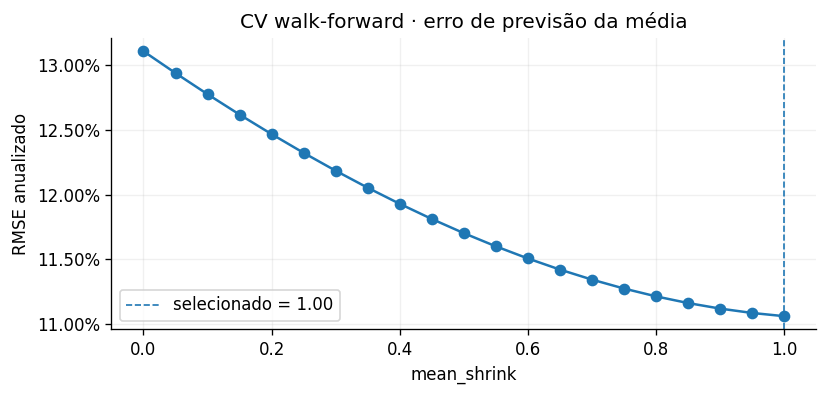

In [15]:

from dataclasses import replace

def walk_forward_shrink_cv(real_returns,base_policy,candidates,min_train_months=60,
                           validation_months=12,step_months=12):
    """Seleciona intensidade de shrinkage usando somente informação disponível em cada fold."""
    X=real_returns.dropna().copy()
    if len(X)<min_train_months+validation_months:
        raise ValueError('Histórico insuficiente para CV walk-forward')
    rows=[]
    fold=0
    for train_end in range(min_train_months,len(X)-validation_months+1,step_months):
        train=X.iloc[:train_end]
        valid=X.iloc[train_end:train_end+validation_months]
        if len(valid)<validation_months:break
        realized=valid.mean().values*12
        for s in candidates:
            pol=replace(base_policy,mean_shrink=float(s))
            mu,_=moments(train,pol)
            err=mu-realized
            rows.append({'fold':fold,'train_end':train.index[-1],'valid_start':valid.index[0],
                         'valid_end':valid.index[-1],'mean_shrink':float(s),
                         'mse':float(np.mean(err**2)),'mae':float(np.mean(np.abs(err)))})
        fold+=1
    detail=pd.DataFrame(rows)
    if detail.empty:raise ValueError('Nenhum fold de CV produzido')
    summary=detail.groupby('mean_shrink').agg(
        rmse=('mse',lambda x:float(np.sqrt(np.mean(x)))),
        mae=('mae','mean'),n_folds=('fold','nunique'),
        mse_mean=('mse','mean'),mse_std=('mse','std')).reset_index()
    summary['rmse_se']=summary.apply(lambda r: (0 if pd.isna(r.mse_std) else r.mse_std)/max(np.sqrt(r.n_folds),1)/(2*max(r.rmse,1e-12)),axis=1)
    i=int(summary.rmse.idxmin());best=float(summary.loc[i,'mean_shrink']);threshold=float(summary.loc[i,'rmse']+summary.loc[i,'rmse_se'])
    eligible=summary.loc[summary.rmse<=threshold,'mean_shrink']
    one_se=float(eligible.max()) if len(eligible) else best
    return {'detail':detail,'summary':summary,'best_min_rmse':best,'best_one_se':one_se,'threshold_one_se':threshold}

cv_cfg=CONFIG['shrinkage_cv']
base_policy=Policy(**CONFIG['policy'])
shrink_cv=walk_forward_shrink_cv(
    real_returns,base_policy,cv_cfg['candidates'],cv_cfg['min_train_months'],
    cv_cfg['validation_months'],cv_cfg['step_months'])
selected_shrink=(shrink_cv['best_one_se'] if cv_cfg.get('selection_rule')=='one_se' else shrink_cv['best_min_rmse'])
CONFIG['policy']['mean_shrink']=selected_shrink
history_policy=Policy(**CONFIG['policy'])
_cands=sorted(float(x) for x in cv_cfg['candidates'])
shrink_corner=float(selected_shrink) in (_cands[0],_cands[-1])

# Política do backtest histórico: shrinkage calibrado SOMENTE no período anterior
# ao início da avaliação OOS. Evita vazamento do hiperparâmetro para o passado.
bt_cal_months=int(CONFIG.get('backtest_calibration_months',96))
min_needed=cv_cfg['min_train_months']+cv_cfg['validation_months']
if not min_needed <= bt_cal_months < len(real_returns):
    raise ValueError('backtest_calibration_months deve deixar histórico suficiente para CV e período OOS')
backtest_calibration_panel=real_returns.iloc[:bt_cal_months]
backtest_shrink_cv=walk_forward_shrink_cv(
    backtest_calibration_panel,base_policy,cv_cfg['candidates'],cv_cfg['min_train_months'],
    cv_cfg['validation_months'],cv_cfg['step_months'])
backtest_selected_shrink=(backtest_shrink_cv['best_one_se'] if cv_cfg.get('selection_rule')=='one_se'
                          else backtest_shrink_cv['best_min_rmse'])
backtest_policy=replace(base_policy,mean_shrink=float(backtest_selected_shrink))
backtest_start_at=bt_cal_months
backtest_start_date=real_returns.index[backtest_start_at]
backtest_calibration_end=real_returns.index[backtest_start_at-1]
print(f"mean_shrink selecionado por CV walk-forward para projeção as-of: {selected_shrink:.2f} | mínimo RMSE: {shrink_cv['best_min_rmse']:.2f}")
print(f"prior_model: {history_policy.prior_model} | folds: {int(shrink_cv['summary'].n_folds.max())}")
print(f"Backtest OOS: shrink={backtest_selected_shrink:.2f} calibrado até {backtest_calibration_end.date()} | teste inicia {backtest_start_date.date()}")
if shrink_corner:
    print(f"ATENÇÃO: shrink selecionado ({selected_shrink:.2f}) está na borda da grade [{_cands[0]:.2f}, {_cands[-1]:.2f}]. "
          + ("Na borda 1,0 isso significa que, sob esta regra, as médias amostrais não acrescentam informação fora da amostra: "
             "os retornos esperados passam a ser o prior." if _cands[-1]==float(selected_shrink) else "Estenda a grade."))
if float(backtest_selected_shrink) in (_cands[0],_cands[-1]):
    print(f"ATENÇÃO: shrink do backtest ({backtest_selected_shrink:.2f}) também está na borda da grade.")
display(shrink_cv['summary'].style.format({'mean_shrink':'{:.2f}','rmse':'{:.2%}','mae':'{:.2%}','rmse_se':'{:.2%}'}))

diag_prior=prior_diagnostics(real_returns.tail(CONFIG['lookback']),history_policy)
display(diag_prior.style.format('{:.2%}'))

fig,ax=plt.subplots(figsize=(7,3.4))
ax.plot(shrink_cv['summary'].mean_shrink,shrink_cv['summary'].rmse,marker='o')
ax.axvline(selected_shrink,ls='--',lw=1,label=f'selecionado = {selected_shrink:.2f}')
ax.set(title='CV walk-forward · erro de previsão da média',xlabel='mean_shrink',ylabel='RMSE anualizado')
ax.yaxis.set_major_formatter(PercentFormatter(1));ax.legend();plt.tight_layout();plt.show()


## 8 · Comparação histórica walk-forward sob protocolo comum
Nenhum peso SAA é escolhido manualmente. O **SAA estratégico** é calibrado uma única vez na janela inicial de 36 meses pela mesma utilidade média-variância e pelos mesmos estimadores robustos usados no restante do estudo; depois seus pesos são congelados e apenas rebalanceados. A **média-variância móvel** recalibra a solução a cada trimestre. Assim, o teste compara uma política estratégica estável com a reestimação recorrente — sem escolher pesos que se beneficiaram do período futuro.

O **POMA–VaR aproximado** usa a mesma função-objetivo de média-variância e acrescenta a chance constraint $P(W_T<G)\leq10\%$. Para tornar o teste factível e auditável em todas as janelas, define-se preservação do poder de compra como piso: retorno real acumulado não negativo em quatro anos. Sob aproximação lognormal, a restrição é equivalente a limitar o VaR de shortfall. A margem da restrição é registrada a cada rebalanceamento.

Todos os sete métodos compartilham: mesmos ativos e restrições; estimação com retornos reais; janela móvel de 36 meses quando aplicável; defasagem de um mês; aplicação dos pesos aos retornos nominais seguintes; rebalanceamento trimestral; custo de 10 bp por lado negociado; cotas fracionárias. Não inclui impostos, spread cambial, remessa, impacto de mercado ou diferenças entre NAV e execução. Sharpe usa excesso mensal contra CDI; drawdown usa fechamentos mensais. O universo atual tem viés de sobrevivência.

Backtest reportado é OOS a partir de 2018-02-28 e usa mean_shrink=1.00 congelado.


,CAGR,Vol_aa,MaxDD_mensal,Meses,Sharpe_CDI,CAGR_real
Pesos iguais,0.1190,0.0601,-0.0457,63.0,0.7700,0.0570
SAA estratégico,0.1071,0.0392,-0.0191,63.0,0.8719,0.0458
Mínima variância,0.0906,0.0206,-0.0080,63.0,0.9354,0.0302
Média-variância,0.1080,0.0414,-0.0192,63.0,0.8468,0.0466
POMA–VaR aproximado,0.1077,0.0432,-0.0240,63.0,0.8088,0.0464
Paridade de risco,0.0957,0.0334,-0.0218,63.0,0.7257,0.0350
RP + LDI proxy,0.0901,0.0295,-0.0286,63.0,0.6983,0.0298


,método,estimação,atualização dos pesos,critério
0,SAA estratégico,36 meses anteriores ao início OOS,nenhuma; rebalanceia ao alvo,utilidade média-variância
1,Média-variância,36 meses móveis,trimestral,mesma utilidade média-variância
2,POMA–VaR,36 meses móveis,trimestral,mesma utilidade + chance constraint


Exposição internacional do SAA calibrado antes do teste: 31.83%


,ACWI,SPY,DBC,IEF,BOVA11.SA,IMA_B_PROXY,IMA_B5_PROXY,IRFM_PROXY,CDI_PROXY
peso inicial (%),6.34,7.19,8.18,10.11,7.64,12.37,15.55,14.01,18.61


POMA–VaR: rebalanceamentos factíveis = 52.4%; inviáveis/mantidos = 10 de 21.
Margem mínima nos rebalanceamentos factíveis = 0.011782; restrição ativa em 0.0% dos factíveis.


,date,information_through,chance_margin,note
11,2020-11-30,2020-09-30,-0.024857,POMA aproximado: meta inviável sob os parâmetr...
12,2021-02-28,2020-12-31,-0.070979,POMA aproximado: meta inviável sob os parâmetr...
13,2021-05-31,2021-03-31,-0.108039,POMA aproximado: meta inviável sob os parâmetr...
14,2021-08-31,2021-06-30,-0.116046,POMA aproximado: meta inviável sob os parâmetr...
15,2021-11-30,2021-09-30,-0.153303,POMA aproximado: meta inviável sob os parâmetr...
16,2022-02-28,2021-12-31,-0.175080,POMA aproximado: meta inviável sob os parâmetr...
17,2022-05-31,2022-03-31,-0.187164,POMA aproximado: meta inviável sob os parâmetr...
18,2022-08-31,2022-06-30,-0.188065,POMA aproximado: meta inviável sob os parâmetr...
19,2022-11-30,2022-09-30,-0.139677,POMA aproximado: meta inviável sob os parâmetr...
20,2023-02-28,2022-12-31,-0.113357,POMA aproximado: meta inviável sob os parâmetr...


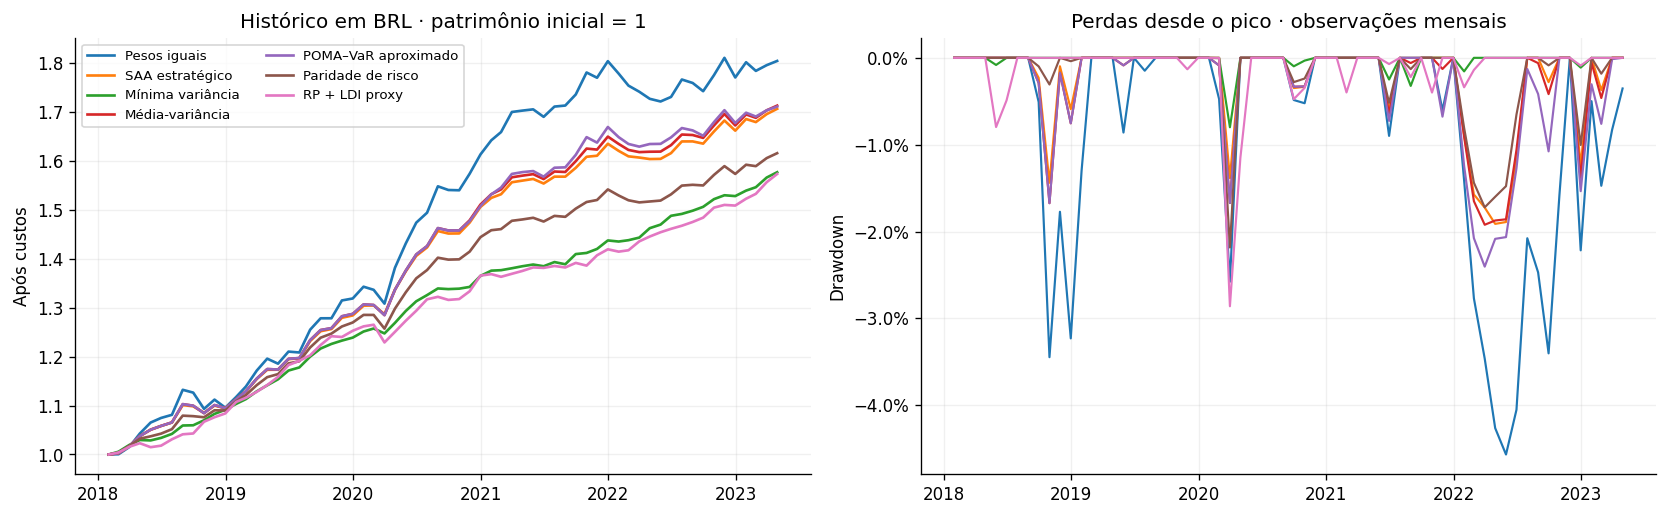

In [16]:
history_policy=Policy(**CONFIG['policy']) # projeção as-of: usa todo o histórico disponível até ASOF
# Backtest usa política calibrada apenas no período pré-teste (definida na célula de CV).
poma_bt=CONFIG['backtest_poma']
backtests={}
for method in ['equal','saa','min_variance','mean_variance','poma','risk_parity','hybrid']:
    backtests[method]=backtest(returns,method,backtest_policy,lookback=CONFIG['backtest_lookback'],
        cost_bps=CONFIG['cost_bps'],estimation_returns=real_returns,allocation_phase=poma_bt,start_at=backtest_start_at,on_infeasible=('hold' if method=='poma' else 'raise'))
metrics=pd.DataFrame({METHOD_NAMES[m]:performance(b['history'].return_net,macro['CDI'],macro['IPCA']) for m,b in backtests.items()}).T
print(f"Backtest reportado é OOS a partir de {backtest_start_date.date()} e usa mean_shrink={backtest_policy.mean_shrink:.2f} congelado.")
display(metrics.round(4))
comparison_design=pd.DataFrame([
    {'método':'SAA estratégico','estimação':'36 meses anteriores ao início OOS','atualização dos pesos':'nenhuma; rebalanceia ao alvo','critério':'utilidade média-variância'},
    {'método':'Média-variância','estimação':'36 meses móveis','atualização dos pesos':'trimestral','critério':'mesma utilidade média-variância'},
    {'método':'POMA–VaR','estimação':'36 meses móveis','atualização dos pesos':'trimestral','critério':'mesma utilidade + chance constraint'},
])
display(comparison_design)
saa_calibration=(backtests['saa']['calibration_weights']*100).rename('peso inicial (%)').to_frame()
foreign_assets=['ACWI','SPY','DBC','IEF']
print(f'Exposição internacional do SAA calibrado antes do teste: {saa_calibration.loc[foreign_assets].sum().iloc[0]:.2f}%')
display(saa_calibration.round(2).T)
poma_log=backtests['poma']['log']
poma_feasible=poma_log['allocation_feasible'].astype(bool)
print(f"POMA–VaR: rebalanceamentos factíveis = {poma_feasible.mean():.1%}; "
      f"inviáveis/mantidos = {(~poma_feasible).sum()} de {len(poma_log)}.")
if poma_feasible.any():
    print(f"Margem mínima nos rebalanceamentos factíveis = {poma_log.loc[poma_feasible,'chance_margin'].min():.6f}; "
          f"restrição ativa em {(poma_log.loc[poma_feasible,'chance_margin']<1e-5).mean():.1%} dos factíveis.")
if (~poma_feasible).any():
    display(poma_log.loc[~poma_feasible,['date','information_through','chance_margin','note']])
fig,axs=plt.subplots(1,2,figsize=(14,4.4))
for m,b in backtests.items():
    nav=pd.concat([pd.Series([1.],index=[b['base_date']]),b['history'].nav])
    axs[0].plot(nav.index,nav,label=METHOD_NAMES[m],lw=1.6)
    axs[1].plot(nav.index,nav/nav.cummax()-1,lw=1.3)
axs[0].set(title='Histórico em BRL · patrimônio inicial = 1',ylabel='Após custos')
axs[1].set(title='Perdas desde o pico · observações mensais',ylabel='Drawdown')
axs[1].yaxis.set_major_formatter(PercentFormatter(1))
axs[0].legend(fontsize=8,ncol=2);fig.tight_layout();plt.show()

## 9 · Executar o grafo e inspecionar escolhas
As estimativas e pesos de cada fase são calculados com a janela histórica até a data-base. **Não são recalibrados com retornos futuros simulados.** O agente escolhe métodos antes da simulação. Isso torna comparações reproduzíveis; uma política adaptativa por trajetória exigiria um experimento separado.

Se POMA for inviável, o modo por regras registra a alternativa. No modo LLM, uma resposta inválida retorna ao planejador e, após o limite, bloqueia a execução. O modo usado aparece na saída e no log.

In [17]:
graph=build_graph()
state=graph.invoke({'config':CONFIG,'real_returns':real_returns,'log':[]},config={'recursion_limit':30})
print('Modo:',CONFIG['planner_mode'],'| Status:',state['status'])
display(pd.DataFrame(state['log']))
if state['status']!='complete':raise RuntimeError('Orquestrador bloqueou a execução: '+str(state['audit_errors']))
plan_table=pd.DataFrame(state['plan']['choices'])
plan_table['tool_label']=plan_table['method'].map(METHOD_NAMES)
display(plan_table)
phase_weights=pd.DataFrame(state['allocations']).T
phase_weights.index=[p['name']+' · '+METHOD_NAMES[p['selected_method']] for p in state['phases']]
display((phase_weights*100).round(2).rename_axis('Fase · ferramenta').add_suffix(' (%)'))
display(pd.DataFrame(state['diagnostics']).query('feasible == False'))

Modo: rules | Status: complete


,node,months,asof,mode,feasible,total,attempt,choices,tools_dispatched,approved,...,block,selected_for_dynamic_projection,episodes,wealth_bins,dp_scenarios,risk_objective,turnover_convention,paths,seed,probability_any_shortfall
0,validate_data,159.0,2023-04-30,rules,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,estimate_tools,NaN,NaN,NaN,28.0,32.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,planner,NaN,NaN,rules,NaN,NaN,1.0,"[{'phase': 'Acumulação', 'method': 'risk_parit...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,construct,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[risk_parity, hybrid, hybrid, ldi_proxy]",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,audit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,sequential_policy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.0,dynamic_programming,3000.0,41.0,21.0,goal,target_to_target,NaN,NaN,NaN
6,project,180.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2000.0,42.0,0.0


,phase,method,reason,tool_label
0,Acumulação,risk_parity,"Preferência explícita da fase, com validação q...",Paridade de risco
1,Consolidação,hybrid,Preferência poma inviável; alternativa determi...,RP + LDI proxy
2,Transição,hybrid,"Preferência explícita da fase, com validação q...",RP + LDI proxy
3,Desembolsos,ldi_proxy,"Preferência explícita da fase, com validação q...",LDI proxy


,ACWI (%),SPY (%),DBC (%),IEF (%),BOVA11.SA (%),IMA_B_PROXY (%),IMA_B5_PROXY (%),IRFM_PROXY (%),CDI_PROXY (%)
Fase · ferramenta,,,,,,,,,
Acumulação · Paridade de risco,4.25,4.04,8.54,8.37,5.26,14.51,18.26,16.98,19.79
Consolidação · RP + LDI proxy,1.70,1.62,3.41,3.35,2.10,30.91,24.21,6.79,25.91
Transição · RP + LDI proxy,1.49,1.41,2.99,2.93,1.84,32.27,24.71,5.94,26.42
Desembolsos · LDI proxy,0.00,0.00,0.00,0.00,0.00,34.06,30.50,0.00,35.44


,phase,method,feasible,mu_real_est,vol_est,note
5,Acumulação,poma,False,NaN,NaN,POMA aproximado: meta inviável sob os parâmetr...
13,Consolidação,poma,False,NaN,NaN,POMA aproximado: meta inviável sob os parâmetr...
21,Transição,poma,False,NaN,NaN,POMA aproximado: meta inviável sob os parâmetr...
29,Desembolsos,poma,False,NaN,NaN,POMA aproximado: meta inviável sob os parâmetr...


## 10 · Alocação e contribuição ao risco por fase
Os pesos são efetivamente usados na projeção. A contribuição ao risco utiliza a covariância estimada na data-base e pode ser negativa quando um ativo diversifica a carteira. A combinação com caixa e limites pode afastar a paridade exata.

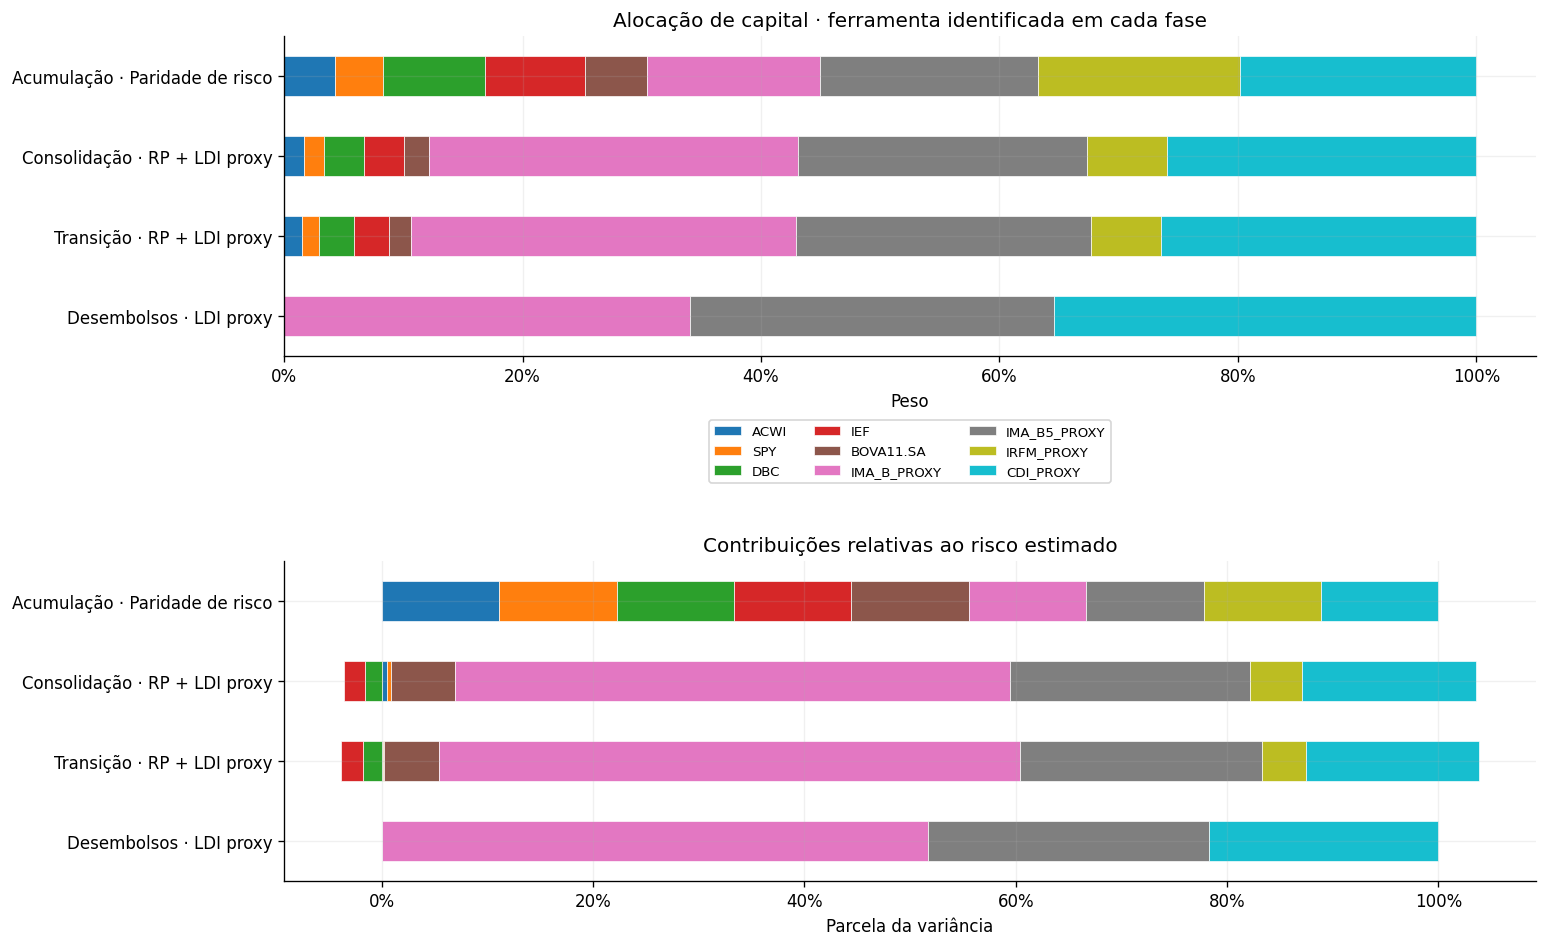

In [18]:
asset_colors=plt.get_cmap('tab10')(np.linspace(0,1,len(universe)))
fig,axs=plt.subplots(2,1,figsize=(13,8),gridspec_kw={'height_ratios':[1,1]})
phase_weights.plot.barh(stacked=True,ax=axs[0],color=asset_colors,edgecolor='white',linewidth=.4)
axs[0].set(title='Alocação de capital · ferramenta identificada em cada fase',xlabel='Peso',ylabel='');axs[0].xaxis.set_major_formatter(PercentFormatter(1));axs[0].legend(ncol=3,fontsize=8,loc='upper center',bbox_to_anchor=(.5,-.18));axs[0].invert_yaxis()
_,cov=moments(real_returns.tail(CONFIG['lookback']),Policy(**CONFIG['policy']))
rc=pd.DataFrame([risk_contributions(w.values,cov) for _,w in phase_weights.iterrows()],index=phase_weights.index,columns=universe)
rc.plot.barh(stacked=True,ax=axs[1],color=asset_colors,legend=False,edgecolor='white',linewidth=.4)
axs[1].set(title='Contribuições relativas ao risco estimado',xlabel='Parcela da variância',ylabel='');axs[1].xaxis.set_major_formatter(PercentFormatter(1));axs[1].invert_yaxis()
fig.tight_layout(h_pad=3);plt.show()

## 10A · Programação dinâmica e aprendizado por reforço

Esta é a camada recursiva do experimento. O problema é formulado como um MDP finito:

- **Estado:** mês/fase, faixa discretizada do patrimônio real e ferramenta usada anteriormente.
- **Ação:** escolher uma carteira válida produzida pelas metodologias disponíveis; o agente escolhe a ferramenta, não pesos arbitrários.
- **Transição:** aporte, custo de troca, retorno conjunto dos ativos e retirada.
- **Recompensa:** penalidade por insuficiência, penalidade por troca e utilidade relativa às metas intermediárias e terminal.

A revisão usa um **motor de transição comum**. O Q-learning aprende em trajetórias do mesmo stationary/moving block bootstrap empregado na avaliação final. O Bellman usa uma compressão determinística de cenários conjuntos derivados desse mesmo painel e das mesmas hipóteses, pois resolver integralmente a dependência serial exigiria adicionar o regime/posição do bloco ao estado.

Esta continua sendo uma implementação tabular de pesquisa — não deep RL, meta-RL ou modelo macroeconômico.

**Leitura dos dois solvers.** O Bellman resolve exatamente o modelo discretizado e é a solução de referência. O Q-learning tabular aprende sem modelo e serve de contraste, mas não converge aqui: são ~400 mil pares estado-ação, e a diferença de retorno esperado entre métodos é muito menor que o ruído de um mês. Mais episódios não ajudam — põem mais estados com poucas visitas, onde o argmax escolhe a ação de mais sorte. Os números do Q-learning abaixo devem ser lidos como referência não convergida.


### Diagnósticos: resíduo de Bellman e concordância entre os dois solvers

Duas checagens que separam "o código roda" de "o código está certo".

**Resíduo de Bellman.** Mede |V(s) − [r + E V(s')]| na ação que a política escolhe, sob o mesmo modelo (mesmos quantis, custos e penalidades). Para a programação dinâmica o resíduo deve ser ~0: ela foi construída por essa recursão, então é uma verificação da implementação. Para o Q-learning ele não é zero — mede o quanto a função Q aprendida ainda viola a equação de otimalidade.

**Concordância entre as políticas.** A versão crua percorre toda a grade de estados e trata igualmente estados que nunca ocorrem, por isso subestima o acordo. A versão ponderada usa a contagem de visitas do Q-learning e é a leitura honesta: mede acordo onde o problema realmente passa.

**Perda de valor.** Avalia as duas políticas sob o mesmo modelo, sem maximizar, e compara o valor no estado inicial. Como a programação dinâmica é ótima nesse MDP, a diferença é não negativa por construção e diz quanto se perde ao usar a política aprendida.


Política dinâmica destacada: dynamic_programming


,solver,patrimonio_terminal_mediano,retorno_real_mediano,prob_shortfall_retirada,prob_falha_meta
0,Bellman · programação dinâmica,2.305869e+06,1.1609,0.0,0.224
1,Q-learning,2.037469e+06,0.9329,0.0,0.235


,phase,method,share_of_decisions,solver
0,Acumulação,equal,1.000000,Bellman
1,Consolidação,equal,1.000000,Bellman
5,Desembolsos,min_variance,0.014344,Bellman
4,Desembolsos,equal,0.985656,Bellman
3,Transição,min_variance,0.000792,Bellman
2,Transição,equal,0.999208,Bellman
7,Acumulação,hybrid,0.001937,Q-learning
9,Acumulação,mean_variance,0.003208,Q-learning
8,Acumulação,ldi_proxy,0.006448,Q-learning
10,Acumulação,min_variance,0.013406,Q-learning


{'finite_values': True,
 'policy_has_initial_action': True,
 'horizon': 180,
 'wealth_bins': 41}

,solver,estados,residuo_medio,residuo_p95,residuo_maximo,residuo_medio_relativo
0,dynamic_programming,66420,0.000000,0.000000,0.000,0.000000
1,q_learning,66420,0.121742,0.036803,12.122,0.008902


Concordancia crua (toda a grade):   87.2%  em 66420 estados validos
Concordancia ponderada por visita:  66.9%  em 9269 estados efetivamente visitados
Concordancia em estados com >= 30 visitas: 48.1%  em 2788 estados
Valor no estado inicial: Bellman 1.2147 | Q-learning 0.9977 | perda 0.2170


,fase,estados_validos,concordancia,concordancia_ponderada
0,Acumulação,17712,0.9376,0.7612
1,Consolidação,17712,0.9157,0.6994
2,Transição,13284,0.8947,0.6381
3,Desembolsos,17712,0.7453,0.5714


Leitura: o DP é a solução do modelo; o Q-learning tabular é referência NÃO convergida.
Na V4.2, treinar com 12.000 episódios em vez de 3.000 piorou a política (perda 0,22 -> 0,37):
com ~400 mil pares estado-ação e diferença de retorno esperado entre métodos muito menor que o
ruído mensal, mais episódios põem mais estados com 2-3 visitas, onde o argmax premia a sorte.


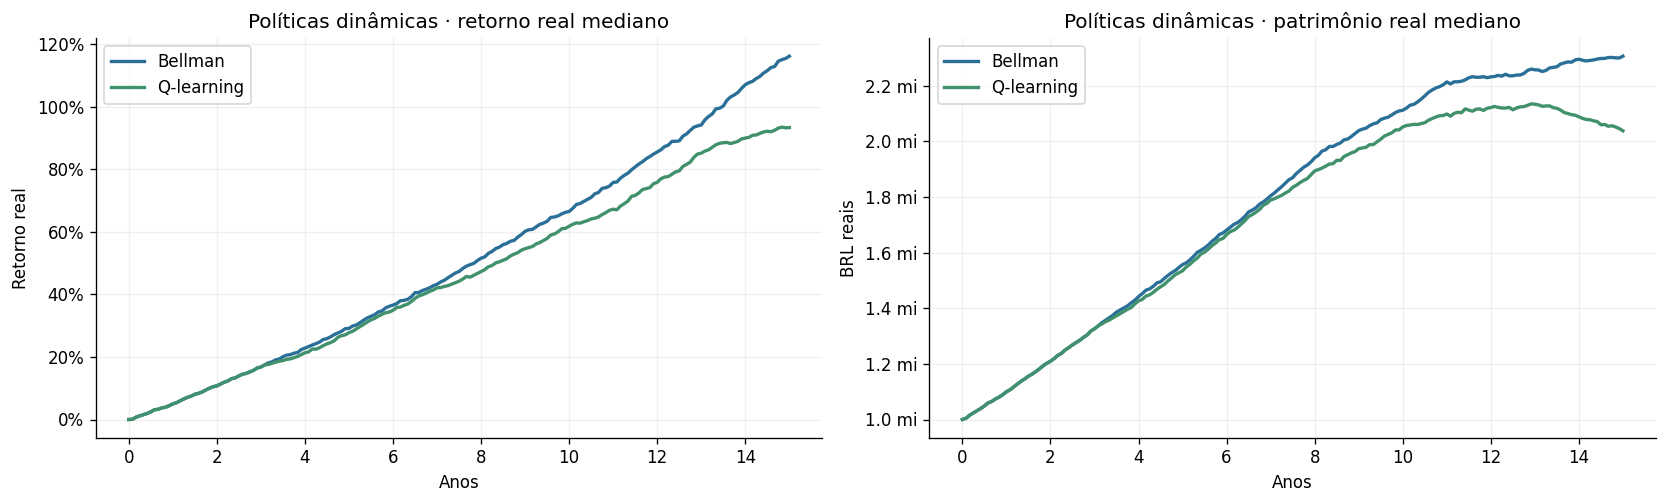

In [19]:
seq=state['sequential']
dp_eval=seq['evaluations']['dynamic_programming'];q_eval=seq['evaluations']['q_learning']
seq_summary=pd.DataFrame([
    {'solver':'Bellman · programação dinâmica','patrimonio_terminal_mediano':np.median(dp_eval['wealth'][:,-1]),'retorno_real_mediano':np.median(dp_eval['nav'][:,-1]-1),'prob_shortfall_retirada':dp_eval['probability_any_withdrawal_shortfall'],'prob_falha_meta':dp_eval['probability_any_goal_failure']},
    {'solver':'Q-learning','patrimonio_terminal_mediano':np.median(q_eval['wealth'][:,-1]),'retorno_real_mediano':np.median(q_eval['nav'][:,-1]-1),'prob_shortfall_retirada':q_eval['probability_any_withdrawal_shortfall'],'prob_falha_meta':q_eval['probability_any_goal_failure']},
])
print('Política dinâmica destacada:',seq['selected'])
display(seq_summary.round(4))
display(pd.concat([dp_eval['action_mix'].assign(solver='Bellman'),q_eval['action_mix'].assign(solver='Q-learning')],ignore_index=True).sort_values(['solver','phase','share_of_decisions']))
hist_seq=real_returns.tail(CONFIG['lookback'])
display(sanity_check_solution(seq['dynamic_programming']))
display(pd.DataFrame([
    bellman_residual(seq['dynamic_programming'],hist_seq,state['phases'],seq['action_library'],CONFIG['initial'],n_quantiles=CONFIG['dp_quantiles']),
    bellman_residual(seq['q_learning'],hist_seq,state['phases'],seq['action_library'],CONFIG['initial'],n_quantiles=CONFIG['dp_quantiles']),
]).round(6))
acordo=compare_dp_q_policies(seq['dynamic_programming'],seq['q_learning'],hist_seq,state['phases'],seq['action_library'],CONFIG['initial'],n_quantiles=CONFIG['dp_quantiles'])
print(f"Concordancia crua (toda a grade):   {acordo['concordancia_global']:.1%}  em {acordo['estados_validos']} estados validos")
print(f"Concordancia ponderada por visita:  {acordo['concordancia_ponderada_por_visita']:.1%}  em {acordo['estados_visitados_pelo_q']} estados efetivamente visitados")
print(f"Concordancia em estados com >= {acordo['min_visits']} visitas: {acordo['concordancia_estados_bem_visitados']:.1%}  em {acordo['estados_bem_visitados']} estados")
print(f"Valor no estado inicial: Bellman {acordo['valor_inicial_bellman']:.4f} | Q-learning {acordo['valor_inicial_q_learning']:.4f} | perda {acordo['perda_por_usar_q']:.4f}")
display(acordo['por_fase'].round(4))
print('Leitura: o DP é a solução do modelo; o Q-learning tabular é referência NÃO convergida.')
print('Na V4.2, treinar com 12.000 episódios em vez de 3.000 piorou a política (perda 0,22 -> 0,37):')
print('com ~400 mil pares estado-ação e diferença de retorno esperado entre métodos muito menor que o')
print('ruído mensal, mais episódios põem mais estados com 2-3 visitas, onde o argmax premia a sorte.')
x_seq=np.arange(dp_eval['wealth'].shape[1])/12
fig,axs=plt.subplots(1,2,figsize=(14,4.3))
for label,evaluation,color in [('Bellman',dp_eval,'#2a6f97'),('Q-learning',q_eval,'#40916c')]:
    axs[0].plot(x_seq,np.median(evaluation['nav']-1,axis=0),label=label,color=color,lw=2)
    axs[1].plot(x_seq,np.median(evaluation['wealth'],axis=0),label=label,color=color,lw=2)
axs[0].set(title='Políticas dinâmicas · retorno real mediano',xlabel='Anos',ylabel='Retorno real');axs[0].yaxis.set_major_formatter(PercentFormatter(1))
axs[1].set(title='Políticas dinâmicas · patrimônio real mediano',xlabel='Anos',ylabel='BRL reais');axs[1].yaxis.set_major_formatter(FuncFormatter(lambda v,p:f'{v/1e6:.1f} mi'))
for ax in axs:ax.legend()
fig.tight_layout();plt.show()

### Ferramenta selecionada em cada fase
Como a política depende do patrimônio, uma fase pode usar mais de uma ferramenta. O gráfico mostra a proporção de decisões simuladas atribuída a cada método; isso é mais fiel do que rotular toda a fase com uma única ferramenta.

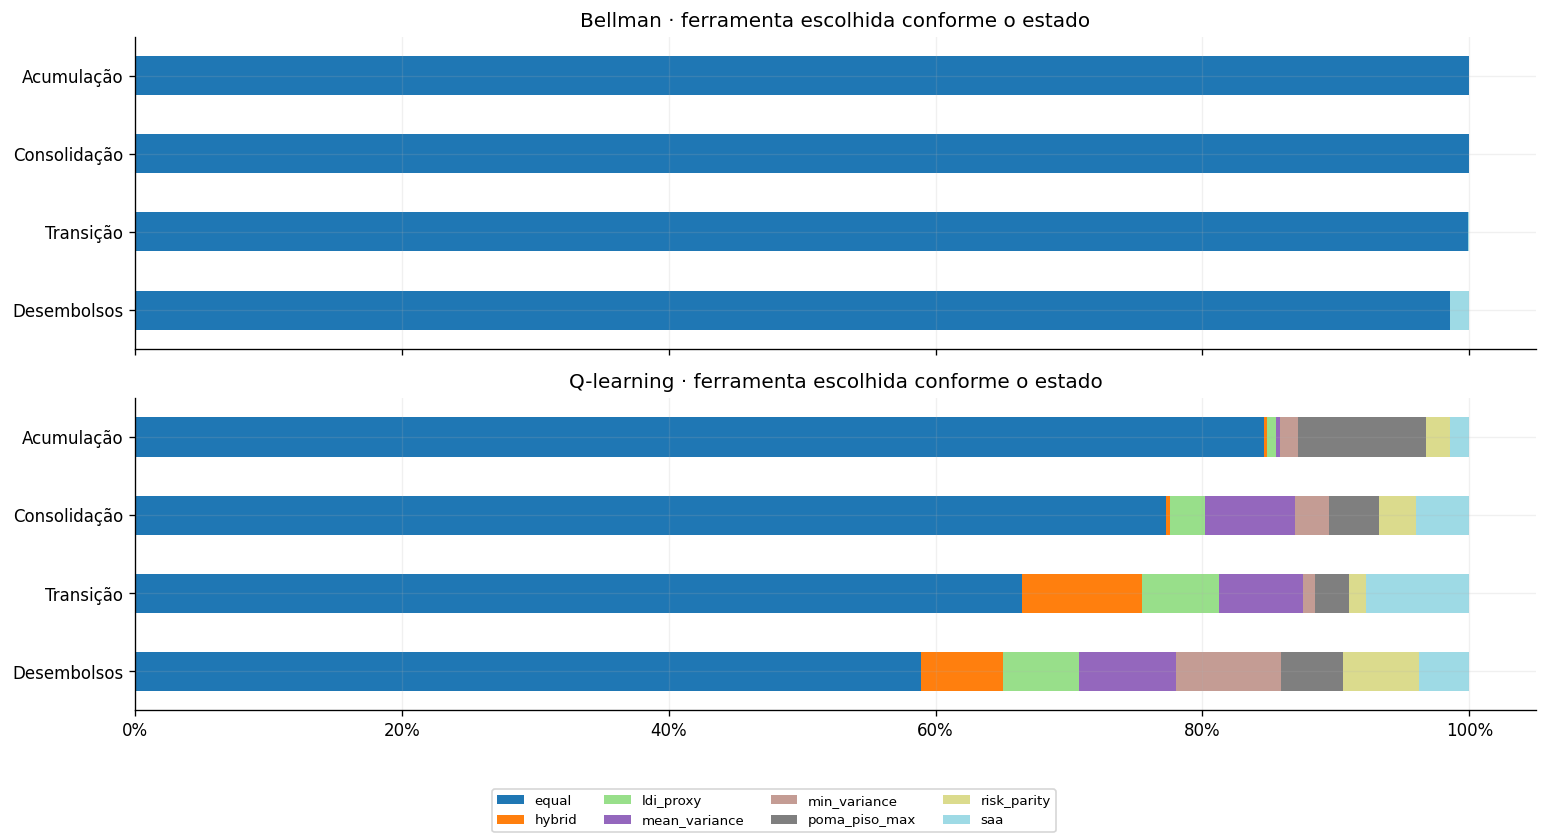

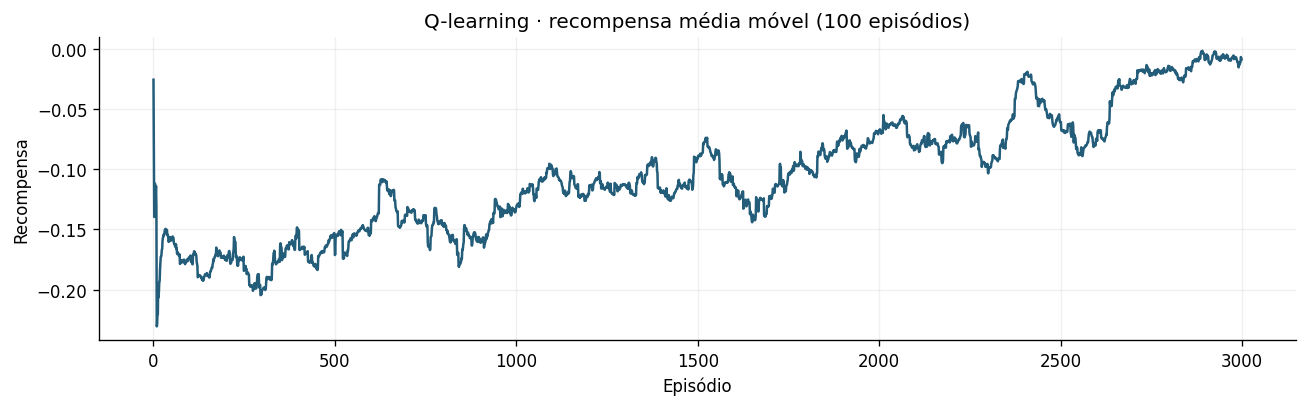

In [20]:
mix=pd.concat([
    dp_eval['action_mix'].assign(solver='Bellman'),
    q_eval['action_mix'].assign(solver='Q-learning')
],ignore_index=True)
fig,axs=plt.subplots(2,1,figsize=(13,7),sharex=True)
for ax,(solver,group) in zip(axs,mix.groupby('solver',sort=False)):
    table=group.pivot(index='phase',columns='method',values='share_of_decisions').fillna(0)
    table=table.reindex([p['name'] for p in state['phases']])
    table.plot.barh(stacked=True,ax=ax,colormap='tab20',legend=False)
    ax.set(title=solver+' · ferramenta escolhida conforme o estado',xlabel='',ylabel='')
    ax.xaxis.set_major_formatter(PercentFormatter(1));ax.invert_yaxis()
handles,labels=axs[-1].get_legend_handles_labels();fig.legend(handles,labels,ncol=4,loc='lower center',fontsize=8)
fig.tight_layout(rect=[0,.09,1,1]);plt.show()
rewards=seq['q_learning']['episode_rewards']
fig,ax=plt.subplots(figsize=(11,3.5));window=max(50,len(rewards)//30)
ax.plot(pd.Series(rewards).rolling(window,min_periods=1).mean(),color='#235d7a')
ax.set(title=f'Q-learning · recompensa média móvel ({window} episódios)',xlabel='Episódio',ylabel='Recompensa');fig.tight_layout();plt.show()

### Política por patrimônio
Mapa da política destacada, mantendo como referência o método anterior mais frequente em cada fase. A cor representa a ferramenta escolhida para cada combinação de mês e faixa patrimonial.

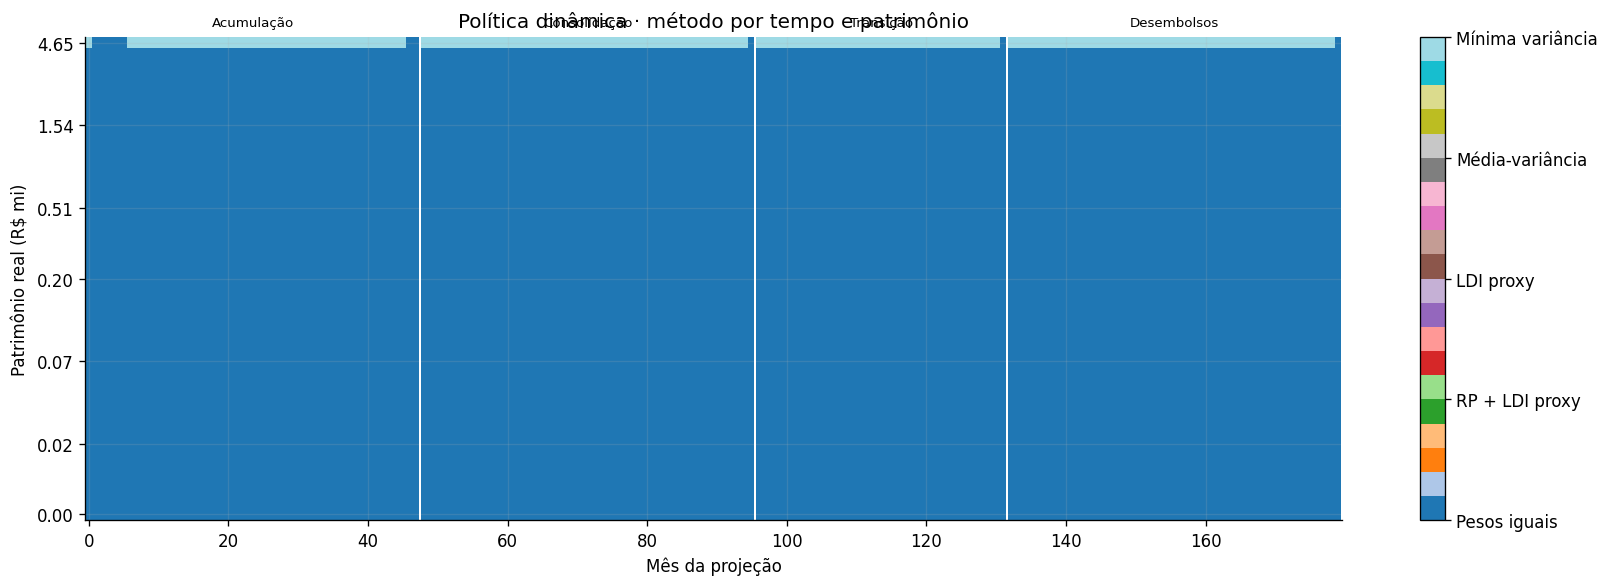

In [21]:
selected_solution=seq[seq['selected']]
selected_eval=seq['evaluations'][seq['selected']]
grid=selected_solution['grid'];months=np.arange(len(selected_solution['timeline']))
# Para leitura 2D, fixa-se o método anterior no mais frequente da avaliação em cada mês.
policy_map=np.empty((len(grid),len(months)),int)
for t in months:
    prev_actions=selected_eval['actions'][:,max(t-1,0)] if t>0 else np.full(CONFIG['n_paths'],selected_solution['initial_prev'])
    previous=int(pd.Series(prev_actions).mode().iloc[0])
    policy_map[:,t]=selected_solution['policy'][t,:,previous]
fig,ax=plt.subplots(figsize=(14,5))
im=ax.imshow(policy_map,aspect='auto',origin='lower',interpolation='nearest',cmap='tab20')
phase_ends=np.cumsum([p['months'] for p in state['phases']]);phase_starts=np.r_[0,phase_ends[:-1]]
for s,e,p in zip(phase_starts,phase_ends,state['phases']):
    ax.axvline(e-.5,color='white',lw=1.2);ax.text((s+e-1)/2,len(grid)+.4,p['name'],ha='center',fontsize=8)
yt=np.linspace(0,len(grid)-1,7,dtype=int);ax.set_yticks(yt,[f'{grid[i]/1e6:.2f}' for i in yt]);ax.set(xlabel='Mês da projeção',ylabel='Patrimônio real (R$ mi)',title='Política dinâmica · método por tempo e patrimônio')
cbar=fig.colorbar(im,ax=ax,ticks=np.arange(len(selected_solution['methods'])));cbar.ax.set_yticklabels([DISPLAY_NAMES.get(m,m) for m in selected_solution['methods']]);fig.tight_layout();plt.show()

## 10B · Convergência numérica do Bellman

O objetivo não é encontrar um número “correto” de bins ou cenários por decreto. O teste abaixo verifica se a **política de escolha de ferramenta** é estável quando aumentamos a resolução.

São feitos dois sweeps independentes:

- cenários conjuntos: **9, 21 e 51**;
- faixas de patrimônio: **21, 41, 81 e 161**.

A referência é a configuração central (`41 bins`, `21 cenários`). A concordância é calculada numa malha comum de patrimônio, mês e método anterior, para tornar comparáveis soluções que têm grades diferentes.

Desde a V4.2 a função de valor é interpolada por PCHIP em log-patrimônio. O resíduo de Bellman confirma que o DP resolve o modelo que recebeu; esta seção confirma que o modelo discretizado não depende da grade.


In [22]:

rob=CONFIG['robustness'];hist_seq=real_returns.tail(CONFIG['lookback'])
base_dp=seq['dynamic_programming']
conv_rows=[]
# Sensibilidade ao número de cenários, mantendo a grade central.
for nq in rob['quantiles']:
    sol=base_dp if nq==CONFIG['dp_quantiles'] else solve_dynamic_programming(
        hist_seq,state['phases'],seq['action_library'],initial=CONFIG['initial'],
        n_wealth_bins=CONFIG['rl_wealth_bins'],n_quantiles=nq,
        cost_bps=CONFIG['cost_bps'],switch_penalty=CONFIG['switch_penalty'],
        transition_scheme=CONFIG['transition_scheme'],block=CONFIG['block'])
    agr=policy_agreement_common_states(base_dp,sol,state['phases'],CONFIG['initial'])
    conv_rows.append({'teste':'cenários Bellman','valor':nq,
        'concordancia_com_base':agr['agreement'],
        'valor_inicial':value_at_wealth(sol,value_function(sol,state['phases'],seq['action_library'],CONFIG['initial']),0,CONFIG['initial'],sol['initial_prev'])})
# Sensibilidade à grade patrimonial, mantendo os cenários centrais.
for nbins in rob['wealth_bins']:
    sol=base_dp if nbins==CONFIG['rl_wealth_bins'] else solve_dynamic_programming(
        hist_seq,state['phases'],seq['action_library'],initial=CONFIG['initial'],
        n_wealth_bins=nbins,n_quantiles=CONFIG['dp_quantiles'],
        cost_bps=CONFIG['cost_bps'],switch_penalty=CONFIG['switch_penalty'],
        transition_scheme=CONFIG['transition_scheme'],block=CONFIG['block'])
    agr=policy_agreement_common_states(base_dp,sol,state['phases'],CONFIG['initial'])
    conv_rows.append({'teste':'bins de patrimônio','valor':nbins,
        'concordancia_com_base':agr['agreement'],
        'valor_inicial':value_at_wealth(sol,value_function(sol,state['phases'],seq['action_library'],CONFIG['initial']),0,CONFIG['initial'],sol['initial_prev'])})
convergence=pd.DataFrame(conv_rows)
display(convergence.style.format({'concordancia_com_base':'{:.1%}','valor_inicial':'{:.4f}'}))
_b=convergence.query("teste=='bins de patrimônio'").sort_values('valor')
_q=convergence.query("teste=='cenários Bellman'").sort_values('valor')
print(f"Bins: valor inicial varia {(_b.valor_inicial.max()-_b.valor_inicial.min()):.4f} entre {int(_b.valor.min())} e {int(_b.valor.max())} bins; "
      f"menor concordância com a base = {_b.concordancia_com_base.min():.1%}.")
print(f"Cenários: valor inicial varia {(_q.valor_inicial.max()-_q.valor_inicial.min()):.4f}; menor concordância = {_q.concordancia_com_base.min():.1%}.")
print('Critério usado na V4.2: política concordar >= 95% com a da grade mais fina. PCHIP em log W atende com 41 bins;')
print('a interpolação linear em W da V4.1 concordava 76% e o valor inicial variava de -2,0 a 1,1.')


,teste,valor,concordancia_com_base,valor_inicial
0,cenários Bellman,9,99.2%,1.2227
1,cenários Bellman,21,100.0%,1.2147
2,cenários Bellman,51,97.2%,1.2044
3,bins de patrimônio,21,99.0%,1.1767
4,bins de patrimônio,41,100.0%,1.2147
5,bins de patrimônio,81,97.7%,1.2026
6,bins de patrimônio,161,97.1%,1.2003


Bins: valor inicial varia 0.0380 entre 21 e 161 bins; menor concordância com a base = 97.1%.
Cenários: valor inicial varia 0.0182; menor concordância = 97.2%.
Critério usado na V4.2: política concordar >= 95% com a da grade mais fina. PCHIP em log W atende com 41 bins;
a interpolação linear em W da V4.1 concordava 76% e o valor inicial variava de -2,0 a 1,1.


## 10C · Sensibilidade do modelo temporal

O treinamento do Q-learning e a avaliação final agora usam o mesmo `TransitionModel`. Este teste altera a hipótese temporal sem alterar a política já encontrada:

- **stationary bootstrap** com blocos médios de 3, 6, 12 e 18 meses;
- **moving block bootstrap** com os mesmos comprimentos.

Se patrimônio terminal, shortfall e métricas de cauda forem muito sensíveis a essa escolha, a conclusão deve ser tratada como dependente do simulador.


In [23]:

temporal_rows=[]
selected_solution=seq[seq['selected']]
for scheme in rob['schemes']:
    for blk in rob['block_lengths']:
        ev=simulate_sequential_policy(
            hist_seq,state['phases'],seq['action_library'],selected_solution,
            initial=CONFIG['initial'],n_paths=min(CONFIG['n_paths'],1000),block=blk,
            cost_bps=CONFIG['cost_bps'],seed=CONFIG['seed']+700+blk,
            transition_scheme=scheme)
        risk_med,_=risk_metrics_from_nav_paths(
            ev['nav'],alpha=rob['risk_alpha'],mar=rob['risk_mar_monthly'])
        temporal_rows.append({
            'scheme':scheme,'block':blk,
            'patrimonio_terminal_mediano':np.median(ev['wealth'][:,-1]),
            'prob_shortfall_retirada':ev['probability_any_withdrawal_shortfall'],
            'prob_falha_meta':ev['probability_any_goal_failure'],
            'CVaR95_mensal':risk_med.get('CVaR_95_mensal',np.nan),
            'MaxDD_mediano':risk_med.get('MaxDD',np.nan),
            'CDaR95_mediano':risk_med.get('CDaR_95',np.nan),
        })
temporal_sensitivity=pd.DataFrame(temporal_rows)
display(temporal_sensitivity.style.format({
    'patrimonio_terminal_mediano':'R$ {:,.0f}',
    'prob_shortfall_retirada':'{:.1%}','prob_falha_meta':'{:.1%}','CVaR95_mensal':'{:.2%}',
    'MaxDD_mediano':'{:.2%}','CDaR95_mediano':'{:.2%}'}))


,scheme,block,patrimonio_terminal_mediano,prob_shortfall_retirada,prob_falha_meta,CVaR95_mensal,MaxDD_mediano,CDaR95_mediano
0,stationary,3,"R$ 2,291,965",0.0%,18.9%,2.75%,-12.11%,10.54%
1,stationary,6,"R$ 2,359,158",0.0%,24.1%,2.76%,-12.48%,11.00%
2,stationary,12,"R$ 2,269,331",0.0%,22.9%,2.76%,-12.51%,11.18%
3,stationary,18,"R$ 2,335,411",0.0%,22.9%,2.78%,-11.94%,10.78%
4,moving,3,"R$ 2,311,797",0.0%,19.4%,2.77%,-12.05%,10.26%
5,moving,6,"R$ 2,355,842",0.0%,21.6%,2.77%,-12.63%,10.97%
6,moving,12,"R$ 2,423,257",0.0%,25.9%,2.65%,-14.89%,13.14%
7,moving,18,"R$ 2,661,111",0.0%,27.6%,2.62%,-15.19%,13.06%


## 10D · Outras medidas de risco: métricas ex post e políticas alternativas

Esta seção agora faz duas coisas distintas:

1. reporta CVaR, downside deviation, Sortino, Omega, Kappa-3, Max Drawdown e CDaR dos resultados;
2. **reotimiza o Bellman** com penalidades alternativas de CVaR, downside e CDaR para verificar se a ferramenta escolhida muda.

A política `goal` permanece a especificação-base. Para manter comparabilidade de escala, o risco histórico de cada ferramenta é normalizado dentro de cada fase e a penalidade total máxima por fase é controlada por `risk_lambda`. O teste de CDaR é uma penalização por escore histórico da carteira; como drawdown é dependente da trajetória, isso não equivale a uma solução dinâmica exata de CDaR sem ampliar o estado com o pico patrimonial.


In [24]:

alpha_r=rob['risk_alpha'];mar_r=rob['risk_mar_monthly']
hist_risk=pd.DataFrame({
    METHOD_NAMES[m]:extended_risk_metrics(
        # retorno real ex-post do backtest
        (1+backtests[m]['history'].return_net).div(
            1+macro['IPCA'].reindex(backtests[m]['history'].index),axis=0
        ).sub(1).squeeze(),
        mar=mar_r,alpha=alpha_r)
    for m in backtests
}).T
display(hist_risk.style.format({
    'CAGR_real_aa':'{:.2%}','Vol_aa':'{:.2%}','CVaR_95_mensal':'{:.2%}',
    'DownsideDev_aa':'{:.2%}','Sortino_aa':'{:.2f}','Omega_mensal':'{:.2f}',
    'Kappa3_mensal':'{:.2f}','MaxDD':'{:.2%}','CDaR_95':'{:.2%}'}))

dyn_rows=[]
for key,label in [('dynamic_programming','Bellman'),('q_learning','Q-learning')]:
    ev=seq['evaluations'][key]
    med,dist=risk_metrics_from_nav_paths(ev['nav'],alpha=alpha_r,mar=mar_r)
    row={'solver':label,
         'patrimonio_terminal_mediano':np.median(ev['wealth'][:,-1]),
         'prob_insuficiencia':ev['probability_any_shortfall']}
    row.update(med.to_dict());dyn_rows.append(row)
dynamic_risk=pd.DataFrame(dyn_rows).set_index('solver')
display(dynamic_risk.style.format({
    'patrimonio_terminal_mediano':'R$ {:,.0f}','prob_insuficiencia':'{:.1%}',
    'CAGR_real_aa':'{:.2%}','Vol_aa':'{:.2%}','CVaR_95_mensal':'{:.2%}',
    'DownsideDev_aa':'{:.2%}','Sortino_aa':'{:.2f}','Omega_mensal':'{:.2f}',
    'Kappa3_mensal':'{:.2f}','MaxDD':'{:.2%}','CDaR_95':'{:.2%}'}))


# Políticas Bellman alternativas: risco entra DENTRO da decisão.
risk_policy_rows=[];risk_policy_solutions={}
for objective in ['goal','cvar','downside','cdar']:
    sol=solve_dynamic_programming(
        hist_seq,state['phases'],seq['action_library'],initial=CONFIG['initial'],
        n_wealth_bins=CONFIG['rl_wealth_bins'],n_quantiles=CONFIG['dp_quantiles'],
        cost_bps=CONFIG['cost_bps'],switch_penalty=CONFIG['switch_penalty'],
        transition_scheme=CONFIG['transition_scheme'],block=CONFIG['block'],
        risk_objective=objective,risk_lambda=CONFIG.get('risk_lambda',.25),
        risk_alpha=rob['risk_alpha'],risk_mar=rob['risk_mar_monthly'])
    ev=simulate_sequential_policy(
        hist_seq,state['phases'],seq['action_library'],sol,initial=CONFIG['initial'],
        n_paths=CONFIG['n_paths'],block=CONFIG['block'],cost_bps=CONFIG['cost_bps'],
        seed=CONFIG['seed']+1200,transition_scheme=CONFIG['transition_scheme'])
    med,_=risk_metrics_from_nav_paths(ev['nav'],alpha=alpha_r,mar=mar_r)
    risk_policy_solutions[objective]=(sol,ev)
    risk_policy_rows.append({
        'objective':objective,
        'patrimonio_terminal_mediano':np.median(ev['wealth'][:,-1]),
        'prob_falha_qualquer_meta':ev['probability_any_goal_failure'],
        'prob_shortfall_retirada':ev['probability_any_withdrawal_shortfall'],
        'CVaR95_mensal':med.get('CVaR_95_mensal',np.nan),
        'DownsideDev_aa':med.get('DownsideDev_aa',np.nan),
        'MaxDD':med.get('MaxDD',np.nan),'CDaR95':med.get('CDaR_95',np.nan)})
risk_policy_comparison=pd.DataFrame(risk_policy_rows).set_index('objective')
display(risk_policy_comparison.style.format({
    'patrimonio_terminal_mediano':'R$ {:,.0f}','prob_falha_qualquer_meta':'{:.1%}',
    'prob_shortfall_retirada':'{:.1%}','CVaR95_mensal':'{:.2%}','DownsideDev_aa':'{:.2%}',
    'MaxDD':'{:.2%}','CDaR95':'{:.2%}'}))

# Relatório explícito de metas da política-base.
display(seq['evaluations']['dynamic_programming']['goal_report'].style.format({
    'goal_real':'R$ {:,.0f}','probability_goal_failure':'{:.1%}',
    'probability_goal_funded':'{:.1%}','median_wealth':'R$ {:,.0f}',
    'expected_goal_shortfall':'R$ {:,.0f}'}))
print('Probabilidade de falhar em qualquer meta:',f"{seq['evaluations']['dynamic_programming']['probability_any_goal_failure']:.1%}")
print('Probabilidade de insuficiência de caixa para alguma retirada:',f"{seq['evaluations']['dynamic_programming']['probability_any_withdrawal_shortfall']:.1%}")


,CAGR_real_aa,Vol_aa,CVaR_95_mensal,DownsideDev_aa,Sortino_aa,Omega_mensal,Kappa3_mensal,MaxDD,CDaR_95
Pesos iguais,5.70%,6.53%,2.72%,3.39%,1.68,1.91,0.37,-10.51%,10.01%
SAA estratégico,4.58%,4.59%,1.73%,2.22%,2.06,2.12,0.46,-8.79%,8.29%
Mínima variância,3.02%,2.89%,1.09%,1.50%,2.02,2.06,0.46,-8.59%,8.27%
Média-variância,4.66%,4.77%,1.86%,2.35%,1.98,2.08,0.44,-8.54%,8.07%
POMA–VaR aproximado,4.64%,4.88%,1.93%,2.49%,1.86,2.03,0.41,-8.06%,7.71%
Paridade de risco,3.50%,4.06%,1.84%,2.15%,1.63,1.91,0.35,-9.50%,9.09%
RP + LDI proxy,2.98%,3.47%,1.75%,2.05%,1.45,1.87,0.29,-8.29%,8.14%


,patrimonio_terminal_mediano,prob_insuficiencia,CAGR_real_aa,Vol_aa,CVaR_95_mensal,DownsideDev_aa,Sortino_aa,Omega_mensal,Kappa3_mensal,MaxDD,CDaR_95
solver,,,,,,,,,,,
Bellman,"R$ 2,305,869",0.0%,5.27%,6.58%,2.76%,3.47%,1.52,1.81,0.35,-12.54%,11.05%
Q-learning,"R$ 2,037,469",0.0%,4.49%,5.95%,2.69%,3.13%,1.45,1.79,0.32,-11.85%,10.36%


,patrimonio_terminal_mediano,prob_falha_qualquer_meta,prob_shortfall_retirada,CVaR95_mensal,DownsideDev_aa,MaxDD,CDaR95
objective,,,,,,,
goal,"R$ 2,286,160",22.7%,0.0%,2.76%,3.47%,-12.89%,11.29%
cvar,"R$ 1,730,974",26.2%,0.0%,1.55%,1.78%,-7.85%,6.65%
downside,"R$ 1,675,722",25.7%,0.0%,1.29%,1.56%,-6.91%,5.98%
cdar,"R$ 1,759,472",23.2%,0.0%,1.55%,1.78%,-7.43%,6.29%


,checkpoint,month,goal_real,probability_goal_failure,probability_goal_funded,median_wealth,expected_goal_shortfall
0,Acumulação,48,"R$ 1,250,000",16.4%,83.6%,"R$ 1,441,821","R$ 14,601"
1,Consolidação,96,"R$ 1,550,000",11.9%,88.1%,"R$ 1,940,595","R$ 16,637"
2,Transição,132,"R$ 1,450,000",4.3%,95.7%,"R$ 2,213,319","R$ 4,817"
3,Desembolsos,180,"R$ 1,100,000",1.6%,98.4%,"R$ 2,305,869","R$ 1,608"


Probabilidade de falhar em qualquer meta: 22.4%
Probabilidade de insuficiência de caixa para alguma retirada: 0.0%


## 10E · Stress de risco de sequência

Para não confundir uma boa distribuição marginal com uma trajetória confortável, o teste abaixo força os **piores 12 meses históricos do portfólio equiponderado** para o início da projeção e, depois, completa o horizonte com o mesmo bootstrap temporal.

O teste não atribui probabilidade ao choque; é um **stress determinístico de ordem dos retornos**.


In [25]:

stress_m=rob['sequence_stress_months']
horizon=len(selected_solution['timeline'])
stress_paths,worst_start=worst_historical_prefix_paths(
    hist_seq,horizon,CONFIG['n_paths'],stress_months=stress_m,
    scheme=CONFIG['transition_scheme'],block=CONFIG['block'],seed=CONFIG['seed']+909)
stress_eval=simulate_sequential_policy(
    hist_seq,state['phases'],seq['action_library'],selected_solution,
    initial=CONFIG['initial'],n_paths=CONFIG['n_paths'],block=CONFIG['block'],
    cost_bps=CONFIG['cost_bps'],seed=CONFIG['seed']+910,
    transition_scheme=CONFIG['transition_scheme'],joint_paths=stress_paths)
base_eval=seq['evaluations'][seq['selected']]
sequence_stress=pd.DataFrame([
    {'cenario':'base','patrimonio_terminal_mediano':np.median(base_eval['wealth'][:,-1]),
     'prob_insuficiencia':base_eval['probability_any_shortfall']},
    {'cenario':f'pior bloco histórico nos primeiros {stress_m} meses',
     'patrimonio_terminal_mediano':np.median(stress_eval['wealth'][:,-1]),
     'prob_insuficiencia':stress_eval['probability_any_shortfall']},
])
print('Início do pior bloco histórico:',hist_seq.index[worst_start].date())
display(sequence_stress.style.format({
    'patrimonio_terminal_mediano':'R$ {:,.0f}','prob_insuficiencia':'{:.1%}'}))


Início do pior bloco histórico: 2021-06-30


,cenario,patrimonio_terminal_mediano,prob_insuficiencia
0,base,"R$ 2,305,869",0.0%
1,pior bloco histórico nos primeiros 12 meses,"R$ 1,995,790",0.0%


## 11 · Projeção: retorno e patrimônio, separados
São 2.000 trajetórias por **bootstrap conjunto em blocos de seis meses**; isso preserva a correlação entre ativos e parte da dependência temporal local. As faixas P10–P90 são percentis condicionais ao modelo e ao histórico; não são intervalos de confiança de uma previsão verdadeira. O método não gera regimes ausentes da amostra.

Os valores são **reais**, em poder de compra da data-base. O patrimônio recebe aportes no início do mês e paga retiradas no fim. Insuficiência é registrada; não é financiada com saldo negativo. A curva de retorno utiliza uma NAV sem fluxos externos, com seus próprios custos de rebalanceamento. Aportes e retiradas não contam como retorno.

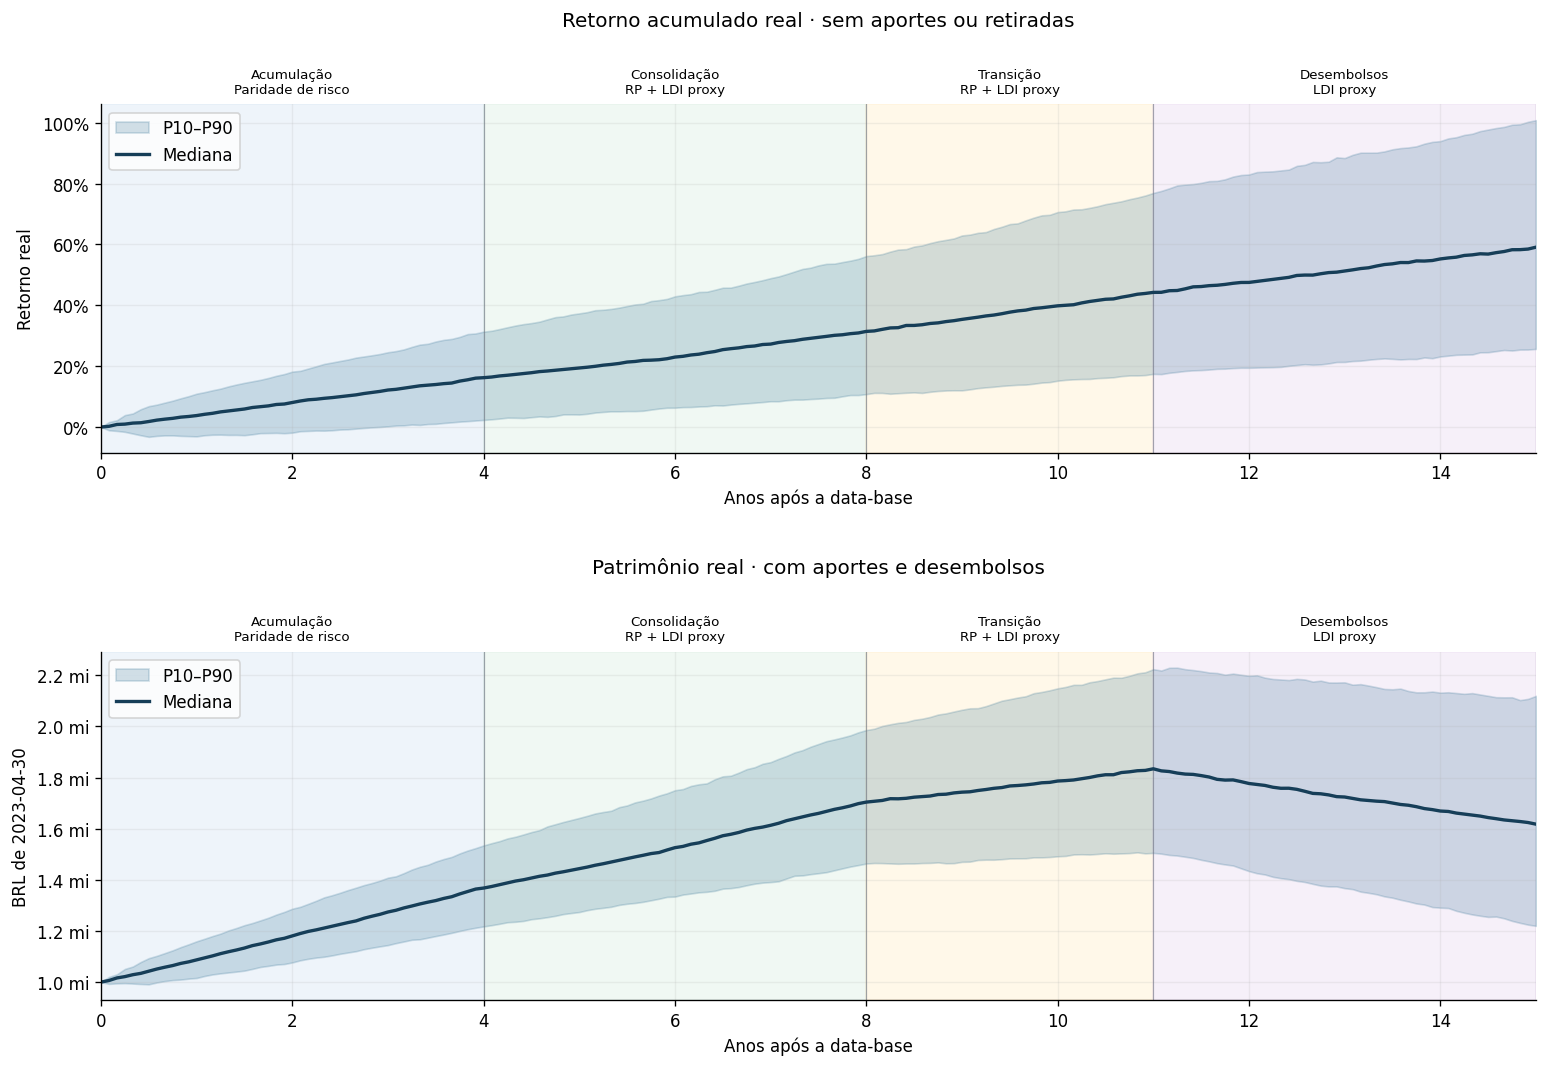

Probabilidade de insuficiência de caixa para alguma retirada: 0.0%
Probabilidade de falhar em alguma meta patrimonial: 29.6%


,checkpoint,month,goal_real,probability_goal_failure,probability_goal_funded,median_wealth,expected_goal_shortfall
0,Acumulação,48,1250000.0,0.1610,0.8390,1.367928e+06,9082.749122
1,Consolidação,96,1550000.0,0.2275,0.7725,1.704180e+06,22217.128015
2,Transição,132,1450000.0,0.0550,0.9450,1.834433e+06,4550.875036
3,Desembolsos,180,1100000.0,0.0430,0.9570,1.617813e+06,3810.582850


,phase,method,month_end,median_return,return_p10,return_p90,median_wealth,failure_in_phase,expected_shortfall
0,Acumulação,Paridade de risco,48,0.1621,0.0233,0.3133,1.367928e+06,0.0,0.0
1,Consolidação,RP + LDI proxy,96,0.1325,0.0040,0.2778,1.704180e+06,0.0,0.0
2,Transição,RP + LDI proxy,132,0.0990,-0.0118,0.2185,1.834433e+06,0.0,0.0
3,Desembolsos,LDI proxy,180,0.1038,-0.0244,0.2455,1.617813e+06,0.0,0.0


In [26]:
sim=state['simulation']; x=np.arange(sim['wealth'].shape[1])/12
phase_palette=['#dae7f4','#def0e5','#fff0cf','#ecdef2']
def phase_background(ax):
    start=0
    for p,color in zip(state['phases'],phase_palette):
        end=start+p['months']/12
        ax.axvspan(start,end,color=color,alpha=.45,zorder=0)
        ax.axvline(end,color='#6b7280',lw=.7,alpha=.6)
        ax.text((start+end)/2,1.025,p['name']+'\n'+METHOD_NAMES[p['selected_method']],transform=ax.get_xaxis_transform(),ha='center',va='bottom',fontsize=8)
        start=end
    ax.set_xlim(0,x[-1])
fig,axs=plt.subplots(2,1,figsize=(13,9))
for ax,arr,title,ylabel in [(axs[0],sim['nav']-1,'Retorno acumulado real · sem aportes ou retiradas','Retorno real'),(axs[1],sim['wealth'],'Patrimônio real · com aportes e desembolsos','BRL de '+str(ASOF.date()))]:
    p10,p50,p90=np.quantile(arr,[.1,.5,.9],axis=0)
    phase_background(ax);ax.fill_between(x,p10,p90,color='#24688d',alpha=.20,label='P10–P90');ax.plot(x,p50,color='#163e58',lw=2,label='Mediana')
    ax.set_title(title,pad=47);ax.set(xlabel='Anos após a data-base',ylabel=ylabel);ax.legend(loc='upper left')
axs[0].yaxis.set_major_formatter(PercentFormatter(1));axs[1].yaxis.set_major_formatter(FuncFormatter(lambda v,p:f'{v/1e6:.1f} mi'))
fig.tight_layout(h_pad=3);plt.show()
print(f'Probabilidade de insuficiência de caixa para alguma retirada: {sim["probability_any_shortfall"]:.1%}')
print(f'Probabilidade de falhar em alguma meta patrimonial: {sim.get("probability_any_goal_failure",np.nan):.1%}')
if 'goal_report' in sim: display(sim['goal_report'])
projection_summary=sim['summary'].copy();projection_summary['method']=projection_summary['method'].map(METHOD_NAMES)
display(projection_summary.round(4))

## 12 · Retorno de cada fase e ferramenta utilizada
Retorno total da fase, não anualizado; inclui custos, exclui aportes e retiradas. As barras mostram P10, mediana e P90 dos mesmos caminhos da projeção completa.

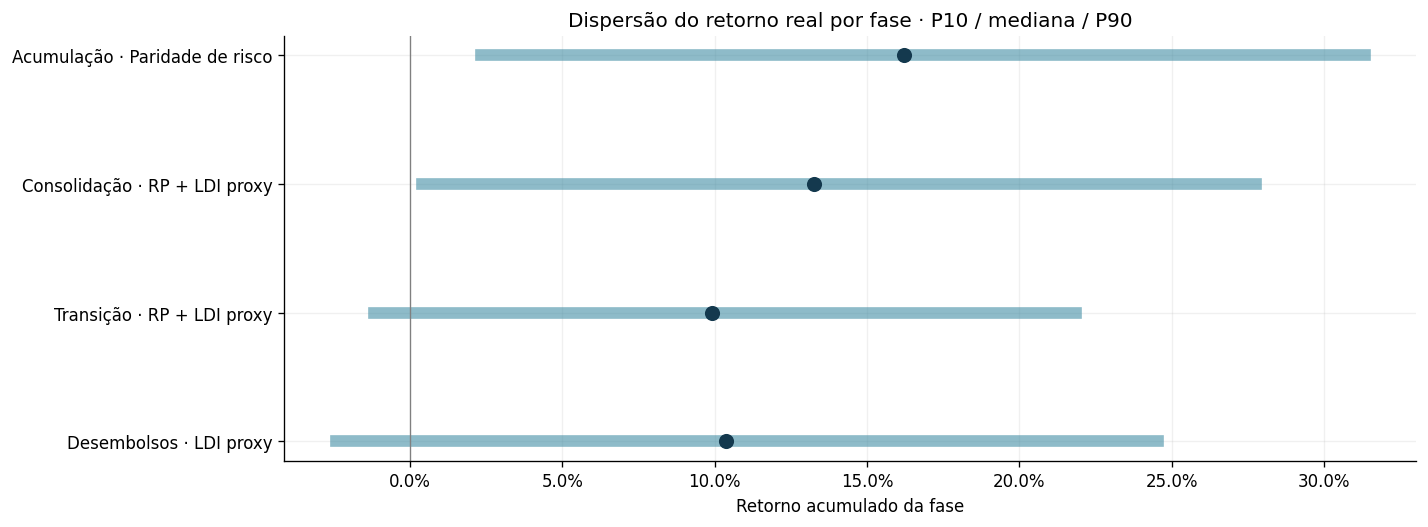

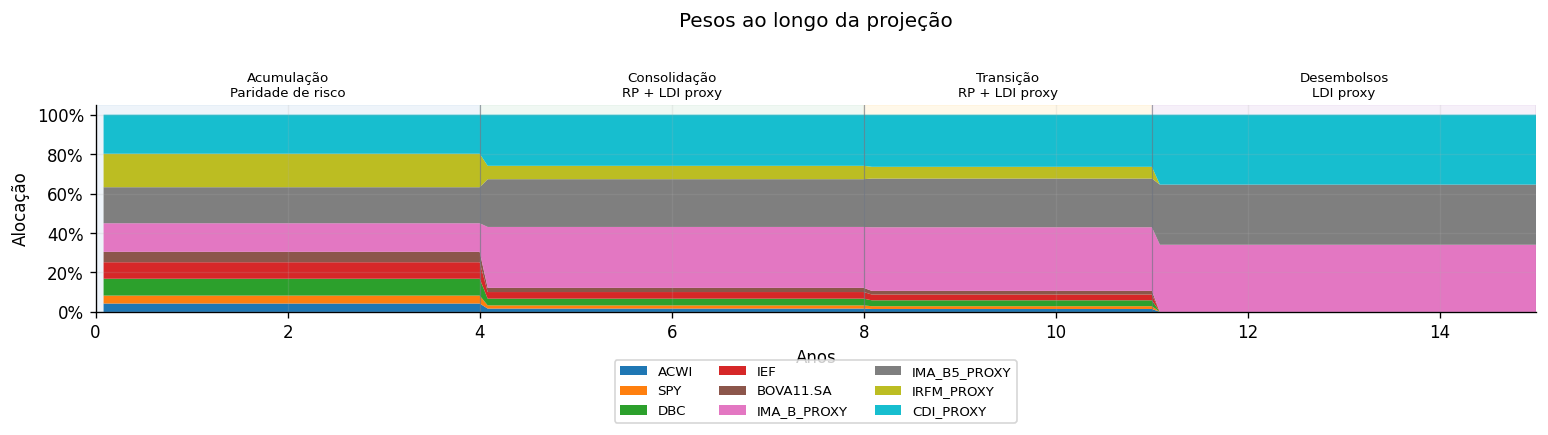

In [27]:
summary=sim['summary'];fig,ax=plt.subplots(figsize=(12,4.5));pos=np.arange(len(summary))
for i,row in summary.iterrows():
    ax.plot([row.return_p10,row.return_p90],[i,i],color='#438ea5',lw=7,alpha=.6)
    ax.scatter(row.median_return,i,color='#14394e',s=65,zorder=3)
ax.set_yticks(pos,[r.phase+' · '+METHOD_NAMES[r.method] for r in summary.itertuples()]);ax.invert_yaxis();ax.axvline(0,color='gray',lw=.8)
ax.xaxis.set_major_formatter(PercentFormatter(1));ax.set(title='Dispersão do retorno real por fase · P10 / mediana / P90',xlabel='Retorno acumulado da fase');fig.tight_layout();plt.show()
schedule=sim['schedule'];fig,ax=plt.subplots(figsize=(13,4))
ax.stackplot(schedule.month/12,*[schedule[c] for c in universe],labels=universe,colors=asset_colors)
phase_background(ax);ax.set(title='Pesos ao longo da projeção',xlabel='Anos',ylabel='Alocação');ax.set_title('Pesos ao longo da projeção',pad=47);ax.yaxis.set_major_formatter(PercentFormatter(1));ax.legend(ncol=3,fontsize=8,loc='upper center',bbox_to_anchor=(.5,-.20));fig.tight_layout();plt.show()

## 13 · Sensibilidade das projeções
Mantém métodos, pesos, fluxos e a mesma semente. Aplica um fator anual de retorno de −3%, 0% ou +3% a todos os ativos, multiplicativamente. É um teste hipotético de premissa; não estima probabilidades desses cenários e não substitui choques por fator.

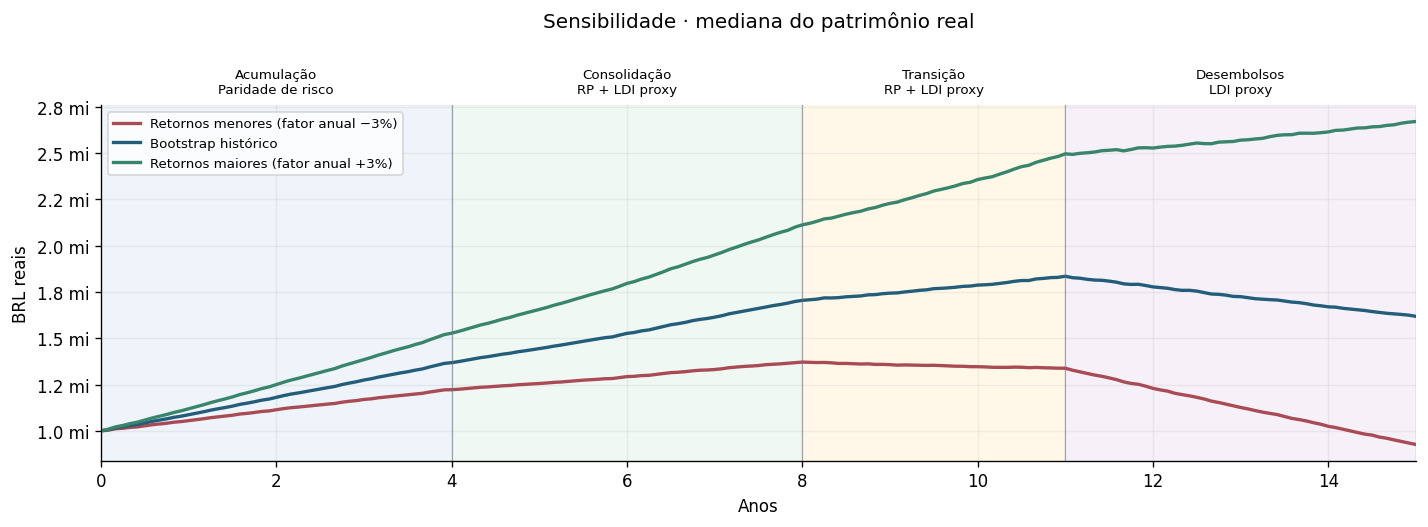

,scenario,terminal_median,probability_shortfall
0,Retornos menores (fator anual −3%),9.261922e+05,0.0
1,Bootstrap histórico,1.617813e+06,0.0
2,Retornos maiores (fator anual +3%),2.669499e+06,0.0


In [28]:
sens=[];fig,ax=plt.subplots(figsize=(12,4.5))
for shock,label,color in [(-.03,'Retornos menores (fator anual −3%)','#a94b55'),(0.,'Bootstrap histórico','#235d7a'),(.03,'Retornos maiores (fator anual +3%)','#39856b')]:
    scenario=project_phases(real_returns.tail(CONFIG['lookback']),state['phases'],state['allocations'],initial=CONFIG['initial'],n_paths=CONFIG['n_paths'],block=CONFIG['block'],seed=CONFIG['seed'],cost_bps=CONFIG['cost_bps'],shock_annual=shock)
    ax.plot(x,np.median(scenario['wealth'],axis=0),label=label,color=color,lw=2)
    sens.append({'scenario':label,'terminal_median':np.median(scenario['wealth'][:,-1]),'probability_shortfall':scenario['probability_any_shortfall']})
phase_background(ax);ax.set_title('Sensibilidade · mediana do patrimônio real',pad=47);ax.set(xlabel='Anos',ylabel='BRL reais');ax.yaxis.set_major_formatter(FuncFormatter(lambda v,p:f'{v/1e6:.1f} mi'));ax.legend(fontsize=8);fig.tight_layout();plt.show();display(pd.DataFrame(sens))

## 14 · Passivo e risco de duration — aproximação separada
Fluxos e taxa abaixo são hipotéticos, em BRL reais. O valor do passivo é recalculado com curva real plana; os ativos recebem aproximação linear de duration, sem convexidade. A comparação serve para estudar descasamento, não para declarar imunização. A duration usada pelo construtor pode ser ajustada para esta estimativa e o grafo reexecutado.

,liability_pv,liability_duration,asset_duration_assumed,asset_value_median
0,415629.760381,2.764305,2.994116,1.617813e+06


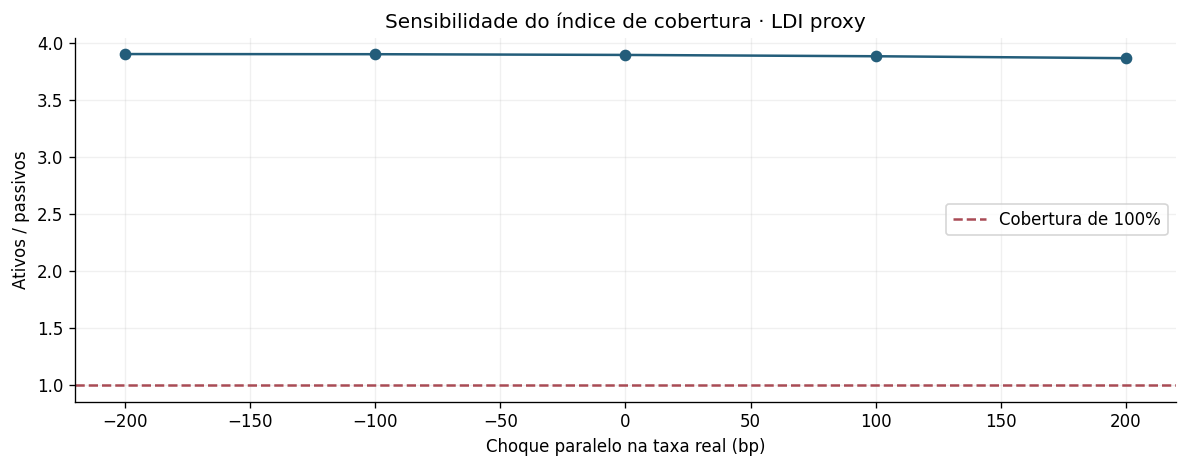

,funding_ratio_p10,funding_ratio_mediano,funding_ratio_p90,prob_funding_below_1
0,3.53x,5.55x,8.35x,0.0%


In [29]:
liability_flows=pd.DataFrame({'year':np.arange(1,6),'amount_real':np.full(5,96_000.)})
liability=liability_pv(liability_flows,real_yield=.05)
last_w=state['allocations'][state['phases'][-1]['name']]
asset_duration=sum(last_w[c]*REAL_DURATIONS.get(c,0.) for c in universe)
asset_value=float(np.median(sim['wealth'][:,-1]))
ldi_table=liability_sensitivity(liability_flows,asset_value,asset_duration)
display(pd.DataFrame([{'liability_pv':liability['pv'],'liability_duration':liability['modified_duration'],'asset_duration_assumed':asset_duration,'asset_value_median':asset_value}]))
fig,ax=plt.subplots(figsize=(10,4));ax.plot(ldi_table.index,ldi_table.funding_ratio,marker='o',color='#235d7a');ax.axhline(1,color='#a94b55',ls='--',label='Cobertura de 100%');ax.set(title='Sensibilidade do índice de cobertura · LDI proxy',xlabel='Choque paralelo na taxa real (bp)',ylabel='Ativos / passivos');ax.legend();fig.tight_layout();plt.show()

# Distribuição do funding ratio terminal sob a política dinâmica selecionada.
selected_terminal=seq['evaluations'][seq['selected']]['wealth'][:,-1]
terminal_funding=selected_terminal/max(liability['pv'],1e-12)
funding_test=pd.DataFrame([{
    'funding_ratio_p10':np.quantile(terminal_funding,.10),
    'funding_ratio_mediano':np.median(terminal_funding),
    'funding_ratio_p90':np.quantile(terminal_funding,.90),
    'prob_funding_below_1':float((terminal_funding<1).mean())
}])
display(funding_test.style.format({
    'funding_ratio_p10':'{:.2f}x','funding_ratio_mediano':'{:.2f}x',
    'funding_ratio_p90':'{:.2f}x','prob_funding_below_1':'{:.1%}'}))


## 15 · Exportação opcional e limites de interpretação
O notebook é autossuficiente. Para gerar arquivos externos, ative a opção abaixo. Pesos, agenda de métodos, métricas e log são exportados sem prompts privados ou credenciais.

**Antes de estender o estudo:** use curvas e durations observadas, séries atuais validadas, passivos completos, impostos e custos adequados ao veículo. Uma projeção de 15 anos baseada em cinco anos de estimação é muito sensível à mudança de regime. A programação dinâmica aqui é uma aproximação tabular do problema de metas e patrimônio; não é uma implementação completa de GBWM, não contém modelo macroeconômico estrutural, reinvestimento explícito de capital humano nem otimização contínua de cada trajetória. O Bellman marginaliza a dependência serial no passo de decisão; essa hipótese é tratada por testes de sensibilidade, não eliminada. As probabilidades são resultados do experimento especificado, não previsões calibradas do mundo real.


In [38]:
EXPORT_RESULTS=False
if EXPORT_RESULTS:
    out=Path('portfolio_results');out.mkdir(exist_ok=True)
    phase_weights.to_csv(out/'allocation_by_phase.csv')
    metrics.to_csv(out/'historical_metrics.csv')
    sim['summary'].to_csv(out/'projection_by_phase.csv',index=False)
    sim['schedule'].to_csv(out/'method_and_weights_by_month.csv',index=False)
    (out/'audit_log.json').write_text(json.dumps(state['log'],ensure_ascii=False,indent=2),encoding='utf-8')
    print('Resultados exportados para:',out.resolve())
print('Validação concluída:',test_results)
print('Última observação usada na projeção:',ASOF.date())
print('Modo de planejamento executado:',CONFIG['planner_mode'])

Validação concluída: {'passed': 26, 'failures': 0, 'errors': 0}
Última observação usada na projeção: 2023-04-30
Modo de planejamento executado: rules


## 16 · Os números publicados

Cada célula desta seção reproduz um número afirmado na série de posts, com os
dados e as restrições deste notebook. **Rode antes de publicar**: se um número
aqui divergir do texto do post, o texto é que está errado.

As metas abaixo são **cenários editáveis**, não um plano pessoal. Os valores
publicados dependem de `Policy`, do universo e da amostra — mudou qualquer um
dos três, os números mudam.

### Replicação do exemplo numérico do paper

Antes de aplicar ao Brasil, o notebook reproduz os números do próprio Das, Markowitz, Scheid e Statman (2010) com os insumos publicados na eq. (4): três ativos com μ = (5%, 10%, 25%), a covariância do paper, γ = 3,7950 / 2,7063 / 0,8773 para aposentadoria, educação e legado, mix 60:20:20 e as metas (H, α) da Figura 4.

Isso separa duas perguntas que a V4.1 misturava: **(i) a implementação reproduz o paper?** e **(ii) o que acontece com dados brasileiros?** A segunda depende do shrinkage e das metas escolhidas; a primeira não depende de nada disso. As asserções no fim da célula fazem o notebook falhar se a replicação deixar de bater.

In [39]:
# ---- Replicação: Tabela 1 e Seção V de Das, Markowitz, Scheid e Statman (2010) ----
from scipy.optimize import minimize as _minimize
MU_P=np.array([.05,.10,.25]); SIG_P=np.array([[.0025,0,0],[0,.04,.02],[0,.02,.25]]); _one=np.ones(3)
GAMMAS_P={'Aposentadoria':3.7950,'Educação':2.7063,'Legado':0.8773}
MIX_P={'Aposentadoria':.60,'Educação':.20,'Legado':.20}
METAS_P={'Aposentadoria':(-.10,.05),'Educação':(-.05,.15),'Legado':(-.15,.20)}   # (H, alpha), Figura 4
_m=lambda w:float(w@MU_P); _s=lambda w:float(np.sqrt(w@SIG_P@w))

def _mv_irrestrito(g):
    """Eq. (3): max w'mu - g/2 w'Sw  s.a. w'1 = 1, com venda a descoberto."""
    Si=np.linalg.inv(SIG_P); lam=(_one@Si@MU_P-g)/(_one@Si@_one); return Si@(MU_P-lam*_one)/g

def _ma_sem_venda(H,alpha):
    """Critério de contas mentais sem venda a descoberto: max E[r] s.a. P(r<H) <= alpha, w >= 0."""
    z=norm.ppf(alpha); melhor=None
    for x0 in (np.ones(3)/3,np.array([0,.3,.7]),np.array([0,.1,.9])):
        r=_minimize(lambda w:-_m(w),x0,bounds=[(0,1)]*3,method='SLSQP',options={'ftol':1e-15,'maxiter':2000},
                    constraints=[{'type':'eq','fun':lambda w:w.sum()-1},{'type':'ineq','fun':lambda w:_m(w)+z*_s(w)-H}])
        if r.success and (melhor is None or _m(r.x)>_m(melhor)): melhor=r.x
    return melhor

def _fronteira_sem_venda(vol):
    """Maior retorno da fronteira sem venda a descoberto para uma vol dada."""
    r=_minimize(lambda w:-_m(w),np.array([.2,.4,.4]),bounds=[(0,1)]*3,method='SLSQP',options={'ftol':1e-15,'maxiter':2000},
                constraints=[{'type':'eq','fun':lambda w:w.sum()-1},{'type':'ineq','fun':lambda w:vol**2-w@SIG_P@w}])
    return _m(r.x)

# Tabela 1: cada conta é o portfólio MV com o gamma do paper
W_P={k:_mv_irrestrito(g) for k,g in GAMMAS_P.items()}
agg_P=sum(MIX_P[k]*W_P[k] for k in W_P)
tab1=pd.DataFrame({**{k:[*w,_m(w),_s(w),norm.cdf((METAS_P[k][0]-_m(w))/_s(w))] for k,w in W_P.items()},
                   'Agregado 60:20:20':[*agg_P,_m(agg_P),_s(agg_P),np.nan]},
                  index=['bond','ação baixo risco','ação alto risco','E[r]','vol','P(r < H)'])
print('Tabela 1 reproduzida (sem restrição de venda a descoberto):')
display(tab1.style.format('{:.5f}',na_rep='—'))
assert np.allclose(W_P['Aposentadoria'],[0.53943,0.26562,0.19495],atol=1e-5)
assert np.allclose(W_P['Educação'],[0.37873,0.34986,0.27141],atol=2e-5)
assert np.allclose(W_P['Legado'],[-0.78904,0.96200,0.82704],atol=2e-5)
assert abs(_m(agg_P)-.1384)<5e-5 and abs(_s(agg_P)-.2032)<5e-5
for _k,(_H,_a) in METAS_P.items():   # equivalência MA <-> MV: cada conta fica exatamente no seu alpha
    assert abs(norm.cdf((_H-_m(W_P[_k]))/_s(W_P[_k]))-_a)<5e-3

# Seção V: sem venda a descoberto só o Legado muda (era vendido no bond) e é
# reotimizado pelo critério de contas mentais, não pelo mesmo gamma.
W_C=dict(W_P); W_C['Legado']=_ma_sem_venda(*METAS_P['Legado'])
agg_C=sum(MIX_P[k]*W_C[k] for k in W_C); front_C=_fronteira_sem_venda(_s(agg_C)); custo_P=(front_C-_m(agg_C))*1e4
print(f"\nLegado sem venda a descoberto: w = {np.round(W_C['Legado'],4)} | E[r] = {_m(W_C['Legado']):.2%} | vol = {_s(W_C['Legado']):.2%}")
print(f"Agregado:                       E[r] = {_m(agg_C):.2%} | vol = {_s(agg_C):.2%}     paper: 13,31% | 19,89%")
print(f"Fronteira restrita na mesma vol: {front_C:.2%}                        paper: 13,43%")
print(f"Custo da segregação:             {custo_P:.1f} bps                       paper: 12 bp (p. 329)")
assert abs(_m(agg_C)-.1331)<2e-4 and abs(front_C-.1343)<2e-4 and abs(custo_P-12)<1.
_f1989=_fronteira_sem_venda(.1989)
print(f"\nNota: a vol agregada reproduzida é {_s(agg_C):.2%}, não os 19,89% impressos. Com 19,89% a fronteira")
print(f"restrita daria {_f1989:.2%} e o custo {(_f1989-.1331)*1e4:.0f} bps — incompatível com os 13,43% e 12 bp do próprio")
print("paper. Os três números impressos só fecham entre si com a vol reproduzida aqui.")
print("Leitura do critério: com o mesmo gamma em vez do critério MA, o custo sairia ~6 bps — não os 12 do paper.")

Tabela 1 reproduzida (sem restrição de venda a descoberto):


,Aposentadoria,Educação,Legado,Agregado 60:20:20
bond,0.53943,0.37874,-0.78903,0.24160
ação baixo risco,0.26562,0.34985,0.96199,0.42174
ação alto risco,0.19495,0.27141,0.82704,0.33666
E[r],0.10227,0.12177,0.26351,0.13842
vol,0.12297,0.16573,0.49132,0.20316
P(r < H),0.05000,0.15000,0.20000,—



Legado sem venda a descoberto: w = [0.     0.0889 0.9111] | E[r] = 23.67% | vol = 45.94%
Agregado:                       E[r] = 13.30% | vol = 19.38%     paper: 13,31% | 19,89%
Fronteira restrita na mesma vol: 13.43%                        paper: 13,43%
Custo da segregação:             12.4 bps                       paper: 12 bp (p. 329)

Nota: a vol agregada reproduzida é 19.38%, não os 19,89% impressos. Com 19,89% a fronteira
restrita daria 13.65% e o custo 34 bps — incompatível com os 13,43% e 12 bp do próprio
paper. Os três números impressos só fecham entre si com a vol reproduzida aqui.
Leitura do critério: com o mesmo gamma em vez do critério MA, o custo sairia ~6 bps — não os 12 do paper.


### As duas perguntas

In [40]:
# ---- Post 1: as duas perguntas -> gamma deduzido -------------------------
CONTAS_PUBLICADAS = [
    {'nome':'Proteção',      'capital':.20, 'years':3,  'target_real':.010, 'alpha':.05},
    {'nome':'Aposentadoria', 'capital':.55, 'years':15, 'target_real':.030, 'alpha':.15},
    {'nome':'Legado',        'capital':.25, 'years':25, 'target_real':.035, 'alpha':.30},
]
mu_pub, cov_pub = moments(real_returns, history_policy)
print(f'Amostra: {real_returns.index[0].date()} a {real_returns.index[-1].date()} '
      f'| {len(real_returns)} meses reais\n')
linhas = []
for c in CONTAS_PUBLICADAS:
    g, w, d = gamma_implicito(real_returns, history_policy, c['years'],
                              c['target_real'], c['alpha'])
    linhas.append({'conta':c['nome'], 'meta_real_aa':c['target_real'], 'alpha':c['alpha'],
                   'piso_maximo_aa':d.get('piso_maximo_aa'),
                   'gamma_implicito':g, 'prob_falha':d.get('prob_falha'),
                   'status':d['status']})
diag = pd.DataFrame(linhas).set_index('conta')
display(diag.style.format({'meta_real_aa':'{:.2%}','alpha':'{:.0%}',
                           'piso_maximo_aa':'{:.2%}','gamma_implicito':'{:.2f}',
                           'prob_falha':'{:.1%}'}, na_rep='—'))
print(f"mean_shrink em uso: {history_policy.mean_shrink:.2f} | prior: {history_policy.prior_model}")
print(f"O notebook usa risk_aversion = {history_policy.risk_aversion} fixo para todas as contas.")
print('A coluna gamma_implicito é o que o artigo diz para usar no lugar disso — só onde status = ok.')
if (diag.status=='meta inviável').any():
    print('\nMeta inviável: a meta está acima do piso máximo que o universo sustenta naquela confiança.')
    print('Nenhuma alocação resolve — o ajuste é na meta, no prazo ou no aporte (Das et al., p. 325).')
if (diag.status=='restrição não aperta').any():
    print(f'\nRestrição não aperta: até a carteira mais agressiva da busca (gamma = {GAMMA_MIN}) cumpre a meta.')
    print('O gamma não é identificável nesse caso; publicar o limite da busca como "gamma deduzido" seria erro.')

Amostra: 2010-02-28 a 2023-04-30 | 159 meses reais



,meta_real_aa,alpha,piso_maximo_aa,gamma_implicito,prob_falha,status
conta,,,,,,
Proteção,1.00%,5%,0.63%,—,—,meta inviável
Aposentadoria,3.00%,15%,2.45%,—,—,meta inviável
Legado,3.50%,30%,3.08%,—,—,meta inviável


mean_shrink em uso: 1.00 | prior: equilibrium
O notebook usa risk_aversion = 5.0 fixo para todas as contas.
A coluna gamma_implicito é o que o artigo diz para usar no lugar disso — só onde status = ok.

Meta inviável: a meta está acima do piso máximo que o universo sustenta naquela confiança.
Nenhuma alocação resolve — o ajuste é na meta, no prazo ou no aporte (Das et al., p. 325).


### O custo de somar as sub-carteiras

In [41]:
# ---- Posts 2 e 3: o custo de somar sub-carteiras — aplicação ao Brasil ---
# O número do paper (12 bps) é reproduzido na célula de replicação acima, com os
# insumos do próprio paper. Aqui a pergunta é outra: o que acontece com dados reais.
resumo, pesos_conta, agregado, inviaveis = contas_mentais(
    real_returns, history_policy, CONTAS_PUBLICADAS)
if len(resumo):
    display(resumo.style.format({'capital':'{:.0%}','meta_real_aa':'{:.2%}','alpha':'{:.0%}',
                                 'gamma_implicito':'{:.2f}','retorno_esp_aa':'{:.2%}',
                                 'vol_aa':'{:.2%}','prob_falha':'{:.1%}'},na_rep='—'))
if len(inviaveis):
    print('Contas fora do agregado sob a Policy em uso:')
    display(inviaveis.reindex(columns=['conta','meta_real_aa','piso_maximo_aa','status'])
            .style.format({'meta_real_aa':'{:.2%}','piso_maximo_aa':'{:.2%}'},na_rep='—'))

if agregado is None:
    print(f'\nNenhuma conta viável com mean_shrink = {history_policy.mean_shrink:.2f}: não há agregado,')
    print('então o custo de somar sub-carteiras não se define com estes dados.')
    print('Com os retornos esperados da Policy em uso, as metas publicadas ficam acima do piso que o')
    print('universo sustenta. É o subproduto do POMA: a conversa passa a ser meta, prazo ou aporte.')
elif pesos_conta.shape[1] < 2:
    print('\nSó uma conta viável: o custo de somar sub-carteiras não se define.')
else:
    agg = custo_da_agregacao(real_returns, history_policy, agregado)
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
    pesos_conta.T.plot.barh(stacked=True, ax=ax[0], width=.7)
    ax[0].set(title='Sub-carteira por conta mental', xlabel='Peso')
    ax[0].xaxis.set_major_formatter(PercentFormatter(1))
    ax[0].legend(ncol=3, fontsize=7, loc='upper center', bbox_to_anchor=(.5,-.22))
    agregado[agregado > 5e-4].sort_values().plot.barh(ax=ax[1], color='#444')
    ax[1].set(title=f'Agregado · custo {agg["custo_bps"]:.1f} bps a.a.', xlabel='Peso')
    ax[1].xaxis.set_major_formatter(PercentFormatter(1))
    plt.tight_layout(); plt.show()
    print(f"vol {agg['vol_aa']:.2%} | agregado {agg['retorno_agregado_aa']:.2%} "
          f"| fronteira na mesma vol {agg['retorno_fronteira_aa']:.2%}")
    print(f">> custo da contabilidade mental: {agg['custo_bps']:.1f} bps a.a.")
print('\n   paper, com restrição de venda a descoberto: 12 bps (p. 329) — reproduzido acima')
print('   errar o gamma, no mesmo paper: 5 a 40 bps (p. 326, Tabela 3)')


Contas fora do agregado sob a Policy em uso:


,conta,meta_real_aa,piso_maximo_aa,status
0,Proteção,1.00%,0.63%,meta inviável
1,Aposentadoria,3.00%,2.45%,meta inviável
2,Legado,3.50%,3.08%,meta inviável



Nenhuma conta viável com mean_shrink = 1.00: não há agregado,
então o custo de somar sub-carteiras não se define com estes dados.
Com os retornos esperados da Policy em uso, as metas publicadas ficam acima do piso que o
universo sustenta. É o subproduto do POMA: a conversa passa a ser meta, prazo ou aporte.

   paper, com restrição de venda a descoberto: 12 bps (p. 329) — reproduzido acima
   errar o gamma, no mesmo paper: 5 a 40 bps (p. 326, Tabela 3)


### De onde vem o risco de um 60/40

In [42]:
# ---- Post 4: de onde vem o risco de um 60/40 ----------------------------
acao = 'BOVA11.SA'
candidatos = [c for c in ['IMA_B5_PROXY','IRFM_PROXY','IMA_B_PROXY'] if c in real_returns.columns]
linhas = []
for rf in candidatos:
    tab, vol = contribuicao_risco(real_returns, history_policy, {acao:.60, rf:.40})
    linhas.append({'perna de renda fixa':rf, 'vol_carteira_aa':vol,
                   'risco_de_acoes':tab.loc[acao,'parcela_do_risco'],
                   'risco_da_renda_fixa':tab.loc[rf,'parcela_do_risco']})
tab60 = pd.DataFrame(linhas).set_index('perna de renda fixa')
display(tab60.style.format({'vol_carteira_aa':'{:.2%}','risco_de_acoes':'{:.1%}',
                            'risco_da_renda_fixa':'{:.1%}'}))
print('60% do capital em ações, mas a parcela do RISCO que vem de ações é a coluna do meio.')
print('Ela varia com a volatilidade e a correlação da perna de renda fixa —')
print('por isso o post diz "acima de 95%" ou "cerca de 83%", não "sempre 90%".')

,vol_carteira_aa,risco_de_acoes,risco_da_renda_fixa
perna de renda fixa,,,
IMA_B5_PROXY,13.57%,95.3%,4.7%
IRFM_PROXY,13.74%,93.9%,6.1%
IMA_B_PROXY,14.74%,87.0%,13.0%


60% do capital em ações, mas a parcela do RISCO que vem de ações é a coluna do meio.
Ela varia com a volatilidade e a correlação da perna de renda fixa —
por isso o post diz "acima de 95%" ou "cerca de 83%", não "sempre 90%".


### Capital humano no balanço

In [43]:
# ---- Post 5: capital humano no balanço, sem alavancagem -----------------
PERFIS = [
    {'rotulo':'25 anos', 'financeiro':  50_000, 'anos_de_trabalho':40},
    {'rotulo':'40 anos', 'financeiro': 400_000, 'anos_de_trabalho':25},
    {'rotulo':'55 anos', 'financeiro': 900_000, 'anos_de_trabalho':10},
]
SALARIO = 90_000
_g_apos = resumo['gamma_implicito'].get('Aposentadoria', np.nan) if len(resumo) else np.nan
if pd.notna(_g_apos) and np.isfinite(_g_apos):
    gamma_ref = float(_g_apos); _origem_gamma = 'deduzido da conta de aposentadoria'
else:
    gamma_ref = history_policy.risk_aversion
    _origem_gamma = 'fallback: risk_aversion da Policy — gamma da aposentadoria não identificável sob a Policy em uso'
linhas = []
for p in PERFIS:
    h = carteira_com_capital_humano(real_returns, history_policy, gamma_ref,
            p['financeiro'], SALARIO, p['anos_de_trabalho'])
    risco_total = float(h['otimo_do_balanco'].drop('CDI_PROXY', errors='ignore').sum())
    linhas.append({'perfil':p['rotulo'],'financeiro':p['financeiro'],
                   'vp_capital_humano':h['vp_capital_humano'],
                   'fatia_humana':h['fatia_humana'],
                   'risco_no_balanco_total':risco_total,
                   'risco_na_carteira_financeira':h['exposicao_a_risco'],
                   'alavancaria':h['precisaria_alavancar']})
ch = pd.DataFrame(linhas).set_index('perfil')
display(ch.style.format({'financeiro':'R$ {:,.0f}','vp_capital_humano':'R$ {:,.0f}',
                         'fatia_humana':'{:.0%}','risco_no_balanco_total':'{:.0%}',
                         'risco_na_carteira_financeira':'{:.0%}'}))
print('Leia as duas últimas colunas juntas. O balanço TOTAL tem uma alocação sensata;')
print('é a fatia financeira, pequena quando se é jovem, que precisaria ser extrema')
print('para chegar lá. Números de milhares por cento são o modelo dizendo que a conta')
print('não fecha sem alavancagem — não uma recomendação de carteira.')
print(f'gamma usado: {gamma_ref:.2f} — {_origem_gamma}')
print('Exposição acima de 100% é onde Ayres e Nalebuff pediriam alavancagem.')
print('O post não recomenda isso no Brasil: financiar a CDI destrói o argumento.')
print('\nRessalva honesta: aqui o capital humano é tratado como renda fixa sem risco.')
print('Ele não é — perda de emprego tende a coincidir com queda de mercado, o que')
print('reduz a exposição ótima. O número é um teto, não uma recomendação.')

,financeiro,vp_capital_humano,fatia_humana,risco_no_balanco_total,risco_na_carteira_financeira,alavancaria
perfil,,,,,,
25 anos,"R$ 50,000","R$ 1,781,350",97%,75%,2735%,True
40 anos,"R$ 400,000","R$ 1,405,987",78%,75%,337%,True
55 anos,"R$ 900,000","R$ 729,981",45%,75%,135%,True


Leia as duas últimas colunas juntas. O balanço TOTAL tem uma alocação sensata;
é a fatia financeira, pequena quando se é jovem, que precisaria ser extrema
para chegar lá. Números de milhares por cento são o modelo dizendo que a conta
não fecha sem alavancagem — não uma recomendação de carteira.
gamma usado: 5.00 — fallback: risk_aversion da Policy — gamma da aposentadoria não identificável sob a Policy em uso
Exposição acima de 100% é onde Ayres e Nalebuff pediriam alavancagem.
O post não recomenda isso no Brasil: financiar a CDI destrói o argumento.

Ressalva honesta: aqui o capital humano é tratado como renda fixa sem risco.
Ele não é — perda de emprego tende a coincidir com queda de mercado, o que
reduz a exposição ótima. O número é um teto, não uma recomendação.


### Sensibilidade do shrinkage e mapa de estabilidade da política Bellman

O valor central de `mean_shrink` agora vem da validação walk-forward. A análise abaixo ainda percorre uma grade ampla para responder uma pergunta diferente: **a conclusão sobre qual ferramenta Bellman escolhe é estável quando a regularização muda?**

Para cada intensidade, o notebook reconstrói as carteiras candidatas com o mesmo prior econômico, resolve novamente o Bellman e avalia a política em trajetórias comuns. São reportados valor inicial, patrimônio terminal, falha de metas e participação de cada metodologia. Uma política robusta deve mudar gradualmente; saltos concentrados em pequenas alterações de shrinkage indicam que as ferramentas têm valores muito próximos ou que a especificação de retornos esperados domina o resultado.


,amplitude_mu,amplitude_prior,maior_mu,piso_maximo_aa,gamma_implicito,status
mean_shrink,,,,,,
0.000000,15.18%,2.28%,15.12%,7.89%,—,restrição não aperta
0.100000,13.79%,2.28%,14.12%,7.22%,—,restrição não aperta
0.200000,12.41%,2.28%,13.13%,6.55%,—,restrição não aperta
0.300000,11.03%,2.28%,12.13%,5.91%,—,restrição não aperta
0.400000,9.64%,2.28%,11.14%,5.28%,—,restrição não aperta
0.500000,8.26%,2.28%,10.14%,4.68%,—,restrição não aperta
0.600000,6.88%,2.28%,9.15%,4.08%,—,restrição não aperta
0.700000,5.49%,2.28%,8.16%,3.50%,—,restrição não aperta
0.800000,4.27%,2.28%,7.16%,3.02%,4.99,ok


,mean_shrink,status,valor_inicial,patrimonio_terminal_mediano,prob_falha_meta,prob_shortfall_retirada,acoes_viaveis_min
0,0.00,ok,1.8782,"R$ 4,016,281",19.8%,0.0%,7
1,0.10,ok,1.8717,"R$ 3,942,737",19.4%,0.0%,7
2,0.20,ok,1.8596,"R$ 3,812,311",19.0%,0.0%,7
3,0.30,ok,1.8456,"R$ 3,761,969",18.2%,0.0%,8
4,0.40,ok,1.8301,"R$ 3,645,772",17.8%,0.0%,8
5,0.50,ok,1.8102,"R$ 3,549,924",16.4%,0.0%,8
6,0.60,ok,1.7888,"R$ 3,453,350",15.6%,0.0%,8
7,0.70,ok,1.7860,"R$ 3,387,527",16.0%,0.0%,8
8,0.80,ok,1.6732,"R$ 3,067,207",14.2%,0.0%,8
9,0.90,ok,1.4599,"R$ 2,535,824",17.6%,0.0%,8


method,equal,mean_variance,min_variance,poma,poma_piso_max,saa
mean_shrink,,,,,,
0.000000,0.0%,1.2%,11.0%,0.0%,0.0%,87.8%
0.100000,0.0%,1.3%,10.3%,0.0%,0.0%,88.3%
0.200000,0.0%,1.9%,9.3%,0.0%,0.0%,88.7%
0.300000,0.0%,0.8%,8.7%,0.1%,0.0%,90.4%
0.400000,0.0%,0.0%,8.0%,0.0%,0.0%,92.0%
0.500000,0.0%,0.0%,6.9%,0.0%,0.0%,93.1%
0.600000,0.0%,0.0%,2.5%,0.0%,3.4%,94.1%
0.700000,0.0%,0.0%,2.3%,0.0%,3.1%,94.5%
0.800000,0.0%,0.0%,0.0%,0.0%,29.0%,71.0%


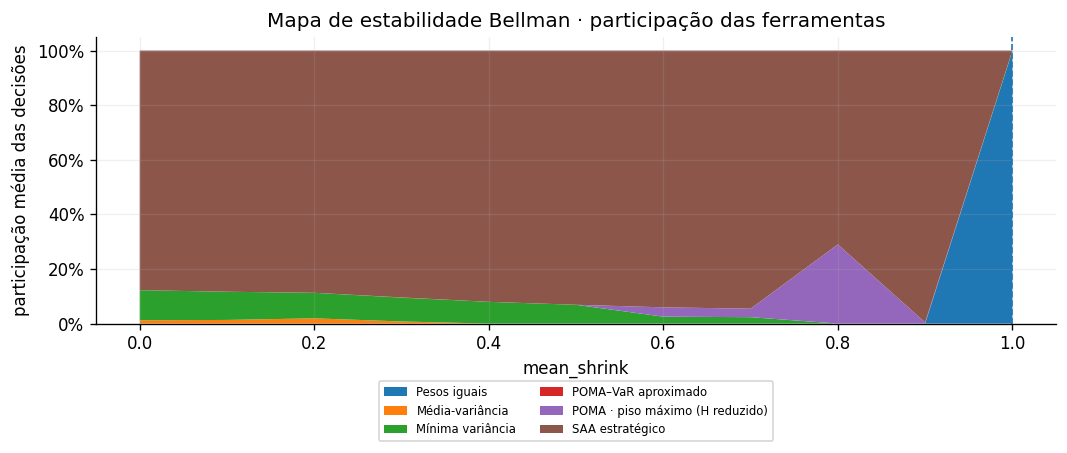

phase,Acumulação,Consolidação,Desembolsos,Transição
mean_shrink,,,,
0.0,SAA estratégico,SAA estratégico,SAA estratégico,SAA estratégico
0.1,SAA estratégico,SAA estratégico,SAA estratégico,SAA estratégico
0.2,SAA estratégico,SAA estratégico,SAA estratégico,SAA estratégico
0.3,SAA estratégico,SAA estratégico,SAA estratégico,SAA estratégico
0.4,SAA estratégico,SAA estratégico,SAA estratégico,SAA estratégico
0.5,SAA estratégico,SAA estratégico,SAA estratégico,SAA estratégico
0.6,SAA estratégico,SAA estratégico,SAA estratégico,SAA estratégico
0.7,SAA estratégico,SAA estratégico,SAA estratégico,SAA estratégico
0.8,SAA estratégico,POMA · piso máximo (H reduzido),SAA estratégico,SAA estratégico


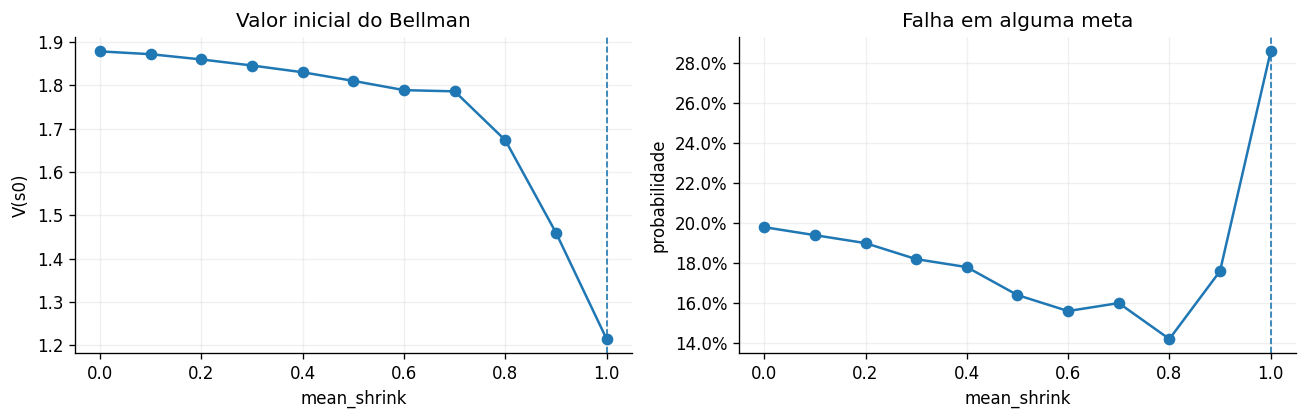

Shrink selecionado por CV: 1.00 | prior: equilibrium


In [36]:

# ---- V4: diagnóstico do prior + mapa de estabilidade Bellman --------------
META_TESTE, ALPHA_TESTE, ANOS_TESTE = .030, .15, 15
shrink_grid=sorted({float(x) for x in CONFIG['stability']['mean_shrink_grid']}|{round(float(history_policy.mean_shrink),2)})  # V4.2: inclui o shrink em uso

# Diagnóstico estático dos retornos esperados sob o prior econômico.
linhas=[]
for s in shrink_grid:
    pol=replace(history_policy,mean_shrink=float(s))
    mu_s,cov_s=moments(real_returns,pol)
    try:
        g,w,d=gamma_implicito(real_returns,pol,ANOS_TESTE,META_TESTE,ALPHA_TESTE)
        status=d.get('status','ok'); piso=d.get('piso_maximo_aa',np.nan)
    except Exception as exc:
        g=np.nan;piso=np.nan;status=str(exc)[:80]
    prior_s=economic_prior_returns(real_returns,pol,cov_s)
    linhas.append({'mean_shrink':s,'amplitude_mu':mu_s.max()-mu_s.min(),
                   'amplitude_prior':prior_s.max()-prior_s.min(),
                   'maior_mu':mu_s.max(),'piso_maximo_aa':piso,
                   'gamma_implicito':g,'status':status})
shrink_diagnostics=pd.DataFrame(linhas).set_index('mean_shrink')
display(shrink_diagnostics.style.format({'amplitude_mu':'{:.2%}','amplitude_prior':'{:.2%}',
    'maior_mu':'{:.2%}','piso_maximo_aa':'{:.2%}','gamma_implicito':'{:.2f}'},na_rep='—'))

# Reotimiza Bellman para cada shrink. Usa a mesma janela, estados, custos e cenários.
hist_stab=real_returns.tail(CONFIG['lookback'])
_saa_hist=real_returns.iloc[:-CONFIG['lookback']]
stab_rows=[];mix_rows=[];dominant_rows=[]
for s in shrink_grid:
    pol=replace(history_policy,mean_shrink=float(s))
    try:
        _saa_w=dict(mean_variance_weights(_saa_hist,pol)) if len(_saa_hist)>=36 else None
        lib,fail=build_action_library(hist_stab,state['phases'],pol,saa_weights=_saa_w)
        sol=solve_dynamic_programming(
            hist_stab,state['phases'],lib,initial=CONFIG['initial'],
            n_wealth_bins=CONFIG['rl_wealth_bins'],n_quantiles=CONFIG['dp_quantiles'],
            cost_bps=CONFIG['cost_bps'],switch_penalty=CONFIG['switch_penalty'],
            transition_scheme=CONFIG['transition_scheme'],block=CONFIG['block'],
            risk_objective=CONFIG.get('risk_objective','goal'),risk_lambda=CONFIG.get('risk_lambda',.25),
            risk_alpha=CONFIG['robustness']['risk_alpha'],risk_mar=CONFIG['robustness']['risk_mar_monthly'])
        ev=simulate_sequential_policy(
            hist_stab,state['phases'],lib,sol,initial=CONFIG['initial'],
            n_paths=CONFIG['stability']['n_paths'],block=CONFIG['block'],cost_bps=CONFIG['cost_bps'],
            seed=CONFIG['seed']+5000,transition_scheme=CONFIG['transition_scheme'])
        V=value_function(sol,state['phases'],lib,CONFIG['initial'])
        v0=value_at_wealth(sol,V,0,CONFIG['initial'],sol['initial_prev'])
        stab_rows.append({'mean_shrink':s,'status':'ok','valor_inicial':v0,
                          'patrimonio_terminal_mediano':np.median(ev['wealth'][:,-1]),
                          'prob_falha_meta':ev['probability_any_goal_failure'],
                          'prob_shortfall_retirada':ev['probability_any_withdrawal_shortfall'],
                          'acoes_viaveis_min':min(len(lib[p['name']]) for p in state['phases'])})
        mix=ev['action_mix'].copy();mix['mean_shrink']=s;mix_rows.append(mix)
        for pname,gp in mix.groupby('phase'):
            z=gp.sort_values('share_of_decisions',ascending=False).iloc[0]
            dominant_rows.append({'mean_shrink':s,'phase':pname,'dominant_method':z['method'],
                                  'dominant_share':z['share_of_decisions']})
    except Exception as exc:
        stab_rows.append({'mean_shrink':s,'status':str(exc)[:100],'valor_inicial':np.nan,
                          'patrimonio_terminal_mediano':np.nan,'prob_falha_meta':np.nan,
                          'prob_shortfall_retirada':np.nan,'acoes_viaveis_min':np.nan})

bellman_shrink_stability=pd.DataFrame(stab_rows)
bellman_action_mix=pd.concat(mix_rows,ignore_index=True) if mix_rows else pd.DataFrame()
bellman_dominant=pd.DataFrame(dominant_rows)
display(bellman_shrink_stability.style.format({'mean_shrink':'{:.2f}','valor_inicial':'{:.4f}',
    'patrimonio_terminal_mediano':'R$ {:,.0f}','prob_falha_meta':'{:.1%}',
    'prob_shortfall_retirada':'{:.1%}'}))

if not bellman_action_mix.empty:
    # V4.2: método ausente numa fase conta como 0% naquela fase; média ponderada pelos meses.
    _piv=bellman_action_mix.pivot_table(index=['mean_shrink','phase'],columns='method',
            values='share_of_decisions',aggfunc='sum',fill_value=0)
    _w=pd.Series(_piv.index.get_level_values('phase').map({p['name']:p['months'] for p in state['phases']}).astype(float),index=_piv.index)
    overall=(_piv.mul(_w,axis=0).groupby(level='mean_shrink').sum()
             .div(_w.groupby(level='mean_shrink').sum(),axis=0).reindex(shrink_grid))
    assert np.allclose(overall.dropna().sum(axis=1),1.0), 'participações devem somar 100% por shrink'
    display(overall.style.format('{:.1%}'))
    fig,ax=plt.subplots(figsize=(9,4))
    ax.stackplot(overall.index,*[overall[c].values for c in overall.columns],labels=[DISPLAY_NAMES.get(c,c) for c in overall.columns])
    ax.axvline(history_policy.mean_shrink,ls='--',lw=1)
    ax.set(title='Mapa de estabilidade Bellman · participação das ferramentas',xlabel='mean_shrink',ylabel='participação média das decisões')
    ax.yaxis.set_major_formatter(PercentFormatter(1));ax.legend(fontsize=7,ncol=2,loc='upper center',bbox_to_anchor=(.5,-.18))
    plt.tight_layout();plt.show()

if not bellman_dominant.empty:
    dominant_table=bellman_dominant.pivot(index='mean_shrink',columns='phase',values='dominant_method')
    display(dominant_table.map(lambda x: DISPLAY_NAMES.get(x,x) if pd.notna(x) else x))  # V4.2: applymap não existe no pandas 3

fig,axs=plt.subplots(1,2,figsize=(11,3.6))
ok=bellman_shrink_stability.query("status == 'ok'")
axs[0].plot(ok.mean_shrink,ok.valor_inicial,marker='o');axs[0].axvline(history_policy.mean_shrink,ls='--',lw=1)
axs[0].set(title='Valor inicial do Bellman',xlabel='mean_shrink',ylabel='V(s0)')
axs[1].plot(ok.mean_shrink,ok.prob_falha_meta,marker='o');axs[1].axvline(history_policy.mean_shrink,ls='--',lw=1)
axs[1].set(title='Falha em alguma meta',xlabel='mean_shrink',ylabel='probabilidade');axs[1].yaxis.set_major_formatter(PercentFormatter(1))
plt.tight_layout();plt.show()

print(f"Shrink selecionado por CV: {history_policy.mean_shrink:.2f} | prior: {history_policy.prior_model}")


\
## Comparação explícita: prior escalar legado × prior econômico calibrado

Esta célula não altera a especificação-base. Ela mostra quanto do resultado vem da troca de prior e quanto vem da intensidade de shrinkage. O prior econômico é diferenciado por ativo via covariância e carteira de referência; o legado puxa todos os ativos para 3,5% real a.a.


In [37]:

legacy_policy=replace(history_policy,prior_model='scalar',prior_return=.035)
prior_compare=pd.concat({
    'legado_escalar':prior_diagnostics(real_returns.tail(CONFIG['lookback']),legacy_policy),
    'economico_V4':prior_diagnostics(real_returns.tail(CONFIG['lookback']),history_policy),
},axis=1)
display(prior_compare.style.format('{:.2%}'))

# Checagens V4: CV não usa validação no treino e o prior econômico é vetorial.
assert shrink_cv['detail'].train_end.lt(shrink_cv['detail'].valid_start).all()
assert backtest_shrink_cv['detail'].train_end.lt(backtest_shrink_cv['detail'].valid_start).all()
assert backtest_calibration_end < backtest_start_date
vec=economic_prior_returns(real_returns.tail(CONFIG['lookback']),history_policy)
assert len(vec)==real_returns.shape[1] and np.isfinite(vec).all()
assert np.ptp(vec)>1e-10, 'Prior econômico deveria diferenciar ativos neste universo'
assert 0<=history_policy.mean_shrink<=1
print('Checagens V4.1 aprovadas: CV sem sobreposição; backtest OOS sem vazamento do shrink; prior vetorial finito; shrink em [0,1].')


Checagens V4.1 aprovadas: CV sem sobreposição; backtest OOS sem vazamento do shrink; prior vetorial finito; shrink em [0,1].


## Fontes e documentação
Consultadas em 15/09/2026. A proveniência de cada série e URLs de coleta estão em `manifest` e `proxy_manifest`.

- [LangGraph · Graph API](https://docs.langchain.com/oss/python/langgraph/graph-api): estados, nós, rotas condicionais e execução.
- [Ollama · Structured outputs](https://docs.ollama.com/capabilities/structured-outputs): JSON Schema no endpoint local.
- [ANBIMA · Metodologia e família IMA](https://www.anbima.com.br/pt_br/informar/precos-e-indices/indices/ima.htm).
- [BCB SGS 12466 · IMA-B](https://www3.bcb.gov.br/sgspub/consultarvalores/consultarValoresSeries.do?hdOidSeriesSelecionadas=12466&method=consultarGraficoPorId), [SGS 12467 · IMA-B 5](https://www3.bcb.gov.br/sgspub/consultarvalores/consultarValoresSeries.do?hdOidSeriesSelecionadas=12467&method=consultarGraficoPorId), [SGS 12461 · IRF-M](https://www3.bcb.gov.br/sgspub/consultarvalores/consultarValoresSeries.do?hdOidSeriesSelecionadas=12461&method=consultarGraficoPorId). Séries consultadas encerram em maio de 2023; abril é o último mês completo aceito.
- [iShares ACWI](https://www.ishares.com/us/products/239600/ishares-msci-acwi-etf) e [iShares IEF](https://www.ishares.com/us/products/239456/ishares-710-year-treasury-bond-etf): natureza dos veículos.
- [FRED DGS10](https://fred.stlouisfed.org/series/DGS10): taxa de Treasury 10 anos, separada do retorno do IEF.
- [Ledoit–Wolf · implementação scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.covariance.LedoitWolf.html).
- [POMA · resumo CFA Institute](https://rpc.cfainstitute.org/research/cfa-digest/2010/11/portfolio-optimization-with-mental-accounts-digest-summary).
- [TPA · Thinking Ahead Institute](https://www.thinkingaheadinstitute.org/research-papers/total-portfolio-approach-tpa-hub/).
- ChatGPT, Claude, Gemini